In [11]:
%matplotlib inline

In [12]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

from itertools import combinations

In [13]:
# import data_pull as _
import process_data as _

In [14]:
def ordinal(n):
    return "%d%s" % (n, "tsnrhtdd"[(n/10 % 10 != 1)*(n % 10 < 4)*n % 10::4])

In [15]:
df = pd.read_csv('./full_data.csv', index_col='index')

In [16]:
df.columns

Index(['year', 'PICK', 'round', 'round_pick', 'TEAM', 'PLAYER', 'YEARS',
       'TOTALS_G', 'TOTALS_MP', 'final_season', 'ADVANCED_WS',
       'ADVANCED_WS/48', 'ADVANCED_BPM', 'ADVANCED_VORP', 'MVP_Votes',
       'First_MVP', 'RotY_Votes', 'RotY', 'DPOY_Votes', 'First_DPOY',
       'SMotY_Votes', 'First_SMotY', 'MIP_Votes', 'First_MIP', 'all_nba_votes',
       'all_defense_votes', 'all_rookie_votes', 'all_first', 'all_second',
       'all_third', 'all_races', 'def_first', 'def_second', 'mvp', 'rookie',
       'retired', 'rookie_first', 'rookie_second', 'dcn_past_retirement',
       'dcn_YEARS', 'dcn_TOTALS_G', 'dcn_TOTALS_MP', 'dcn_ADVANCED_WS',
       'dcn_ADVANCED_WS/48', 'dcn_MVP_Votes', 'dcn_RotY_Votes',
       'dcn_DPOY_Votes', 'dcn_SMotY_Votes', 'dcn_MIP_Votes',
       'dcn_all_nba_votes', 'dcn_all_defense_votes', 'dcn_all_rookie_votes',
       'pn_past_retirement', 'pn_YEARS', 'pn_TOTALS_G', 'pn_TOTALS_MP',
       'pn_ADVANCED_WS', 'pn_ADVANCED_WS/48', 'pn_MVP_Votes', 'pn_RotY_

In [17]:
STATS = [
    'YEARS', 'TOTALS_G', 'TOTALS_MP', 'ADVANCED_WS', 'ADVANCED_WS/48', 'MVP_Votes', 'RotY_Votes', 'DPOY_Votes',
    'SMotY_Votes', 'MIP_Votes', 'all_nba_votes', 'all_defense_votes', 'all_rookie_votes', 'past_retirement'
]

In [18]:
stat_year = dict()
dc_normed_year = dict()
p_normed_year = dict()
dcma_year = dict()
pma_year = dict()
team_aggs = dict()

In [19]:
for stat in STATS:
    if stat != 'past_retirement':
        stat_year[stat] = df.pivot(index='PICK', columns='year', values=stat)
        if 'Votes' in stat:
            team_aggs[stat] = df.pivot_table(index='TEAM', columns='PICK', values=stat, aggfunc='mean').fillna(0.0)
    dc_normed_year[stat] = df.pivot(index='PICK', columns='year', values='dcn_{}'.format(stat))
    p_normed_year[stat] = df.pivot(index='PICK', columns='year', values='pn_{}'.format(stat))
    dcma_year[stat] = df.pivot(index='PICK', columns='year', values='dcn_{}_ma'.format(stat))
    pma_year[stat] = df.pivot(index='PICK', columns='year', values='pn_{}_ma'.format(stat))
    team_aggs['dcn_{}_p'.format(stat)] = df.pivot_table(index='TEAM', columns='PICK', values='dcn_{}'.format(stat), aggfunc='mean').fillna(0.0)
    team_aggs['pn_{}_p'.format(stat)] = df.pivot_table(index='TEAM', columns='PICK', values='pn_{}'.format(stat), aggfunc='mean').fillna(0.0)
    team_aggs['dcn_{}_dc'.format(stat)] = df.pivot_table(index='TEAM', columns='year', values='dcn_{}'.format(stat), aggfunc='mean').fillna(0.0)
    team_aggs['pn_{}_dc'.format(stat)] = df.pivot_table(index='TEAM', columns='year', values='pn_{}'.format(stat), aggfunc='mean').fillna(0.0)

for stat in [
    'rookie_first', 'rookie_second'
]:
    stat_year[stat] = df.pivot(index='PICK', columns='year', values=stat)
    pma_year[stat] = df.pivot(index='PICK', columns='year', values='{}_ma'.format(stat))

In [20]:
df

,year,PICK,round,round_pick,TEAM,PLAYER,YEARS,TOTALS_G,TOTALS_MP,final_season,...,dcn_all_nba_votes_ma,pn_all_defense_votes_ma,dcn_all_defense_votes_ma,pn_all_rookie_votes_ma,dcn_all_rookie_votes_ma,rookie_first_ma,rookie_second_ma,dcn_past_retirement_ma,pn_past_retirement_ma,exists
index,,,,,,,,,,,,,,,,,,,,,
0,1995,1,1,1,GSW,Joe Smith,16,1030.0,27022.0,2011,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
58,1996,1,1,1,PHI,Allen Iverson,14,914.0,37584.0,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
116,1997,1,1,1,SAS,Tim Duncan,19,1392.0,47368.0,2016,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
173,1998,1,1,1,LAC,Michael Olowokandi,9,500.0,13129.0,2007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
231,1999,1,1,1,CHI,Elton Brand,17,1058.0,34910.0,2016,...,0.758368,0.131835,0.370084,-0.651389,1.058809,0.8,0.2,1.0,0.8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1357,2017,60,2,30,ATL,Alpha Kaba,0,NaN,NaN,2017,...,0.000000,0.000000,0.000000,-0.141421,-0.178193,0.0,0.0,0.2,0.4,1
1417,2018,60,2,30,PHI,Kostas Antetokounmpo,3,22.0,87.0,2021,...,0.000000,0.000000,0.000000,-0.141421,-0.178193,0.0,0.0,0.2,0.6,1
1477,2019,60,2,30,SAC,Vanja Marinković,0,NaN,NaN,2019,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.2,0.4,1


In [11]:
df.loc[df['ADVANCED_WS/48'].idxmax(), ['year', 'TEAM', 'PICK', 'PLAYER', 'ADVANCED_WS/48']]

year                       1998
TEAM                        TOR
PICK                         47
PLAYER            Tyson Wheeler
ADVANCED_WS/48            1.367
Name: 219, dtype: object

In [12]:
new_df = dc_normed_year[metric]
new_df.columns

NameError: name 'metric' is not defined

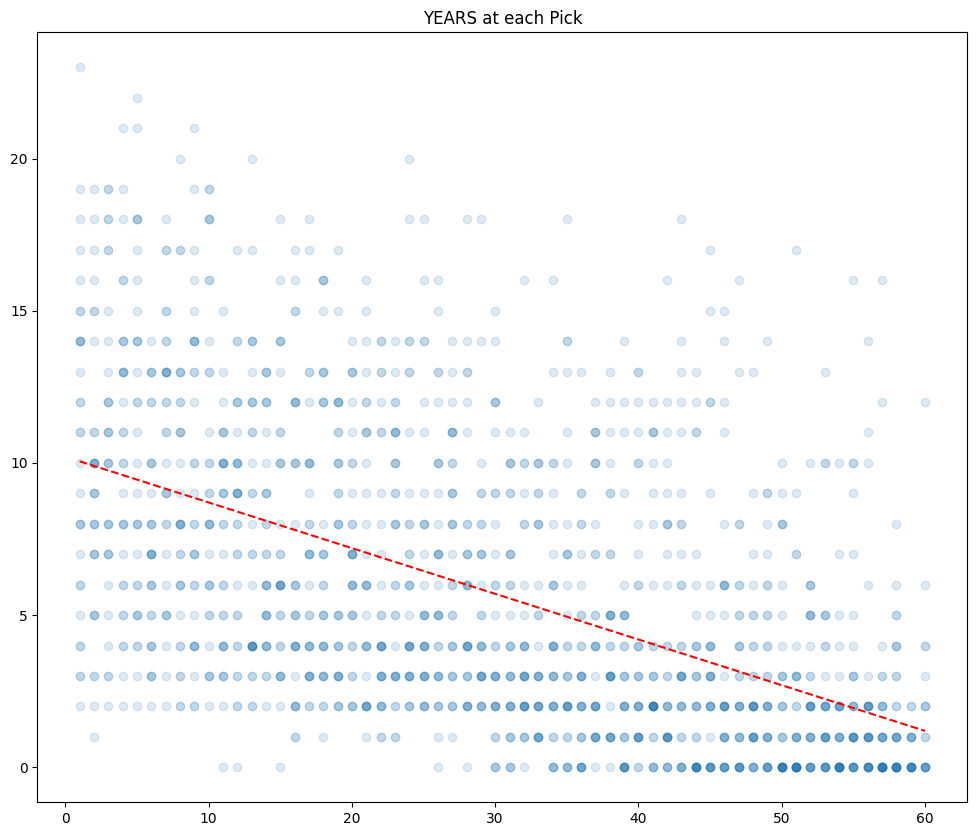

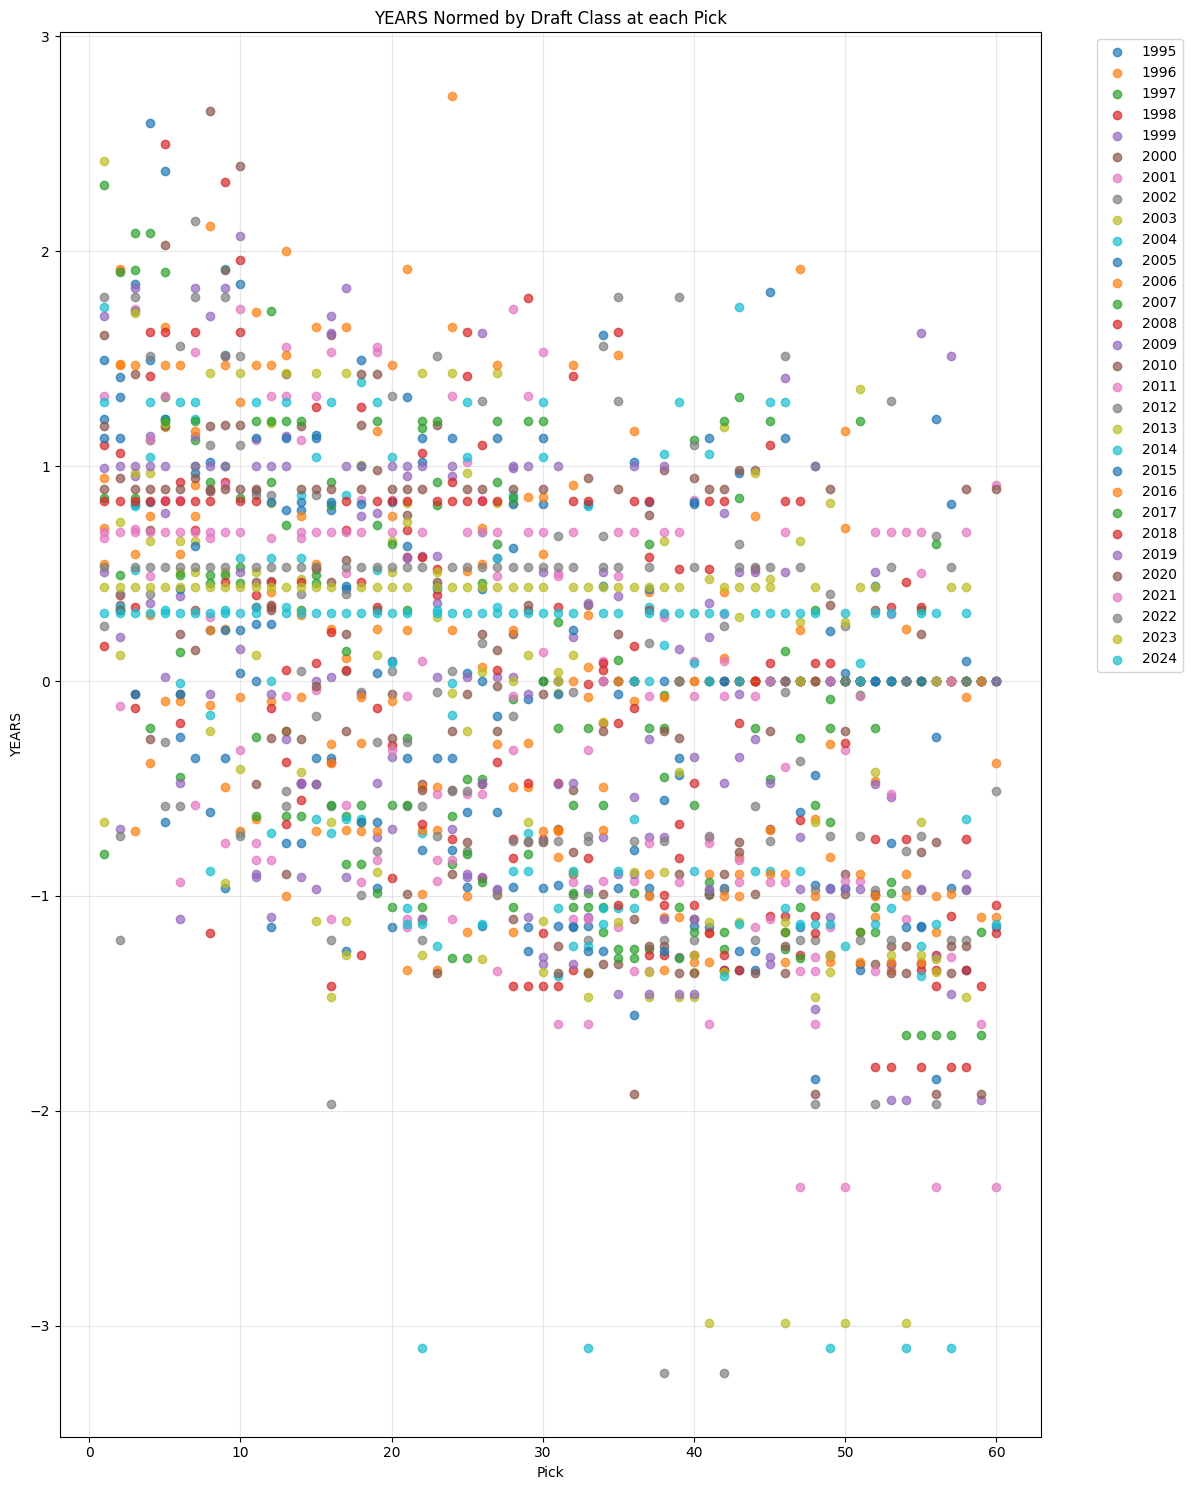

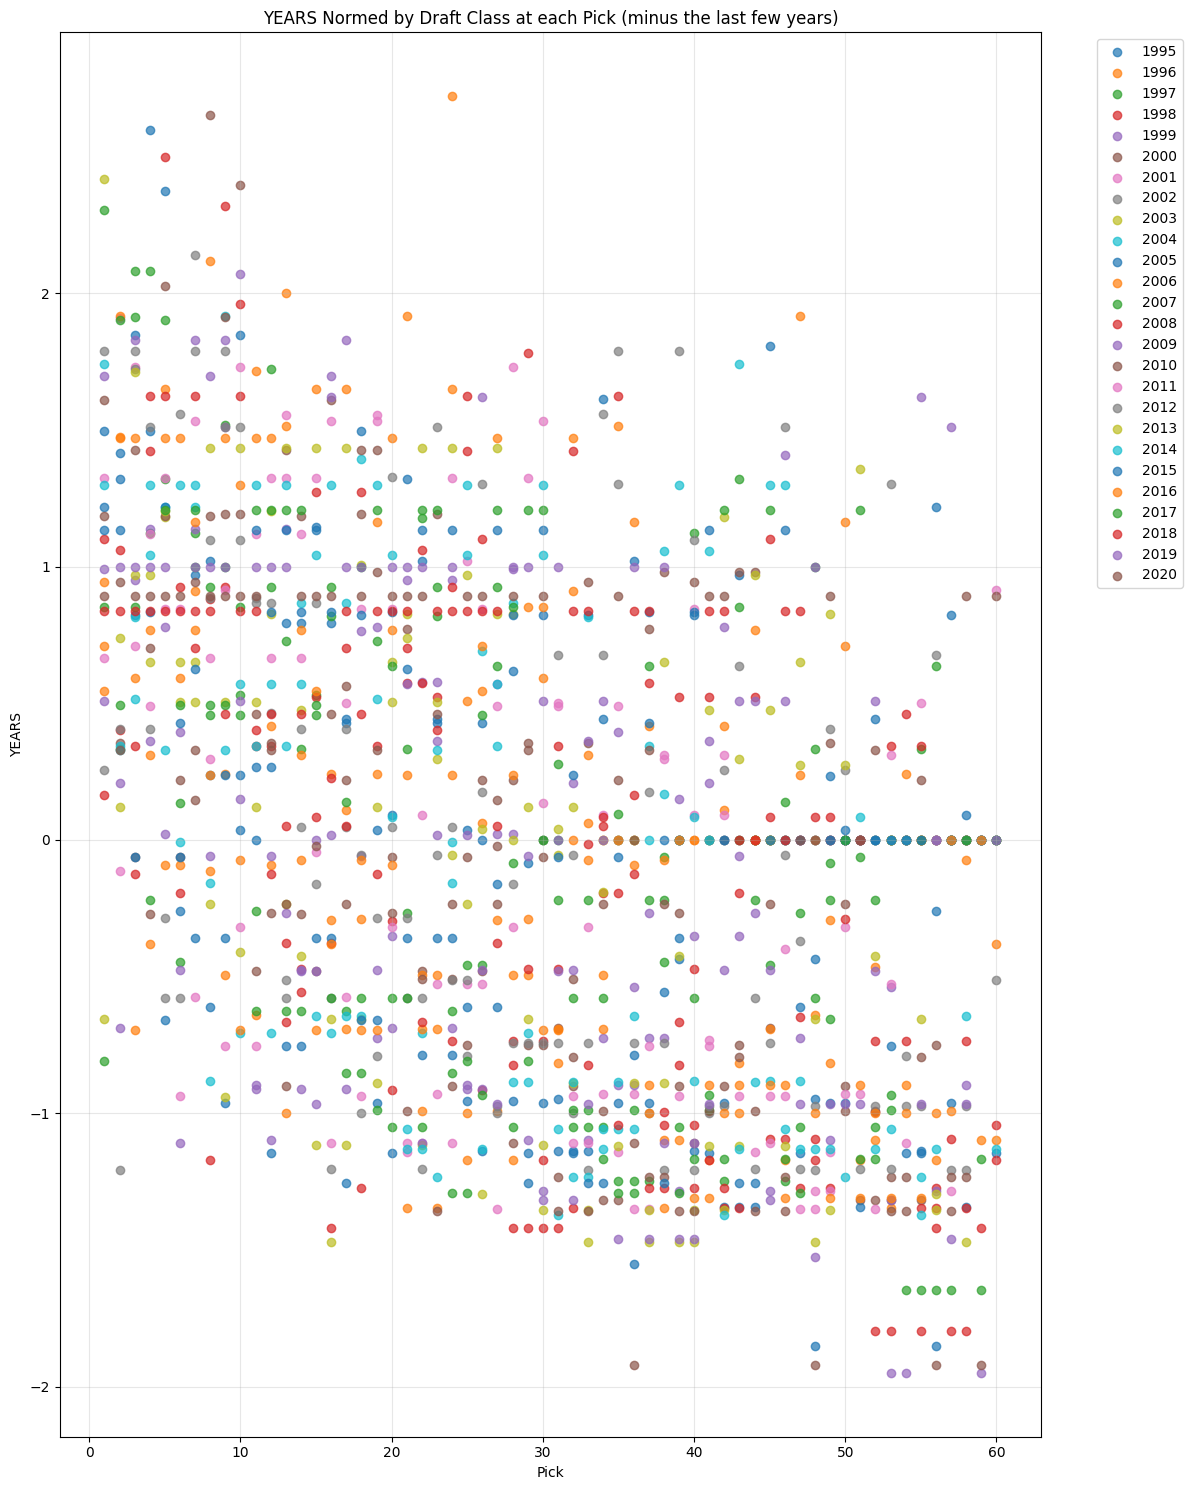

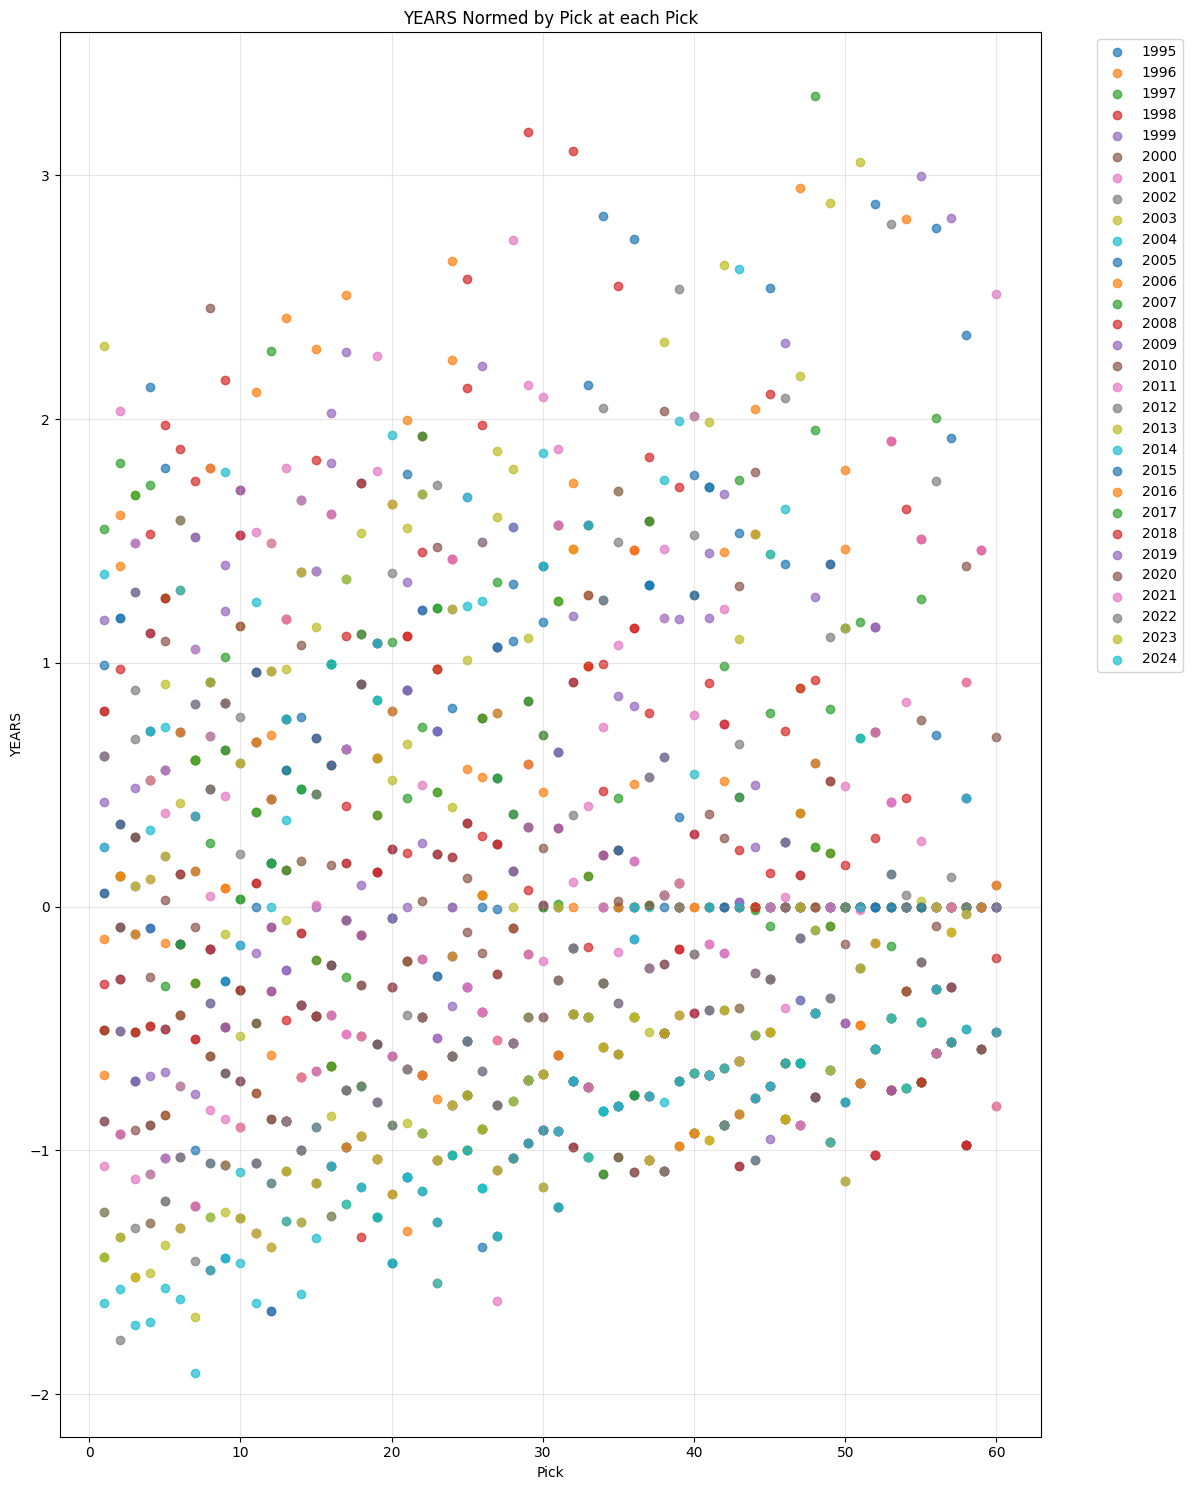

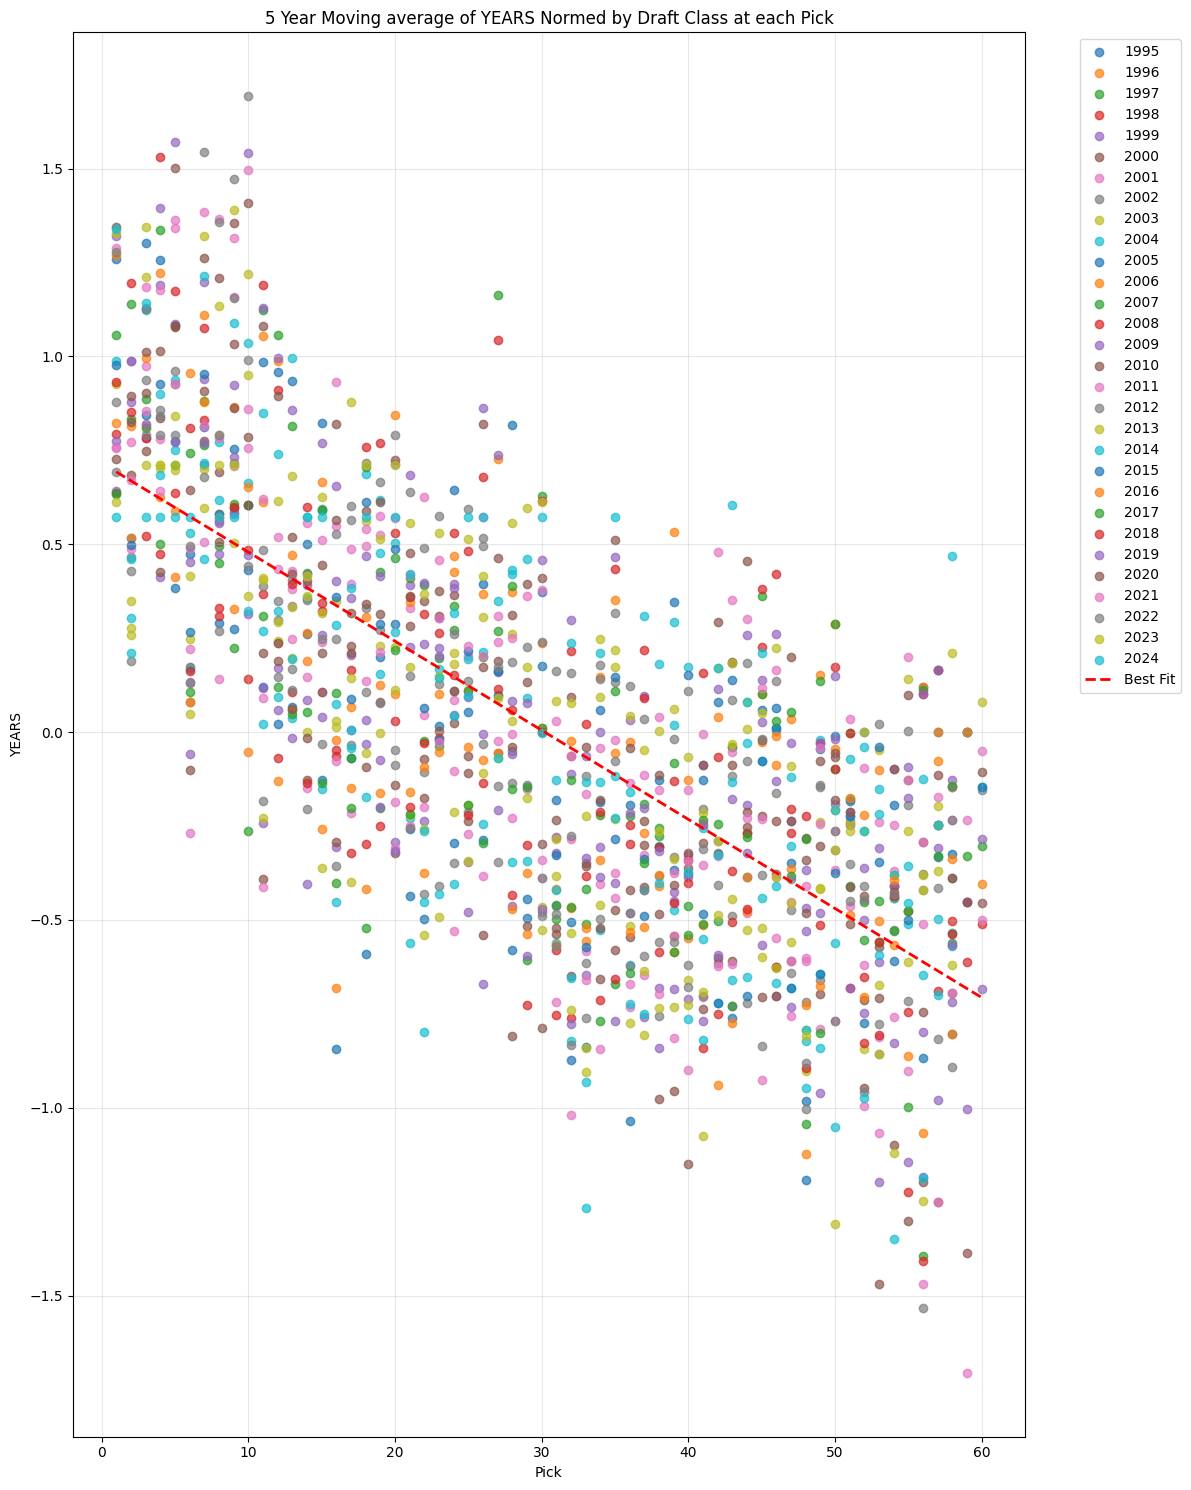

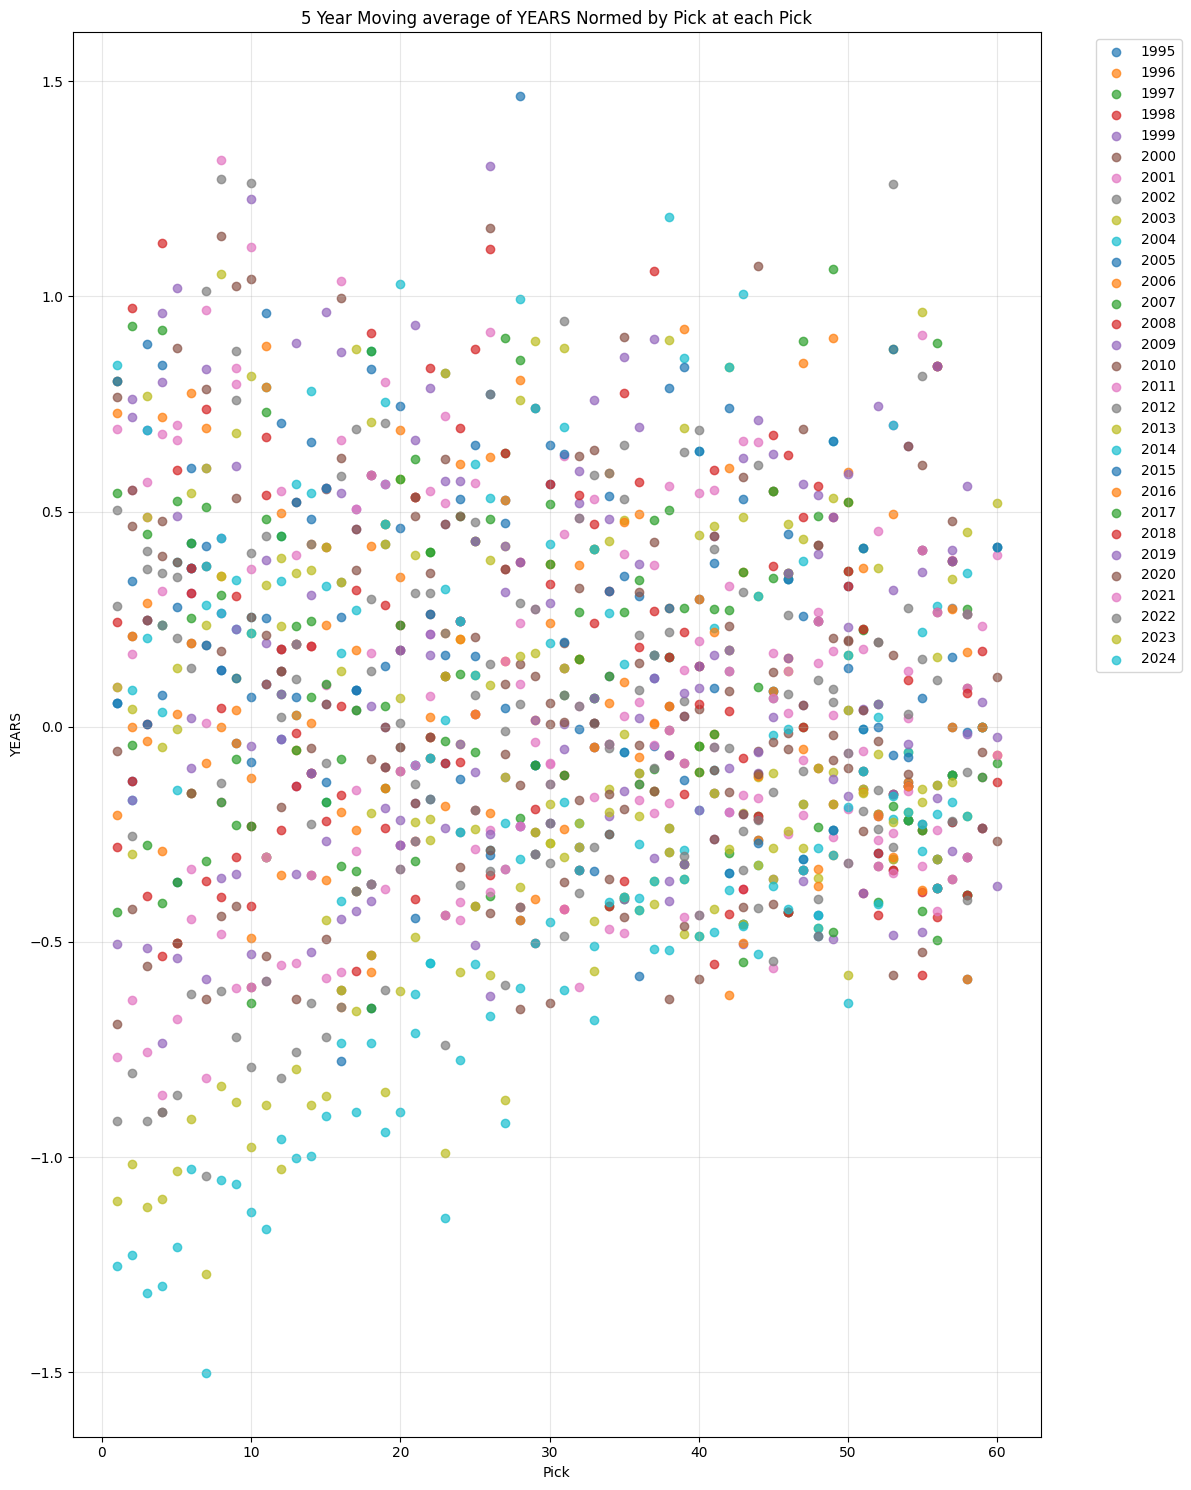

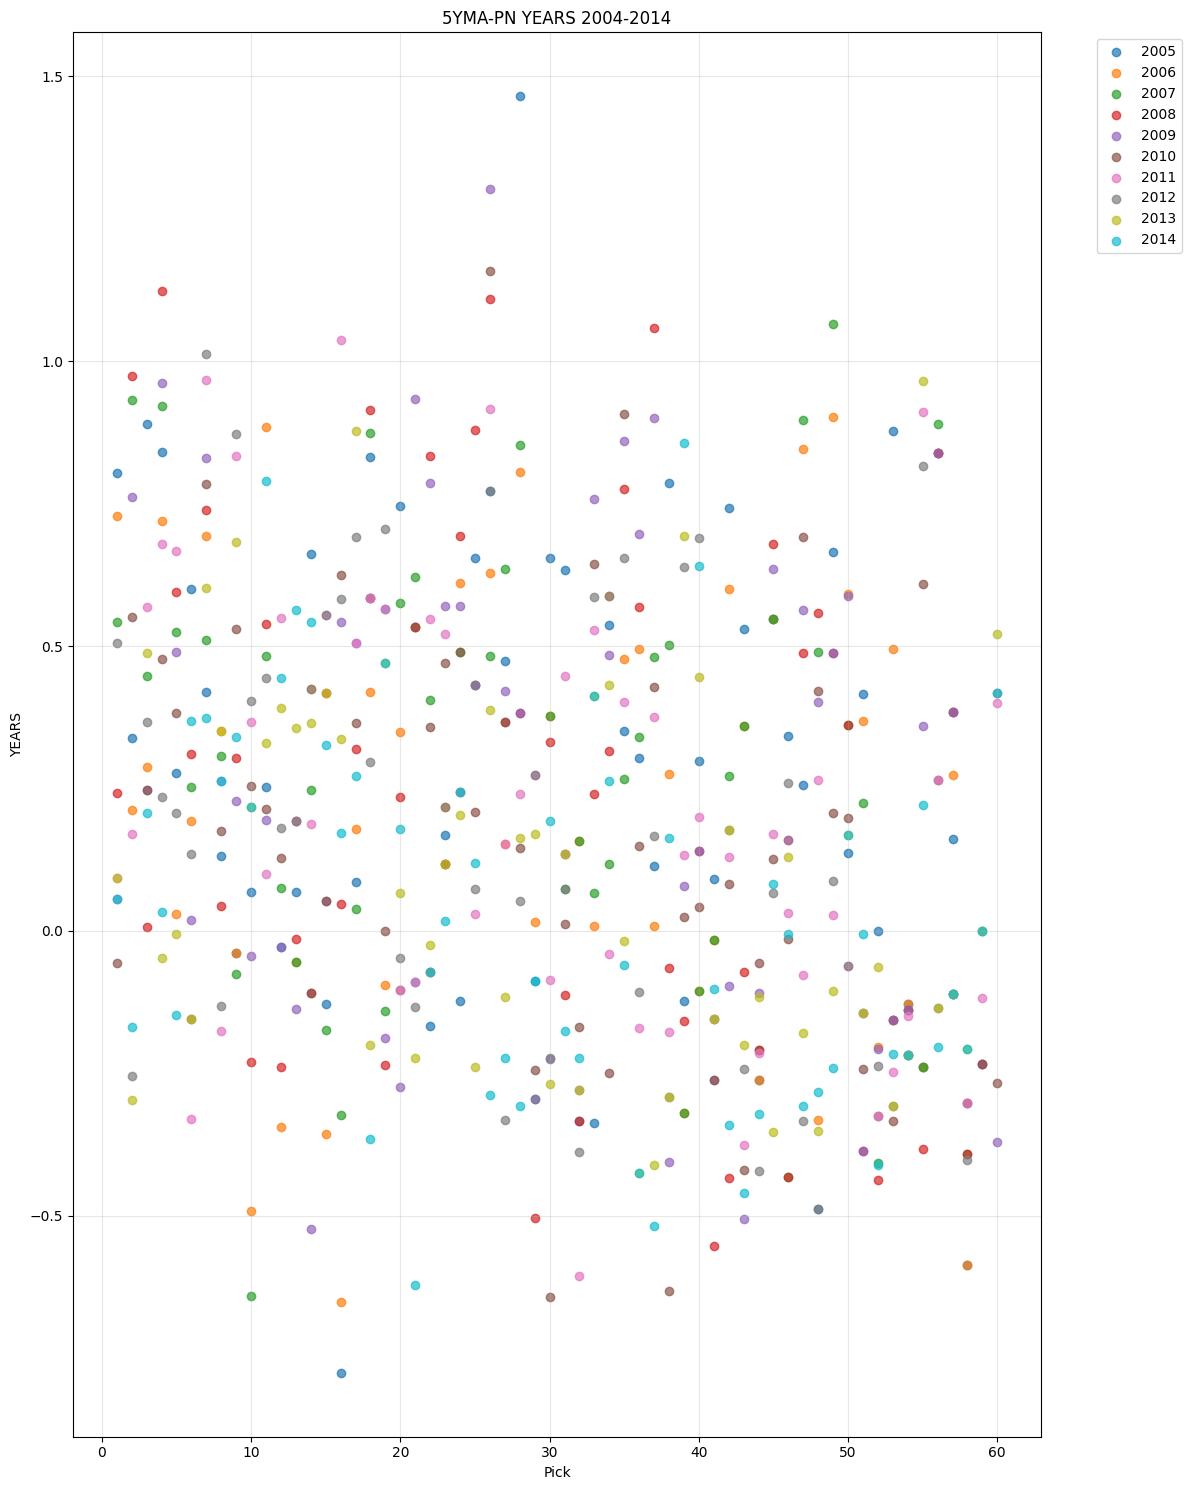

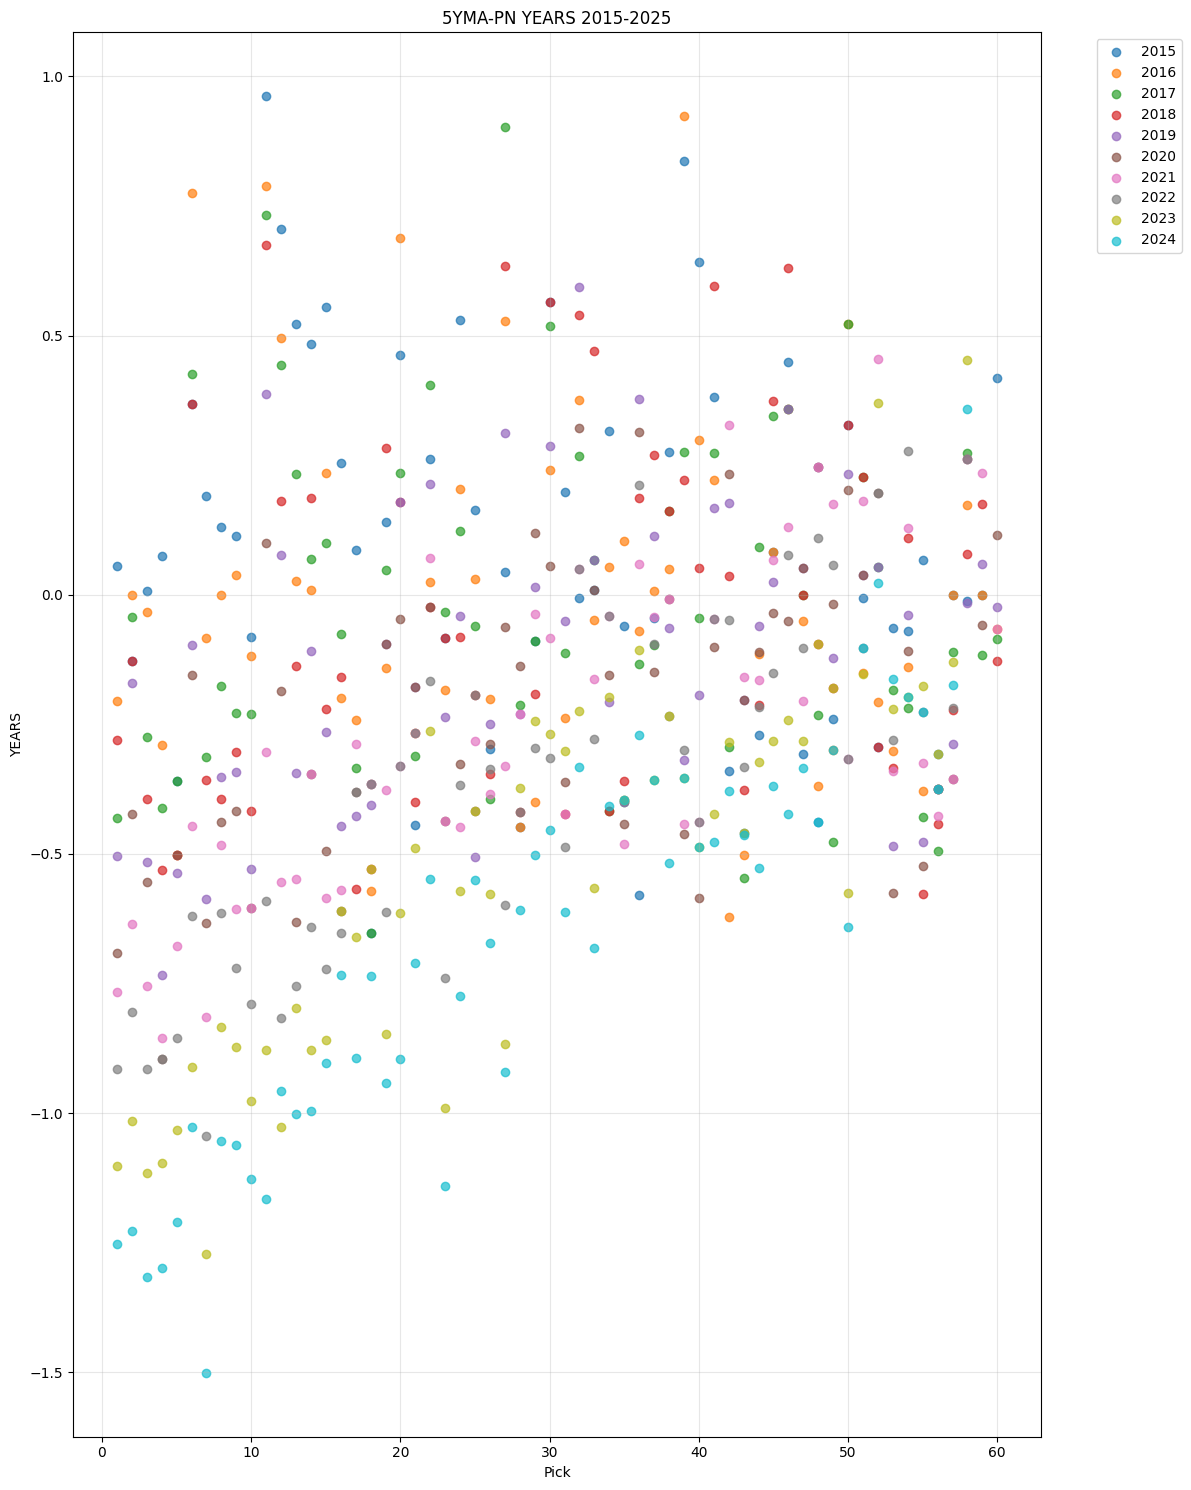

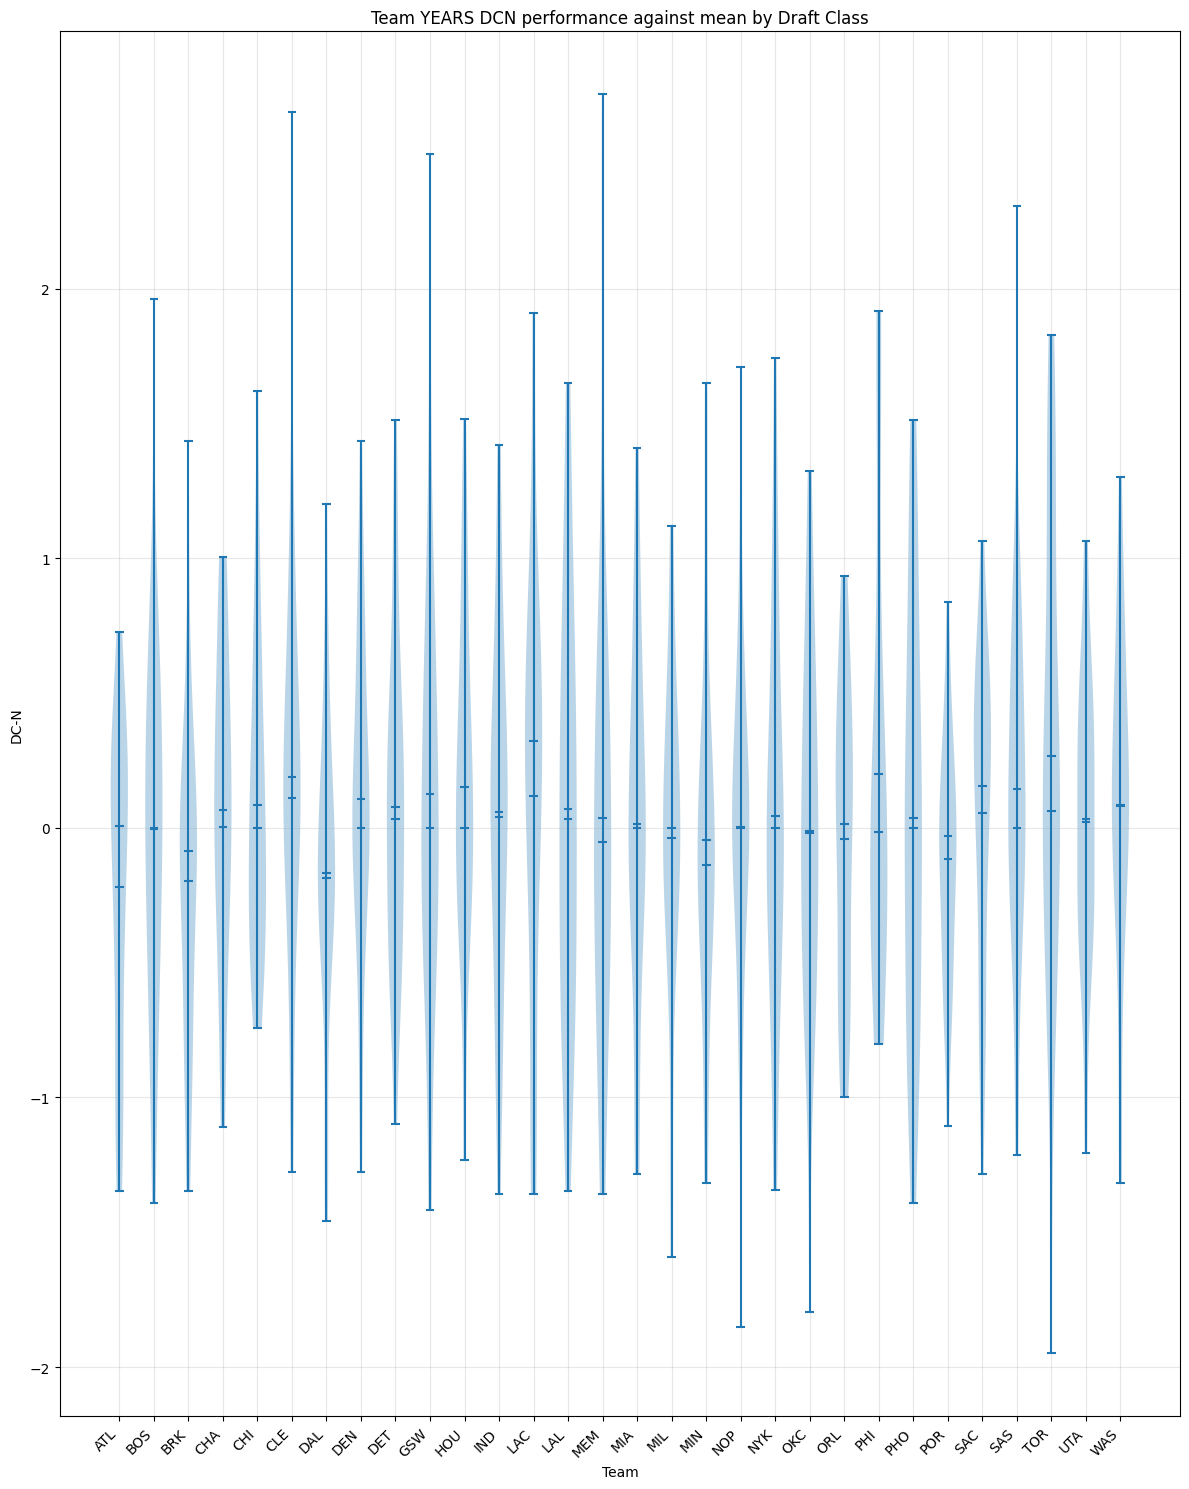

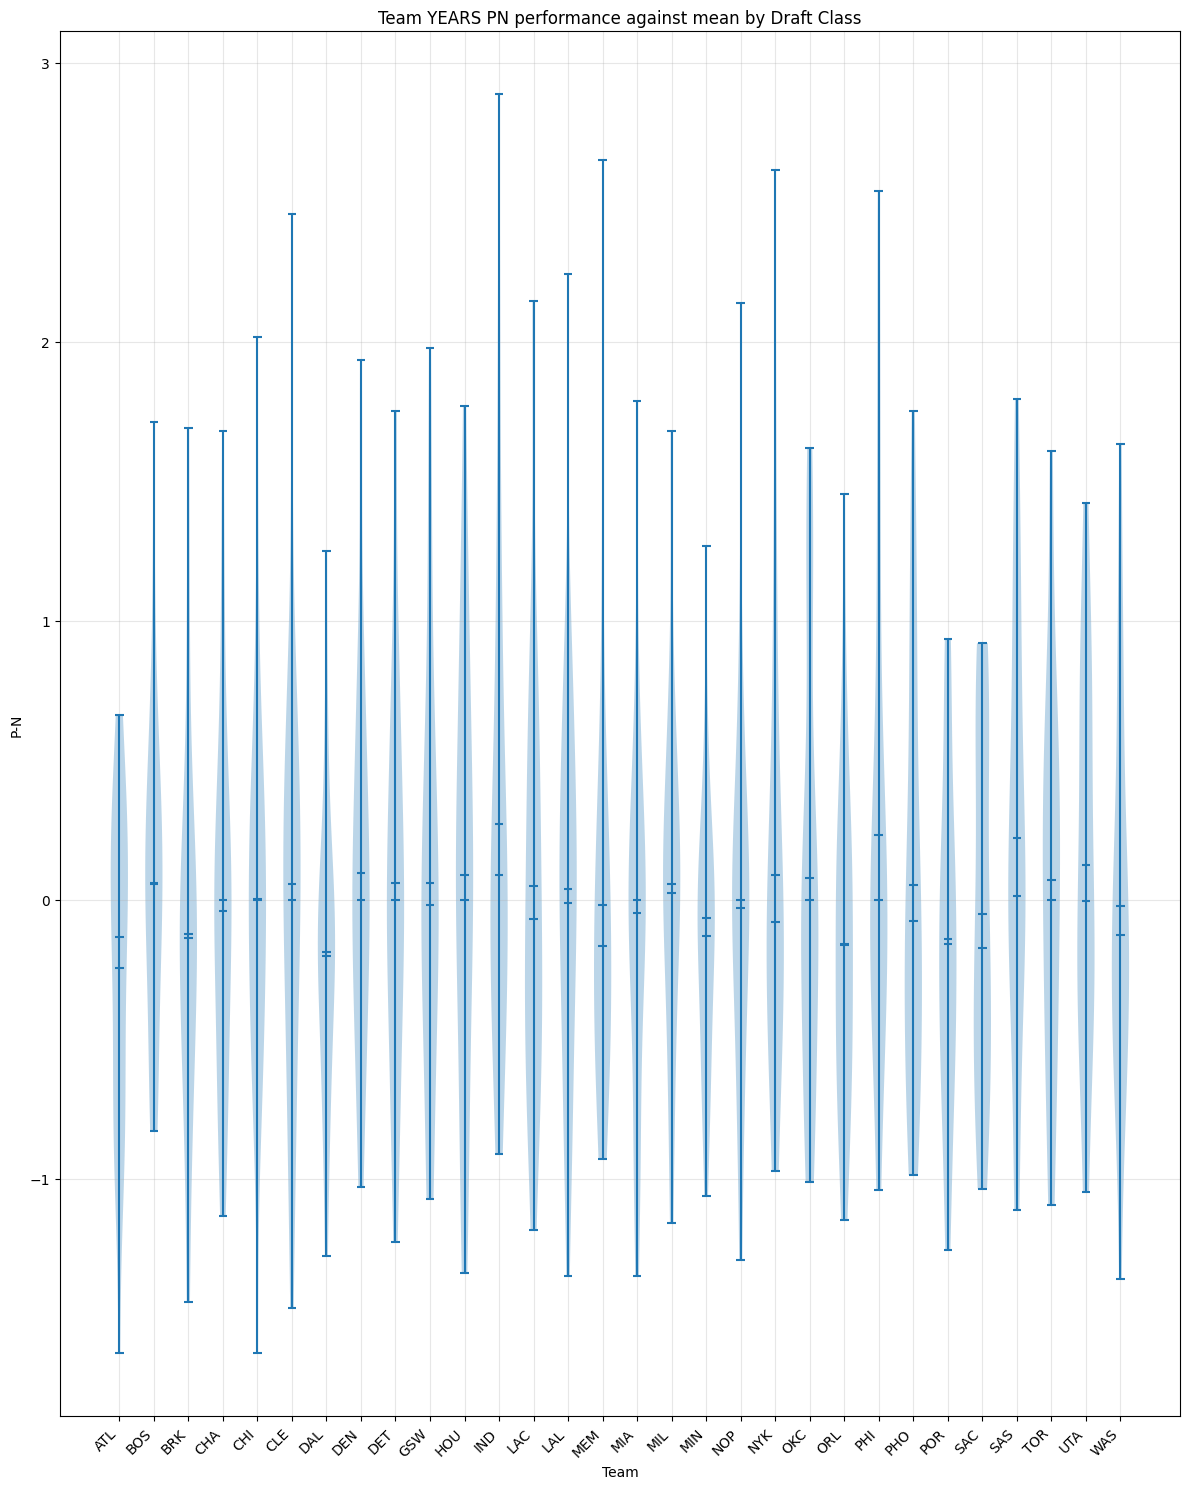

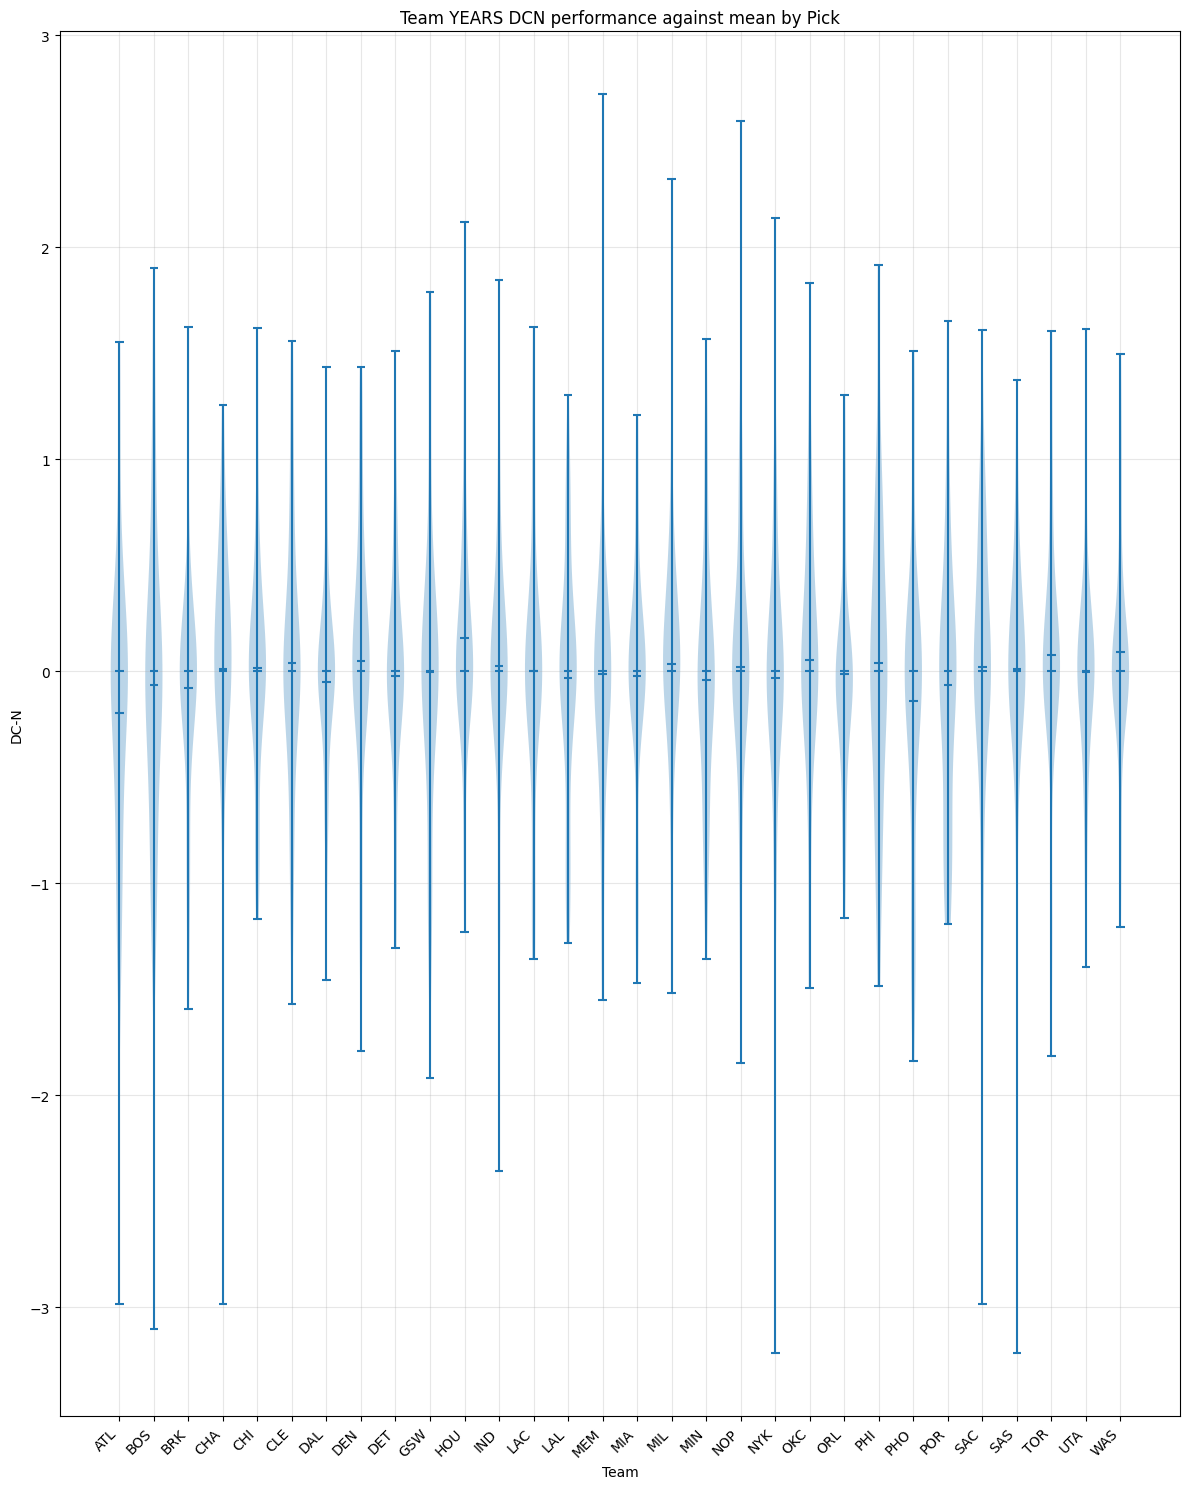

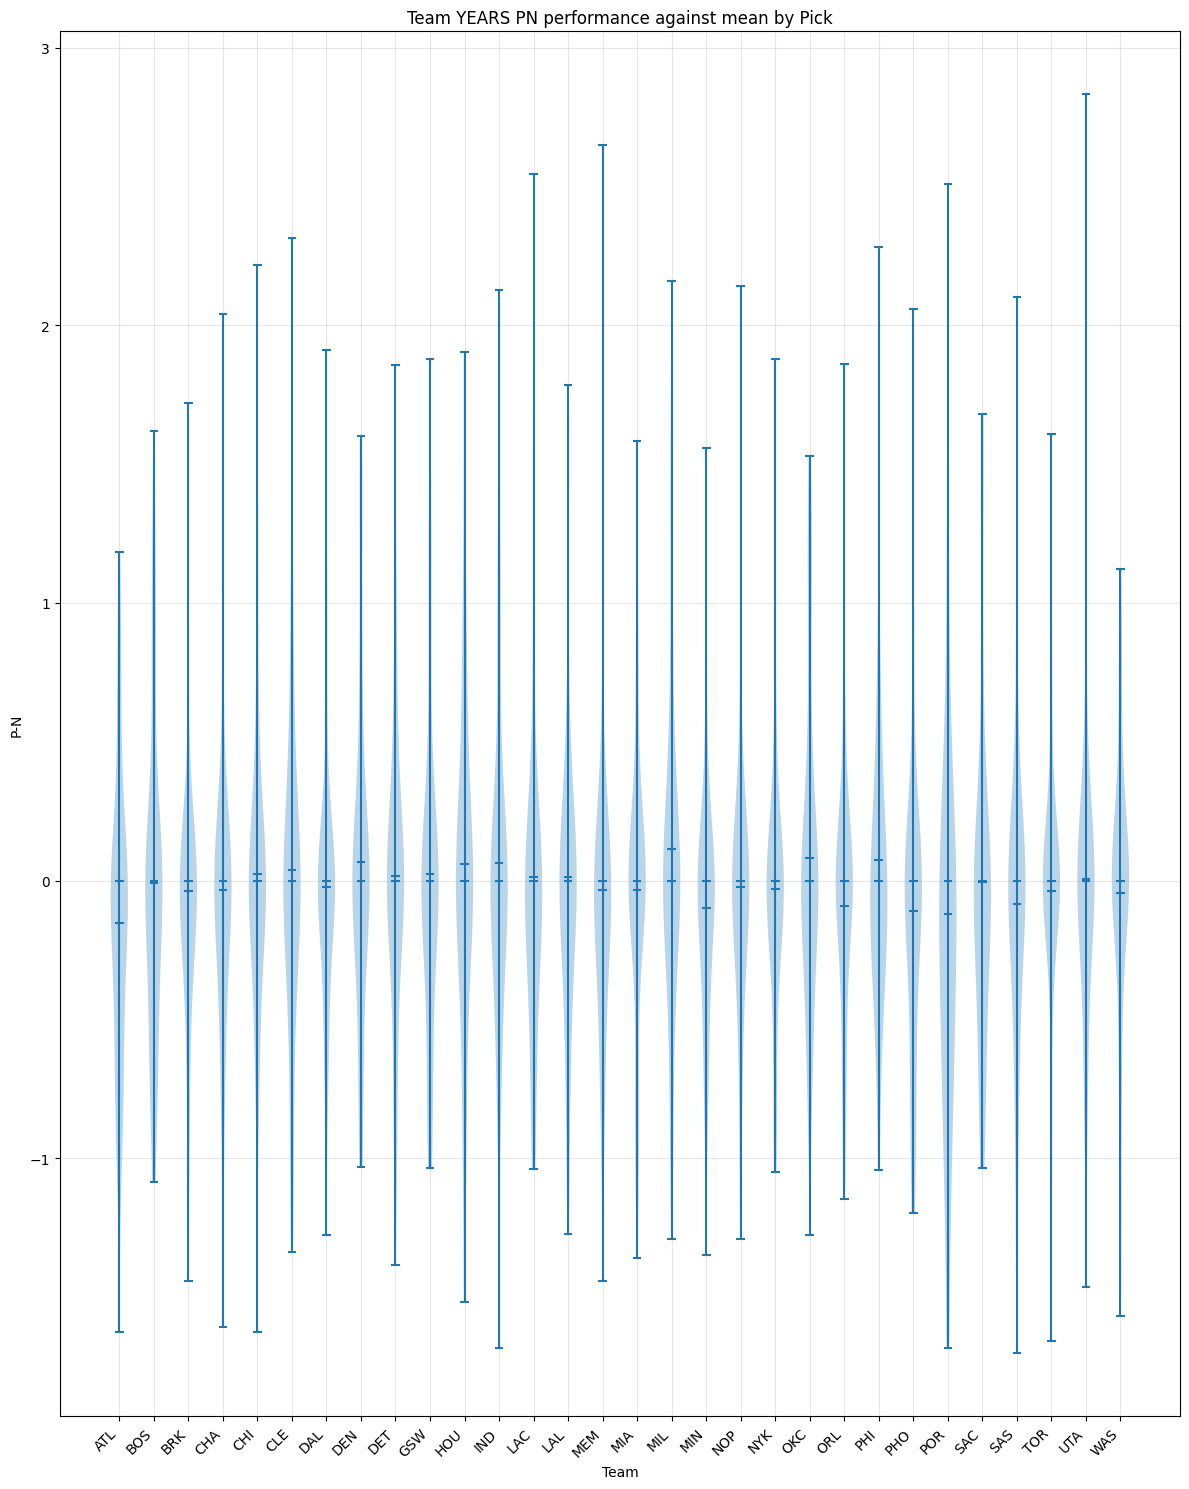

In [21]:
metric = 'YEARS'

plt.figure(figsize=(12,10))
plt.title('{} at each Pick'.format(metric))

x = df['PICK']
y = df[metric]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.scatter(x, y, alpha=0.15)
plt.plot(x, p(x), 'r--')
plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Draft Class at each Pick'.format(metric))

new_df = dc_normed_year[metric]

for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Draft Class at each Pick (minus the last few years)'.format(metric))

new_df = dc_normed_year[metric]

for col in new_df.columns:
    if int(col) < 2021:
        plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Pick at each Pick'.format(metric))

new_df = p_normed_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5 Year Moving average of {} Normed by Draft Class at each Pick'.format(metric))

new_df = dcma_year[metric]

all_x = []
all_y = []
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
    all_x.extend(new_df.index)
    all_y.extend(new_df[col])

all_x = np.array(all_x)
all_y = np.array(all_y)
mask = ~np.isnan(all_y)
all_x = all_x[mask]
all_y = all_y[mask]

coefficients = np.polyfit(all_x, all_y, 1)  # 1 = linear
poly = np.poly1d(coefficients)
x_line = np.linspace(all_x.min(), all_x.max(), 100)
plt.plot(x_line, poly(x_line), 'r--', linewidth=2, label='Best Fit')

plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5 Year Moving average of {} Normed by Pick at each Pick'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5YMA-PN {} 2004-2014'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    if int(col) > 2004 and int(col) < 2015:
        plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5YMA-PN {} 2015-2025'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    if int(col) > 2014:
        plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} DCN performance against mean by Draft Class'.format(metric))


new_df = team_aggs['dcn_{}_dc'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('DC-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} PN performance against mean by Draft Class'.format(metric))

new_df = team_aggs['pn_{}_dc'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('P-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} DCN performance against mean by Pick'.format(metric))

new_df = team_aggs['dcn_{}_p'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('DC-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} PN performance against mean by Pick'.format(metric))

new_df = team_aggs['pn_{}_p'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('P-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

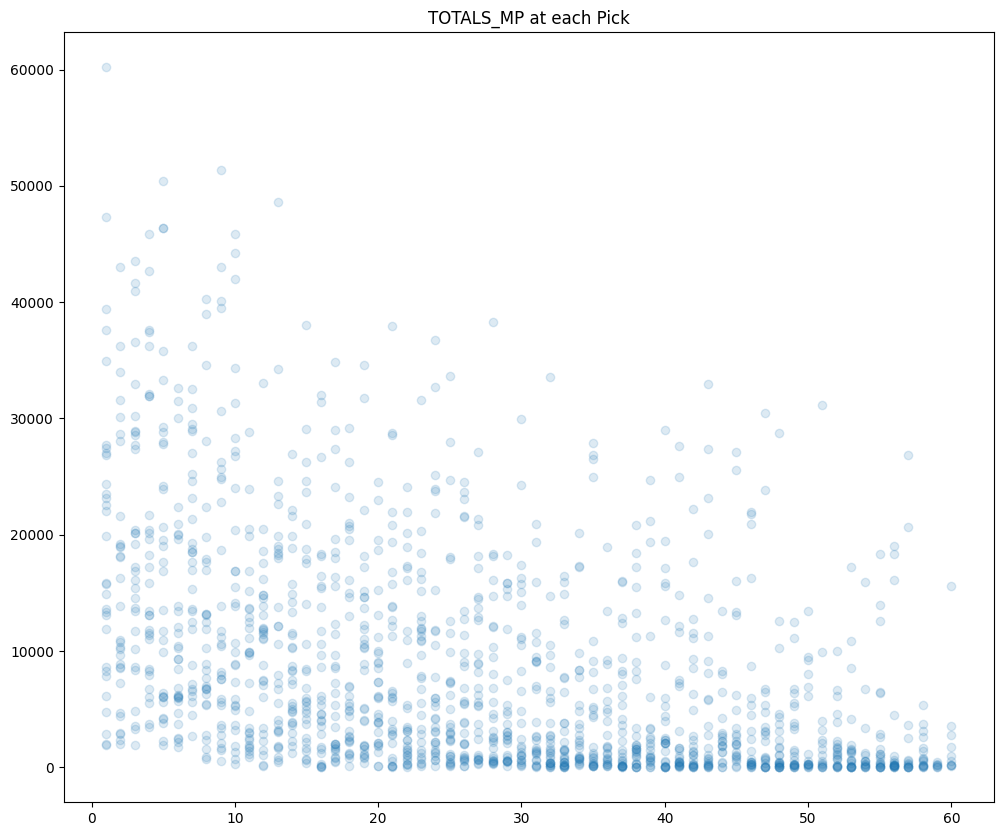

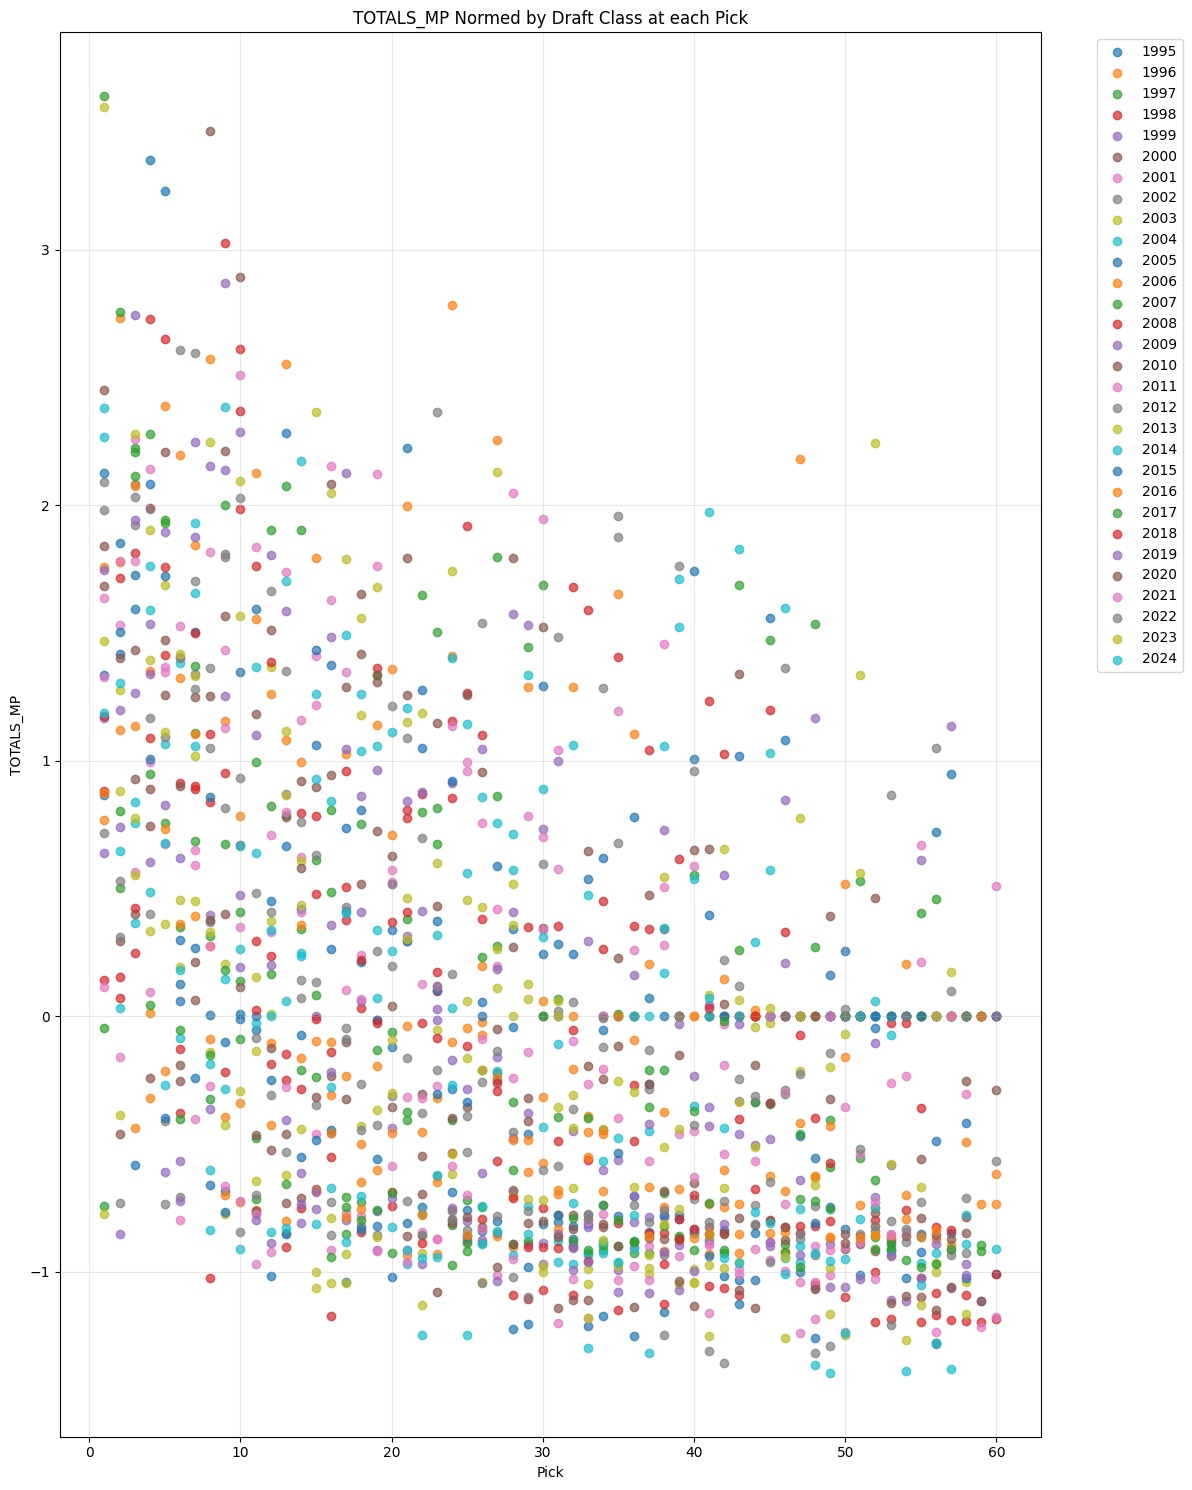

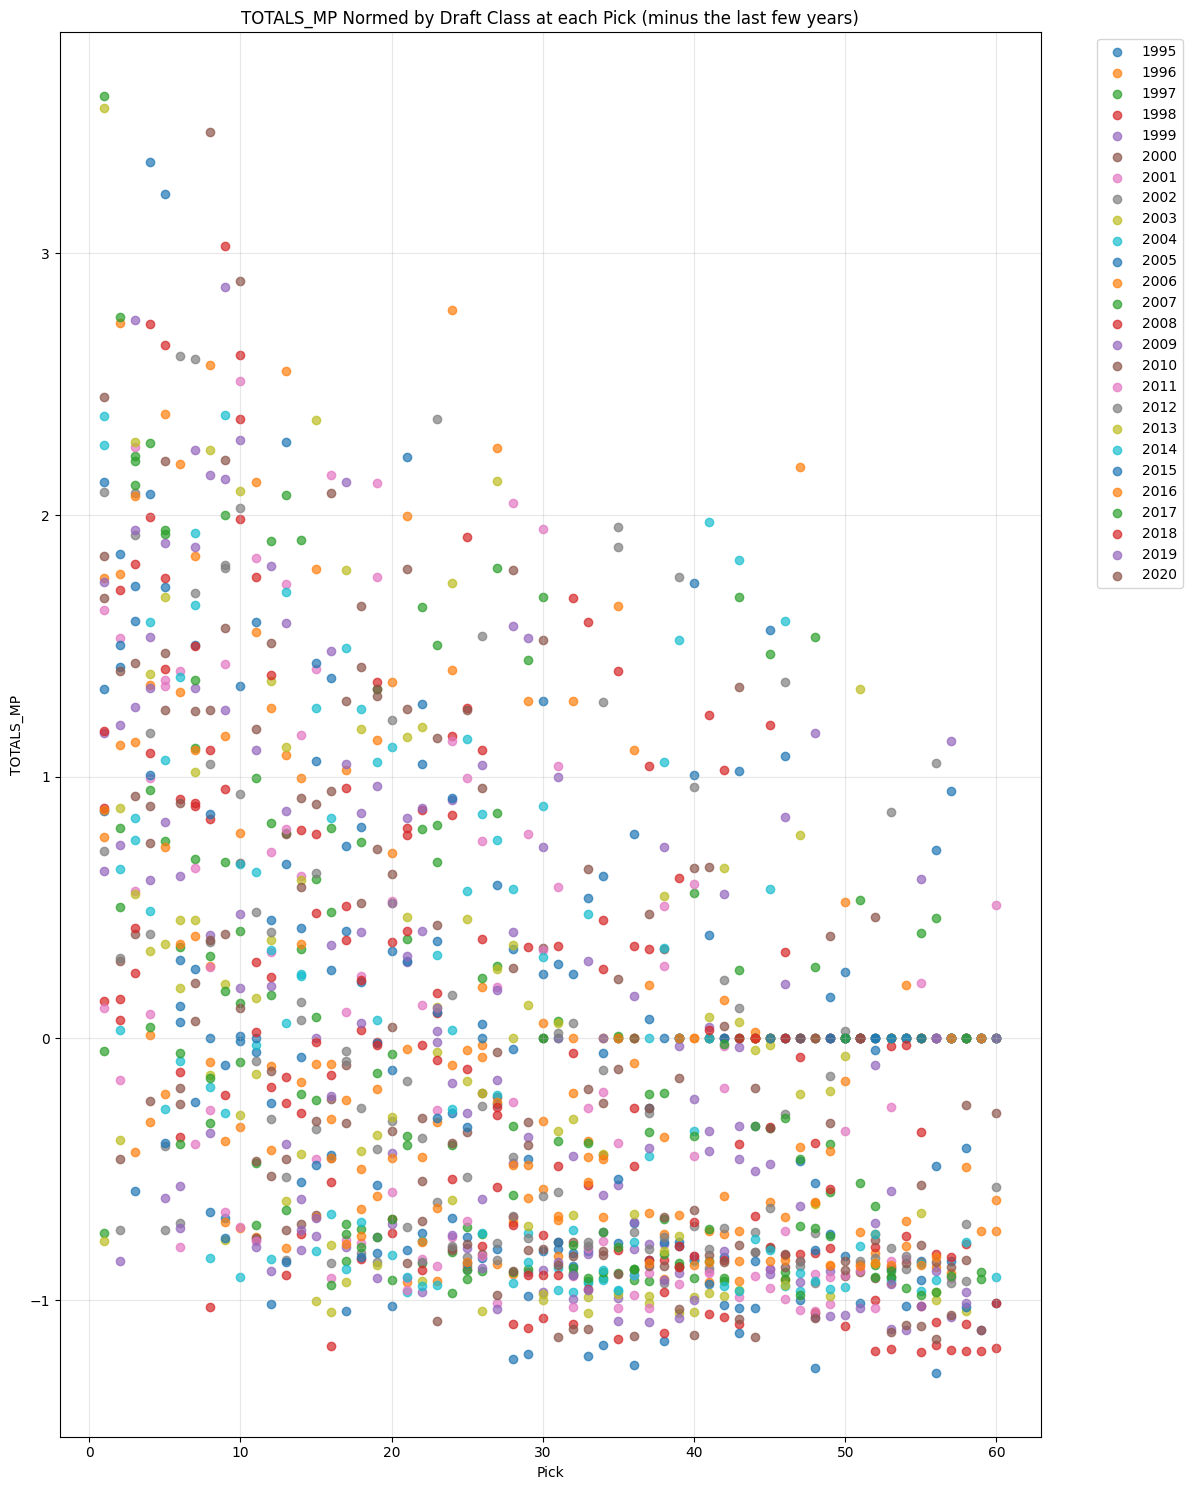

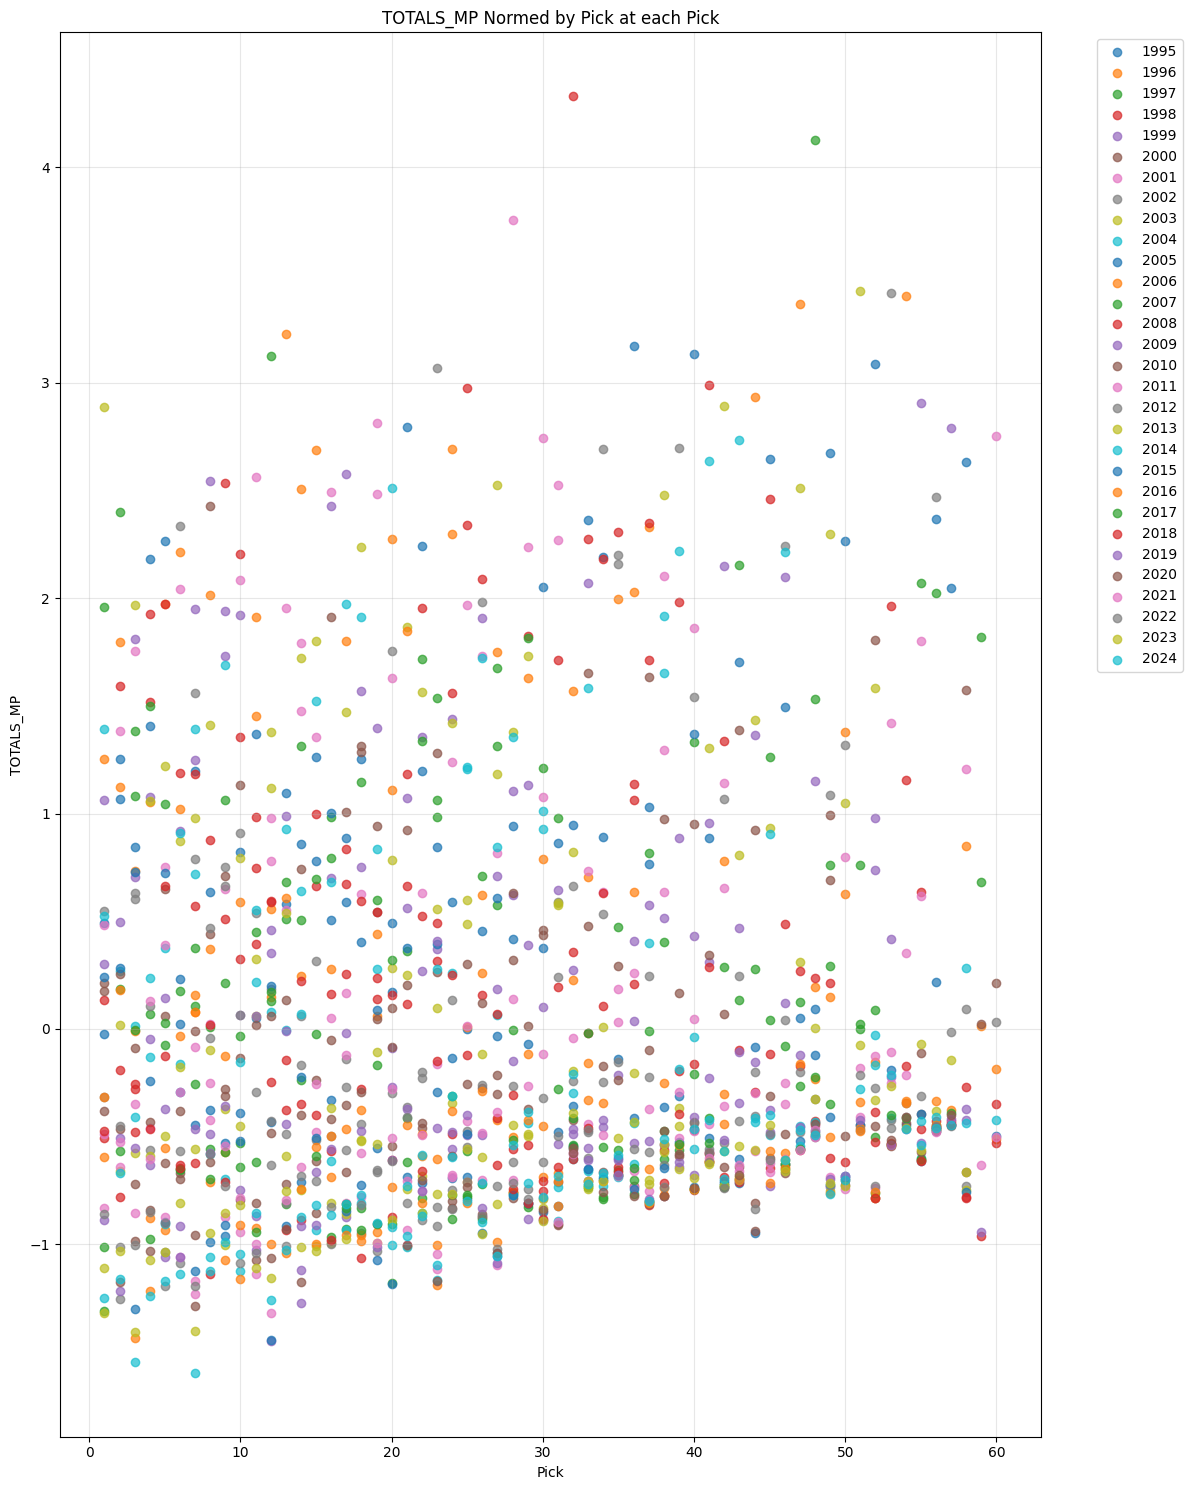

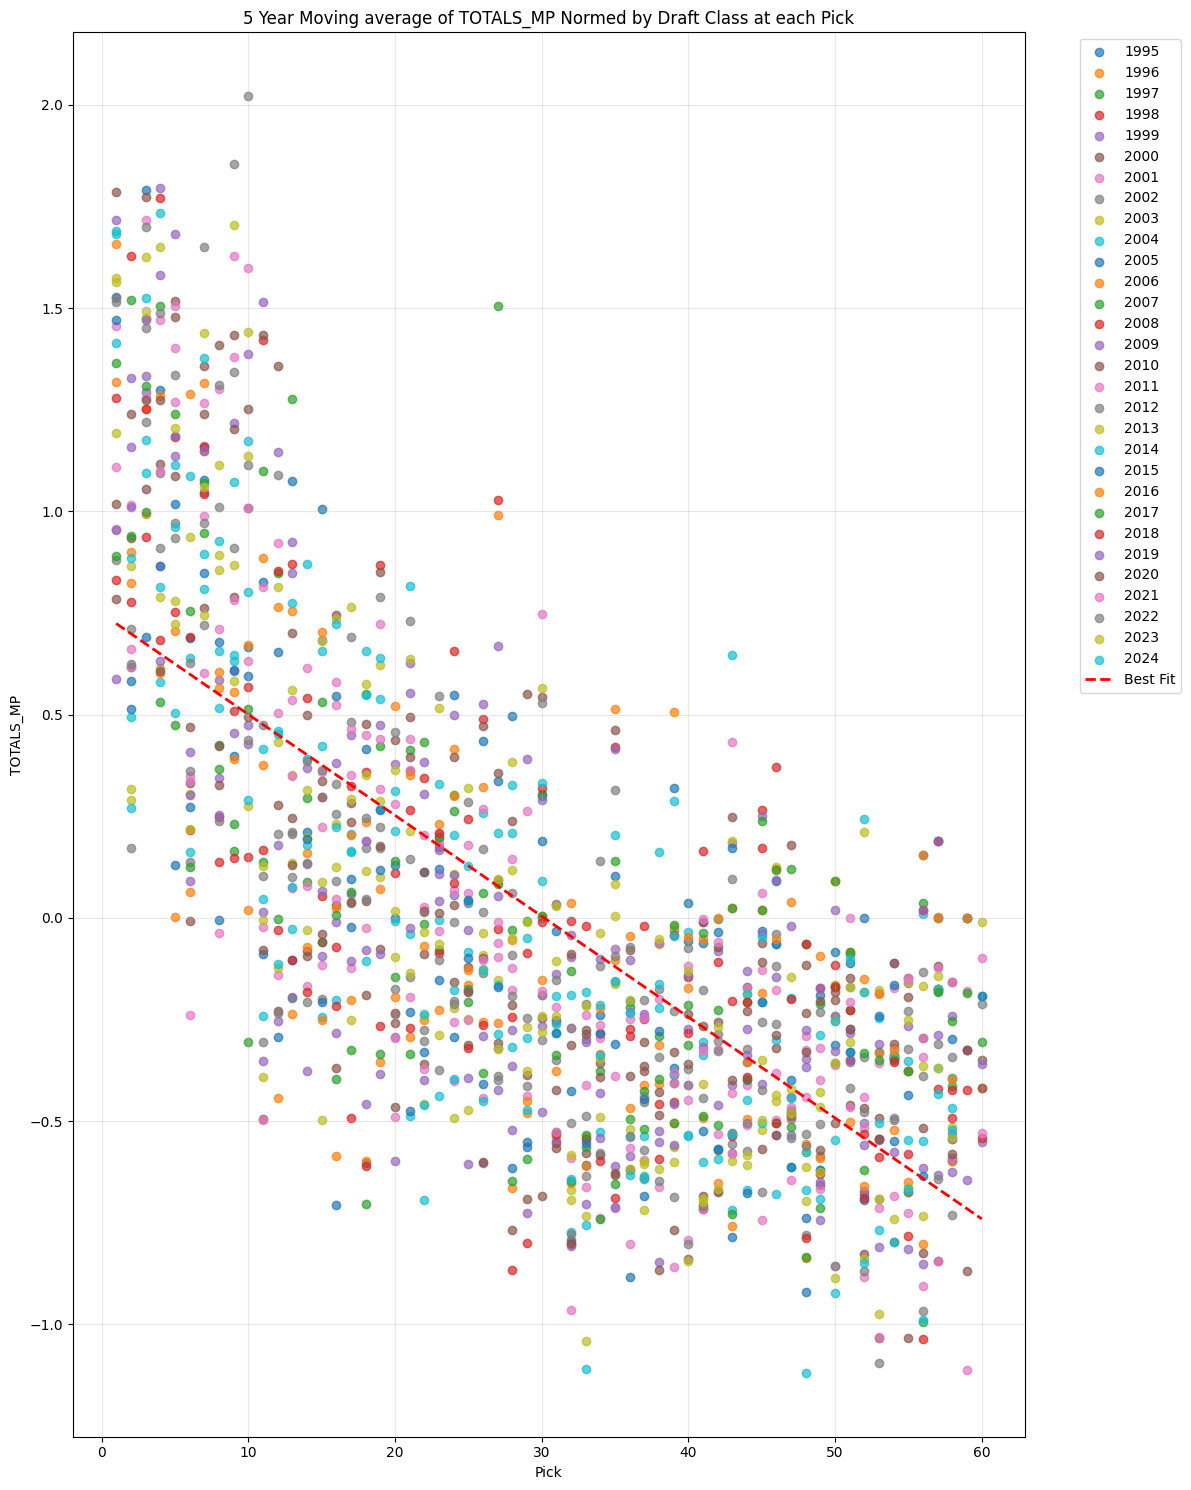

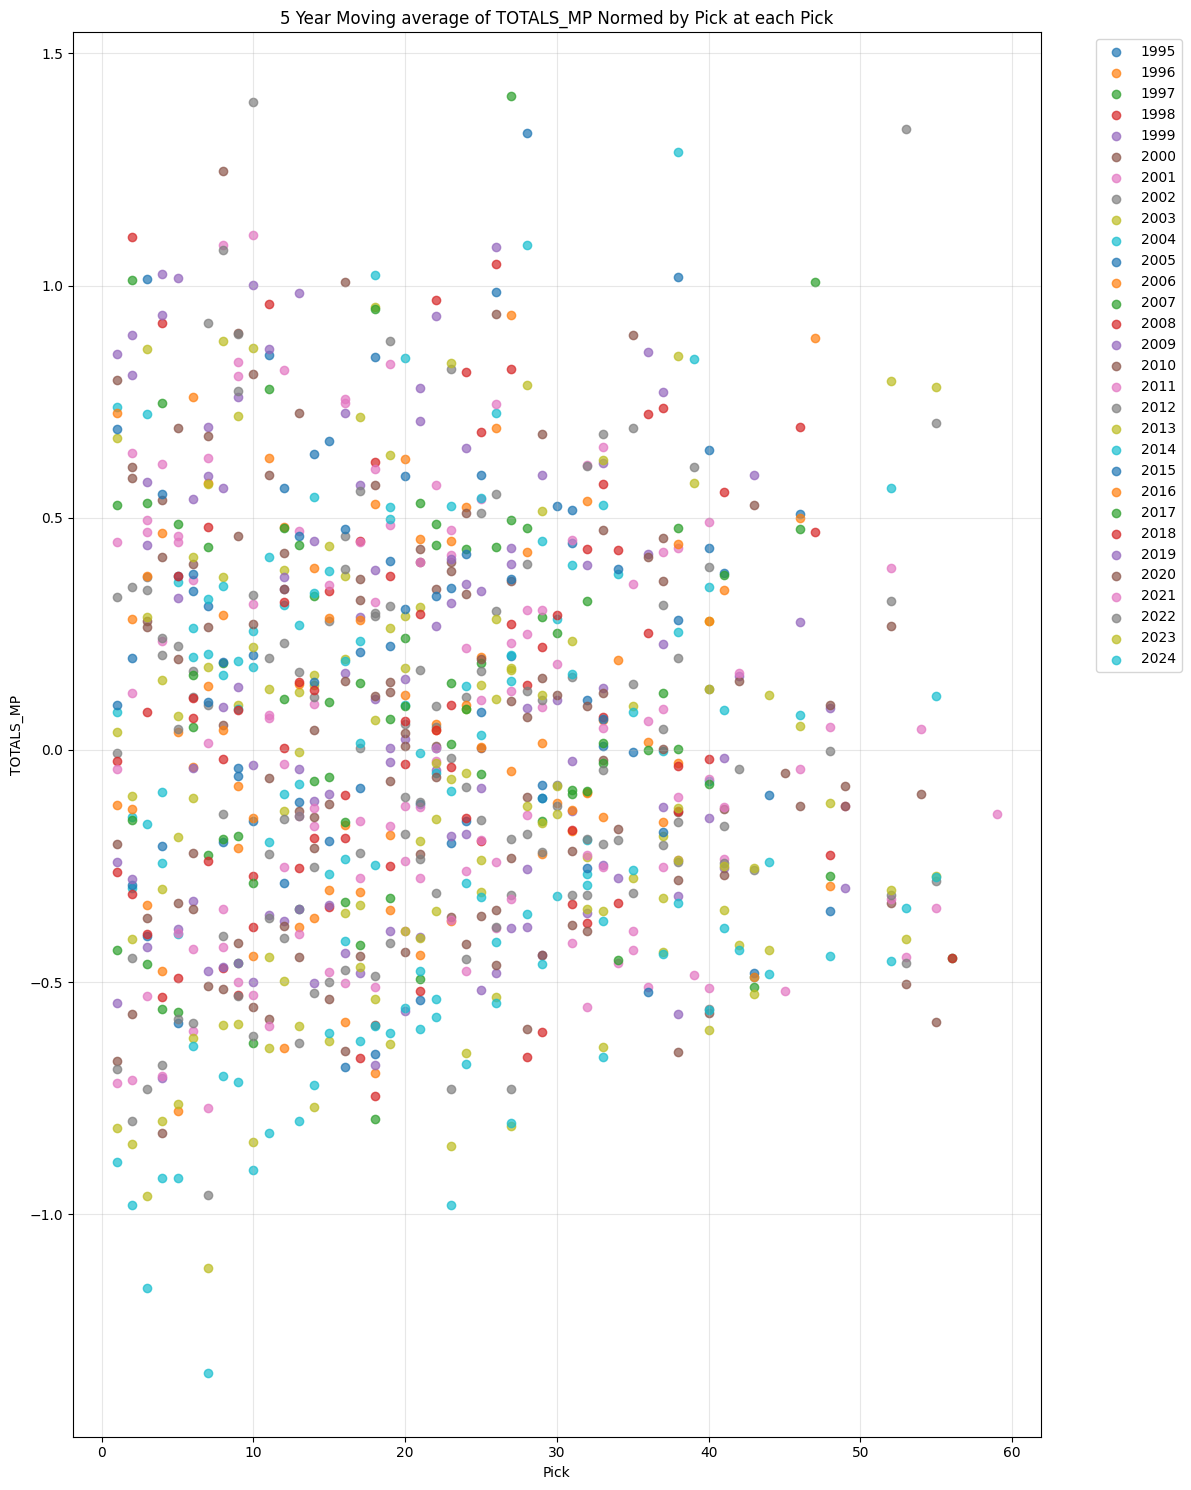

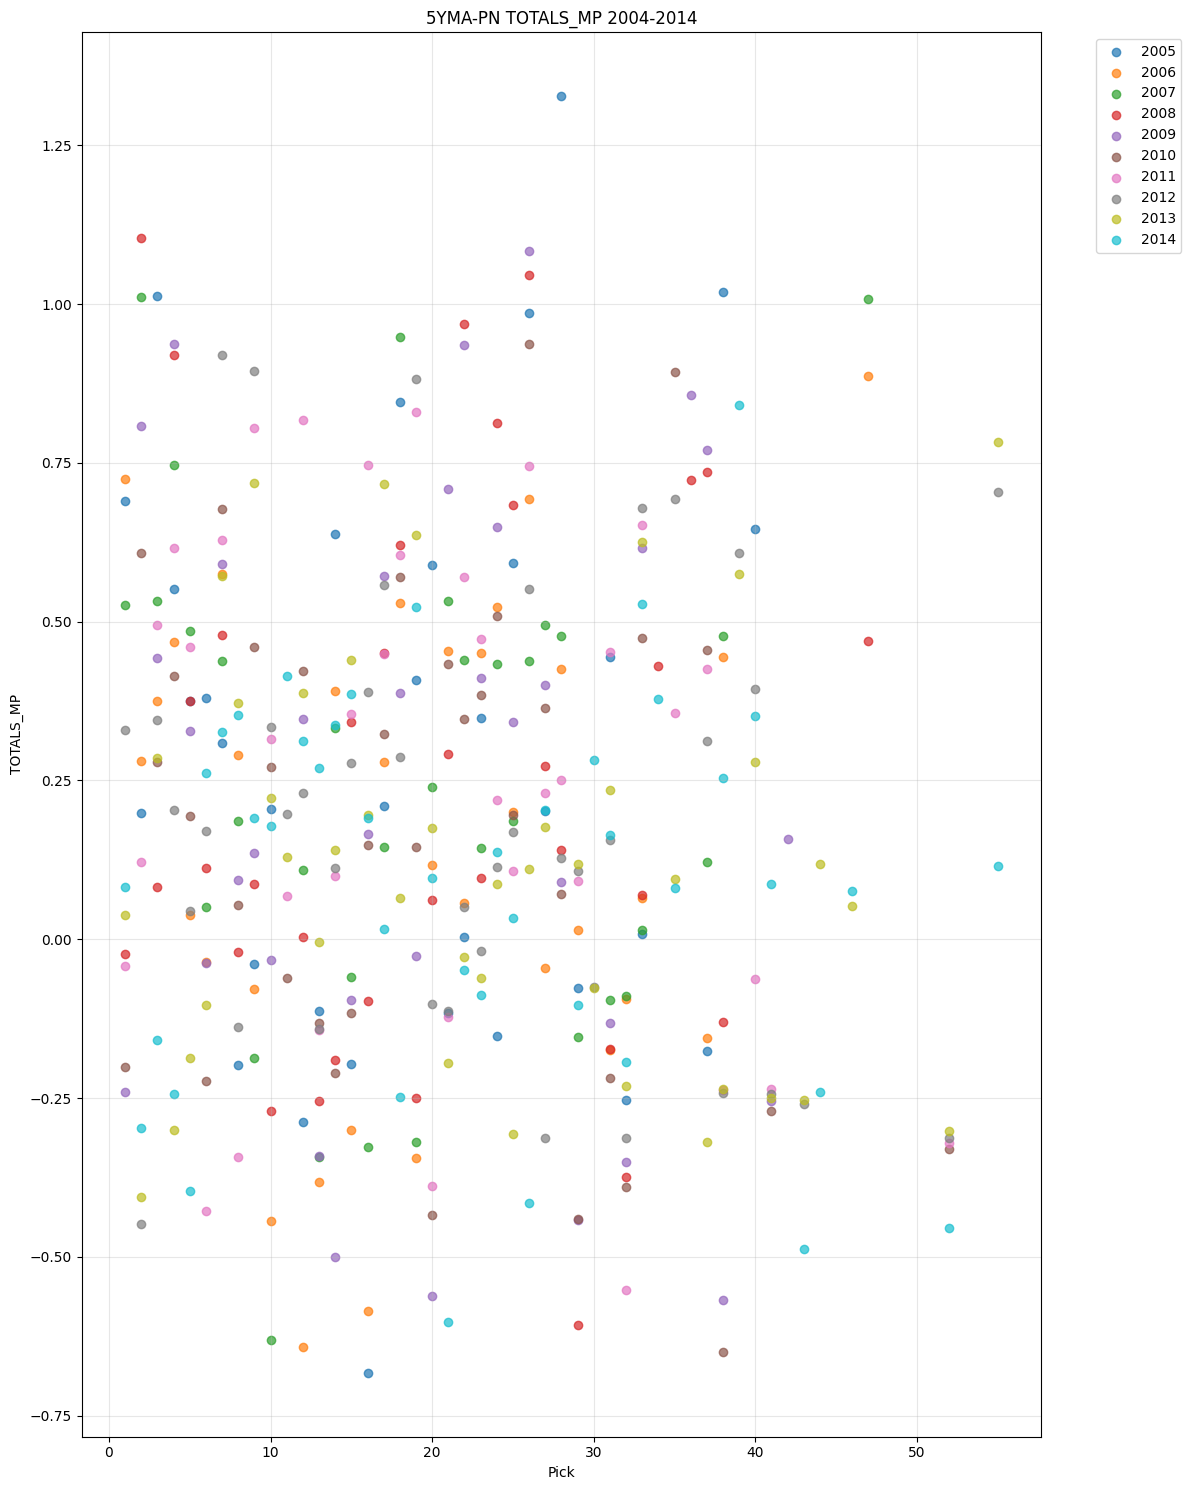

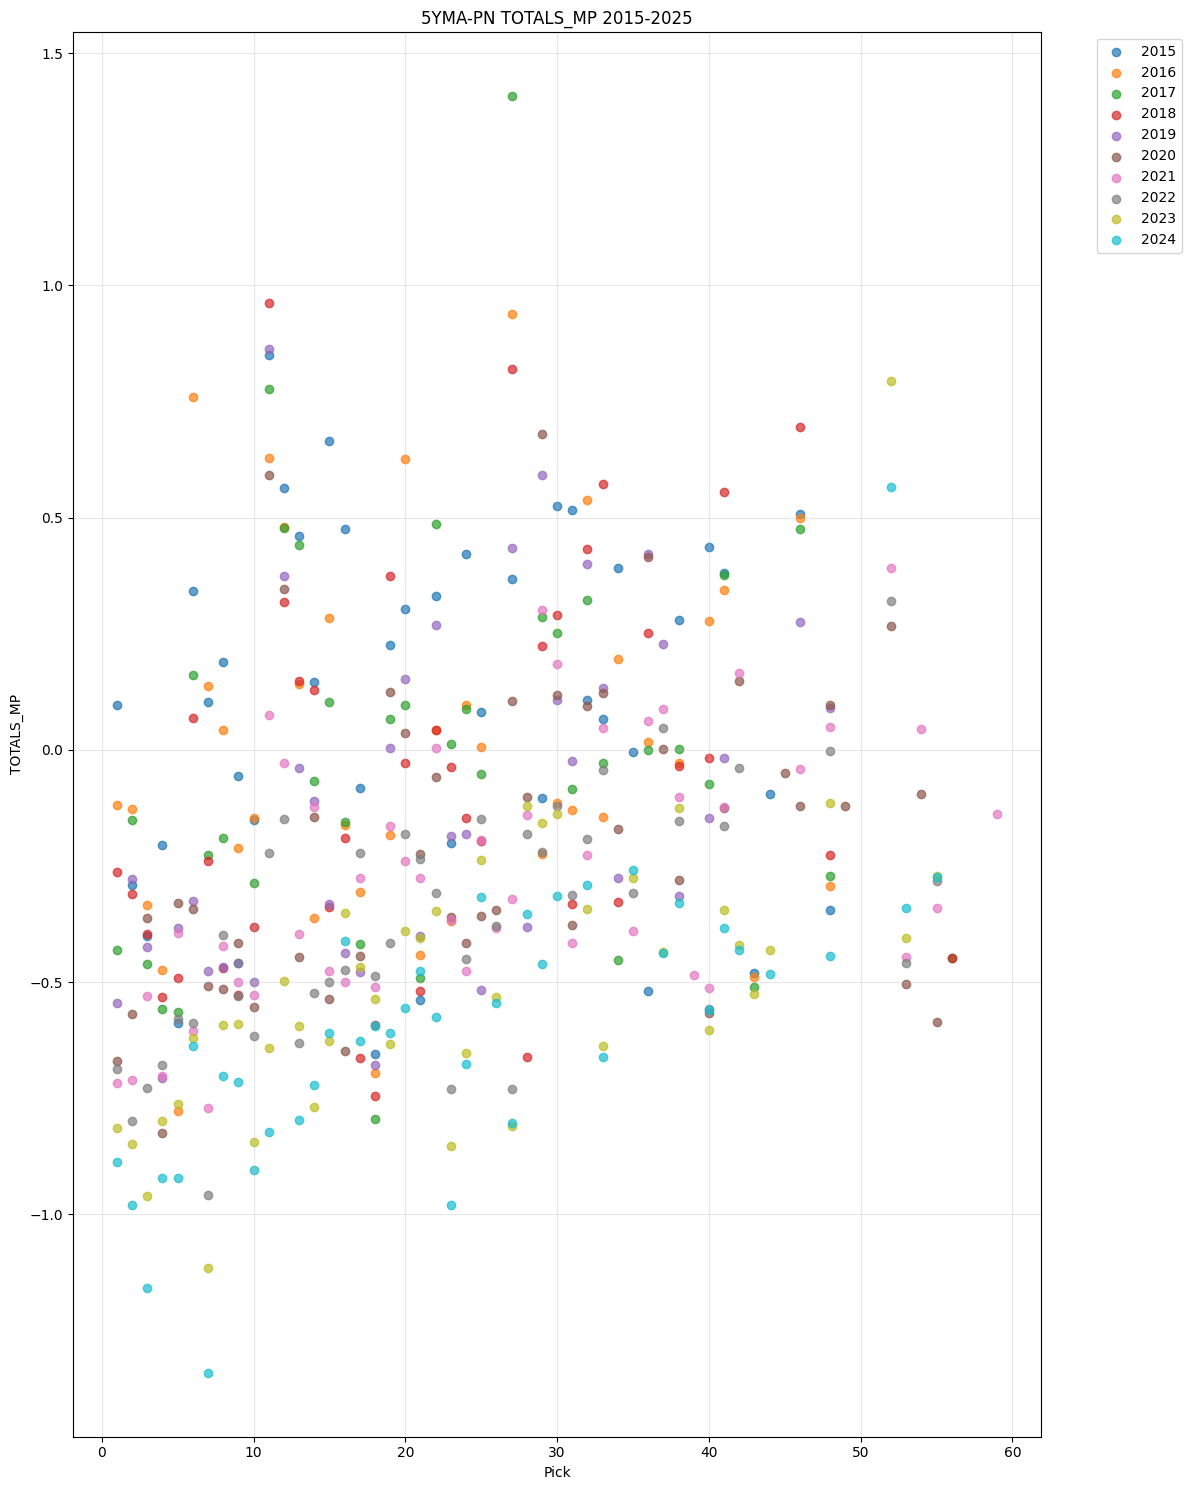

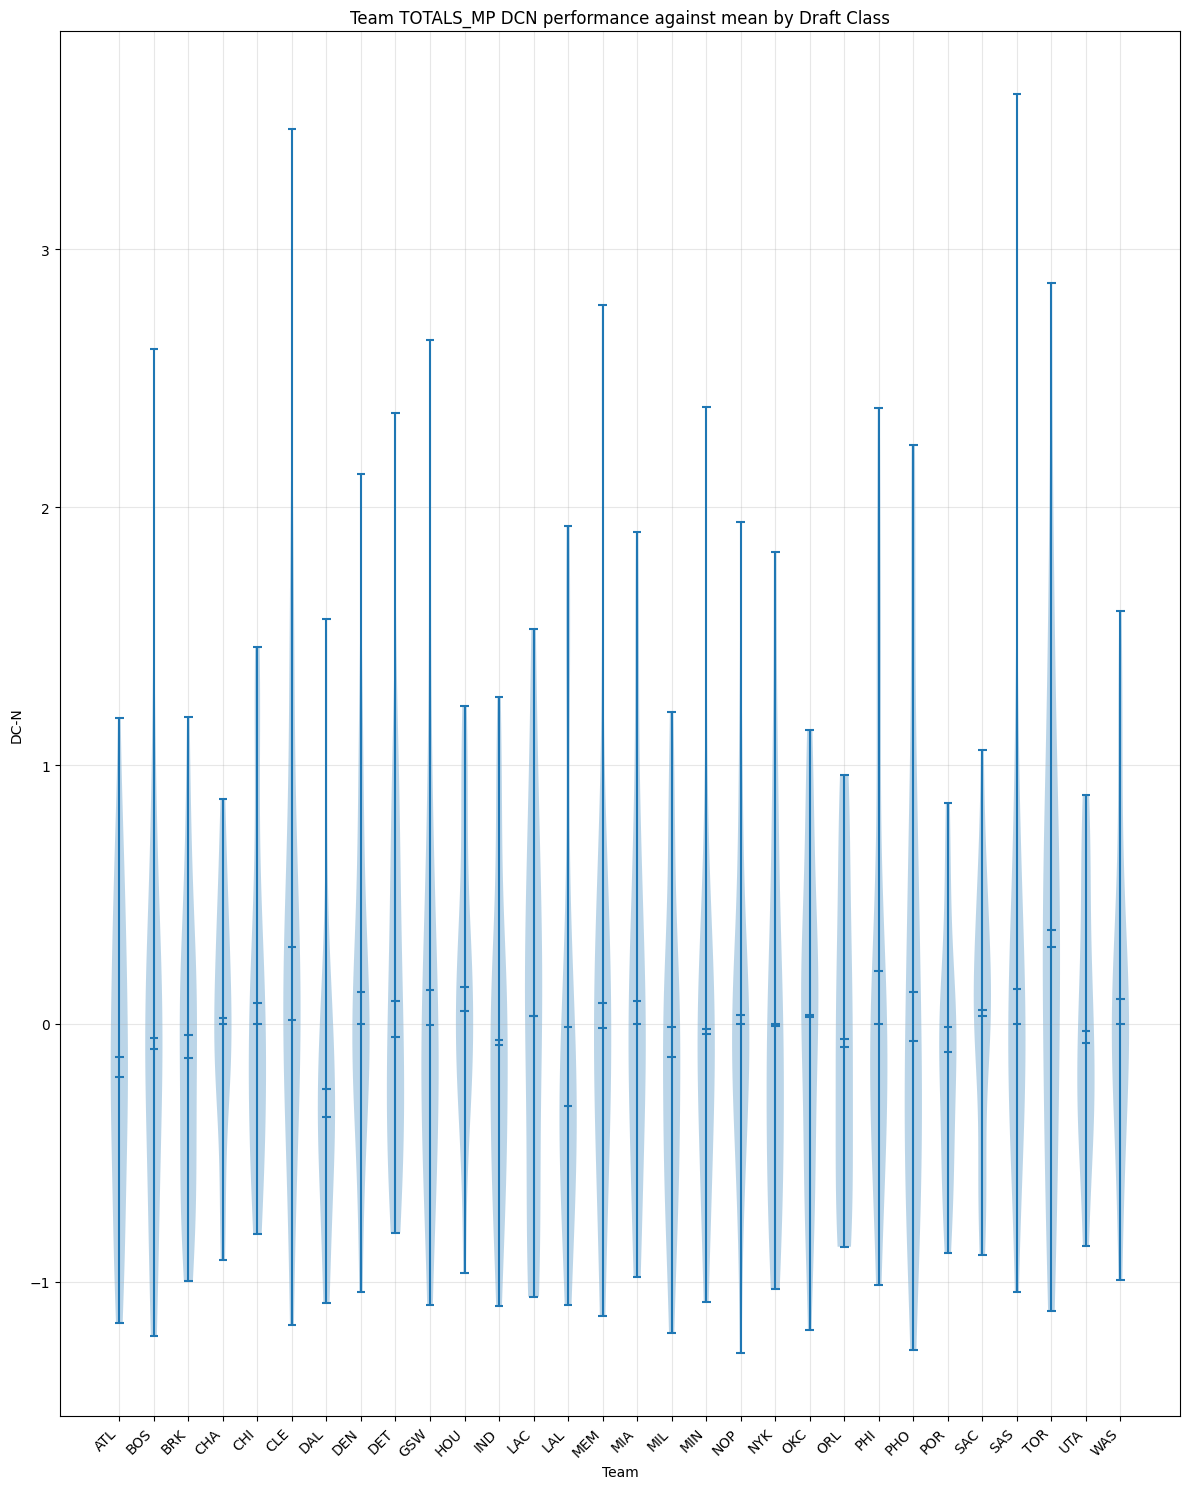

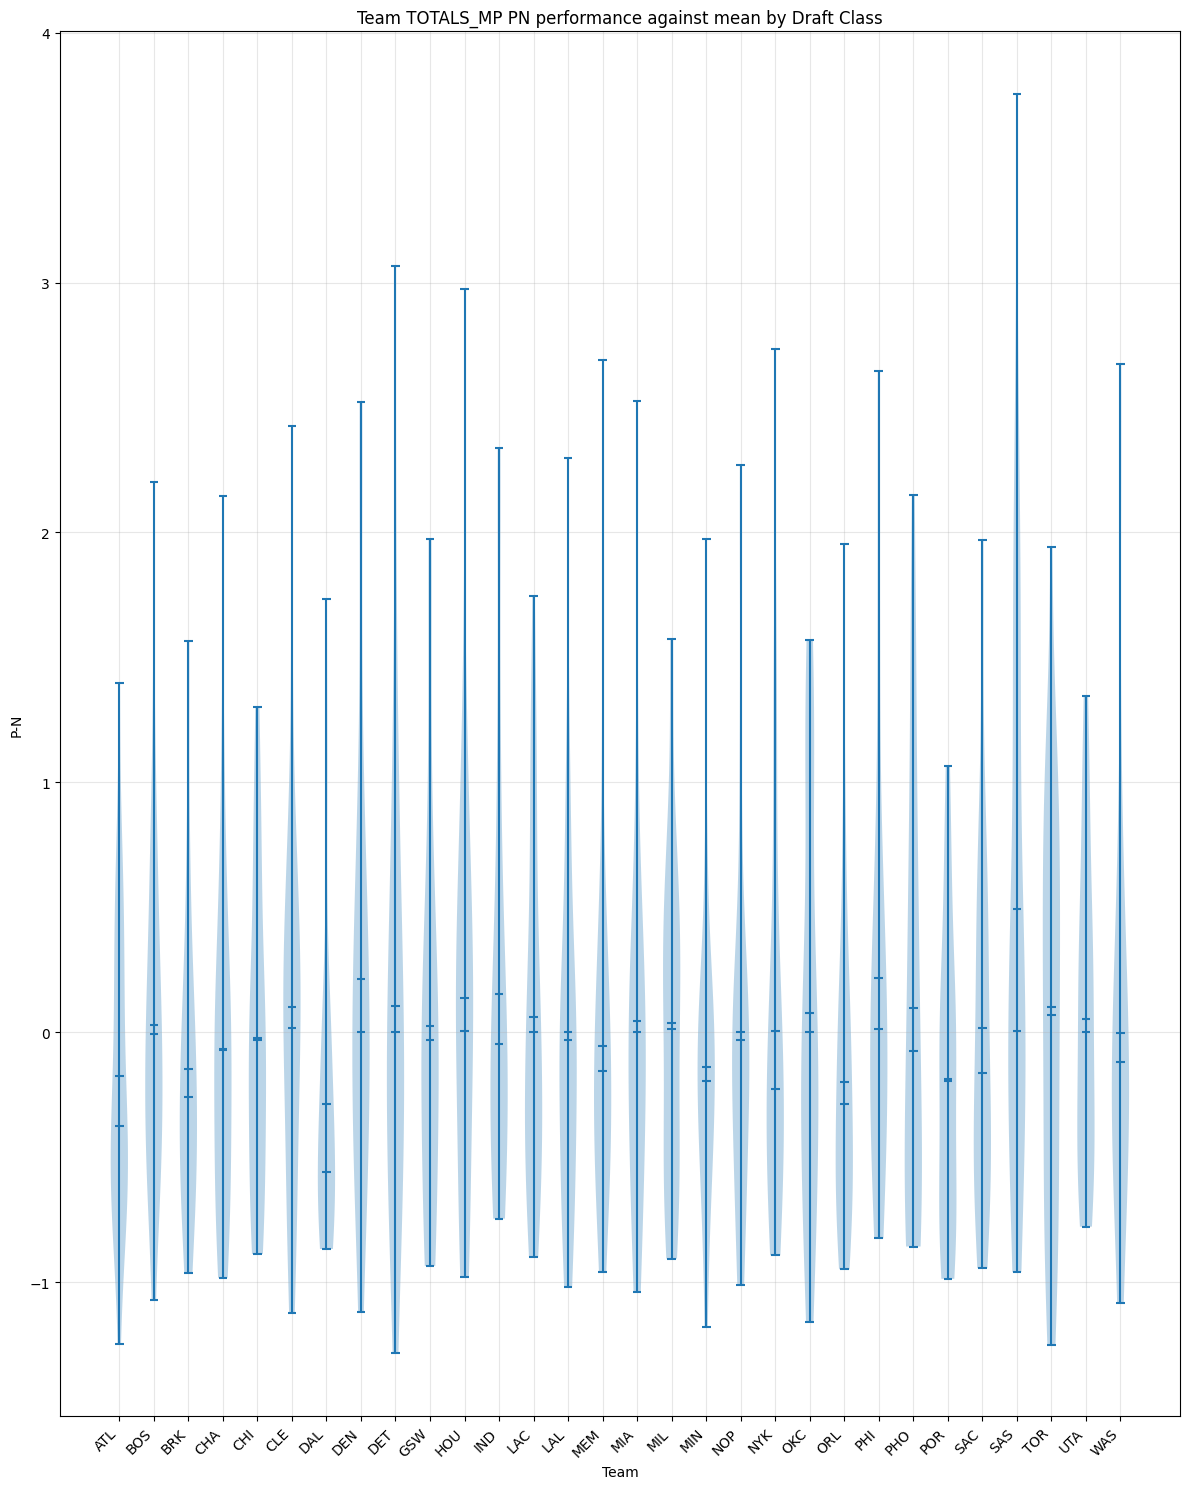

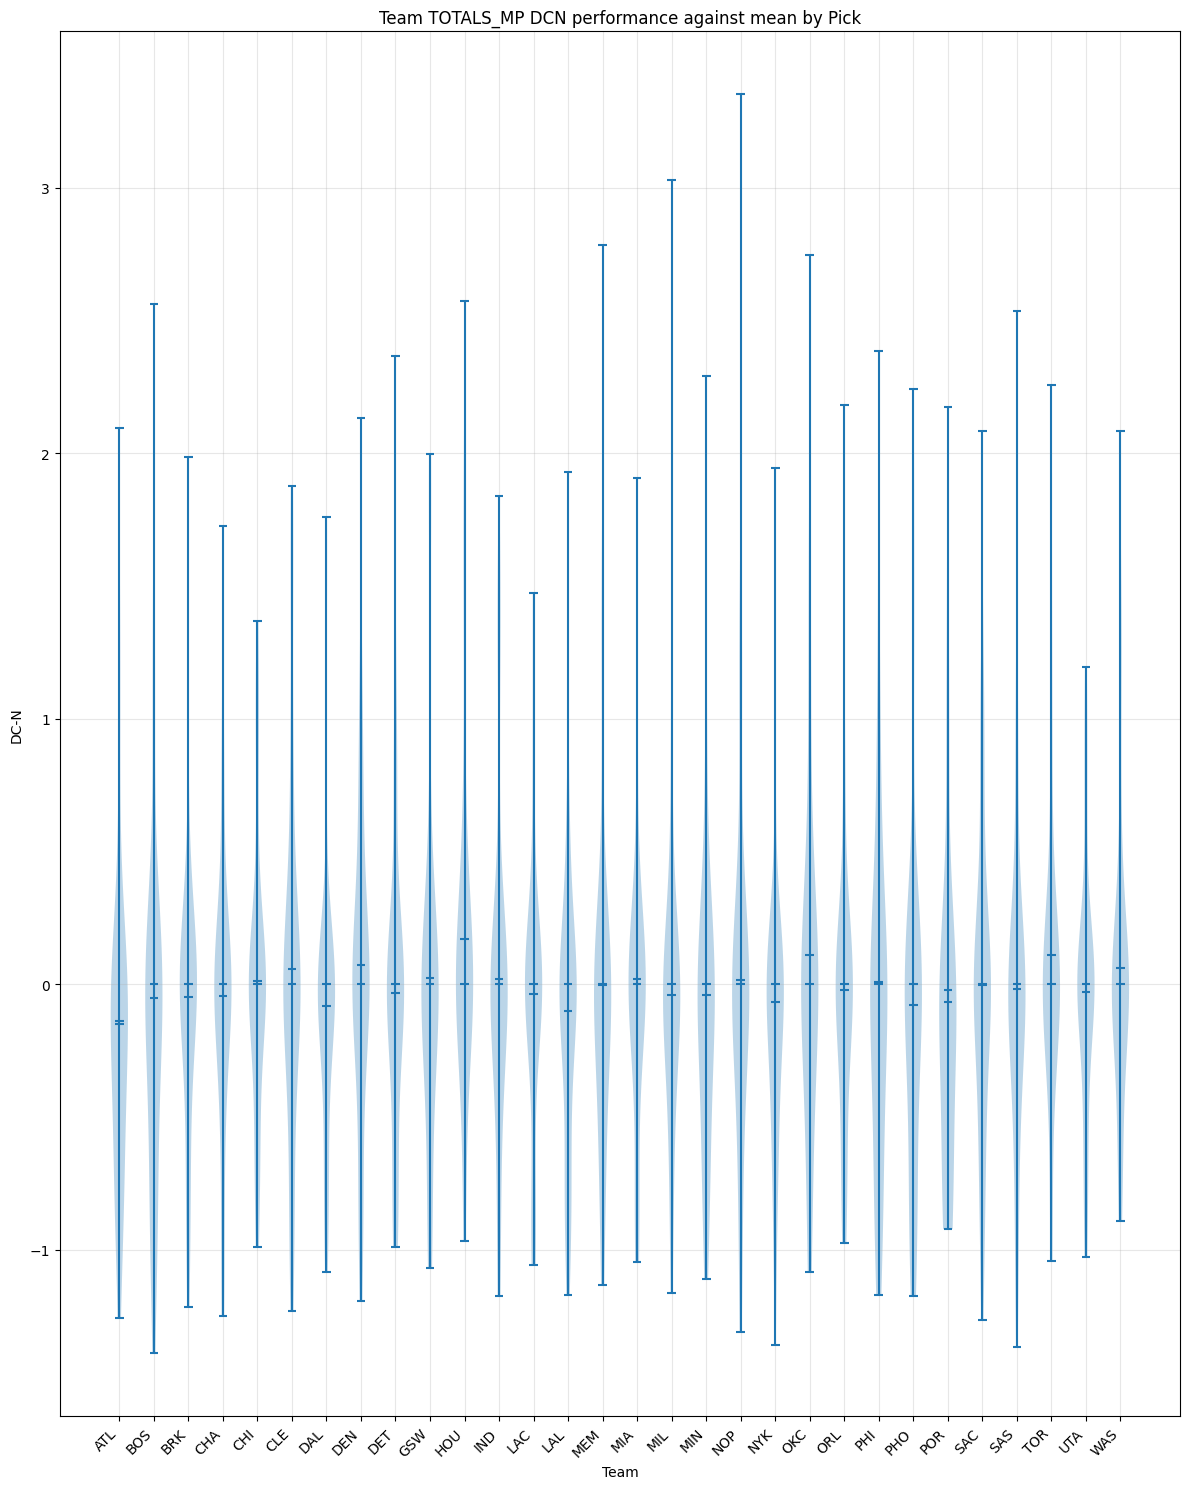

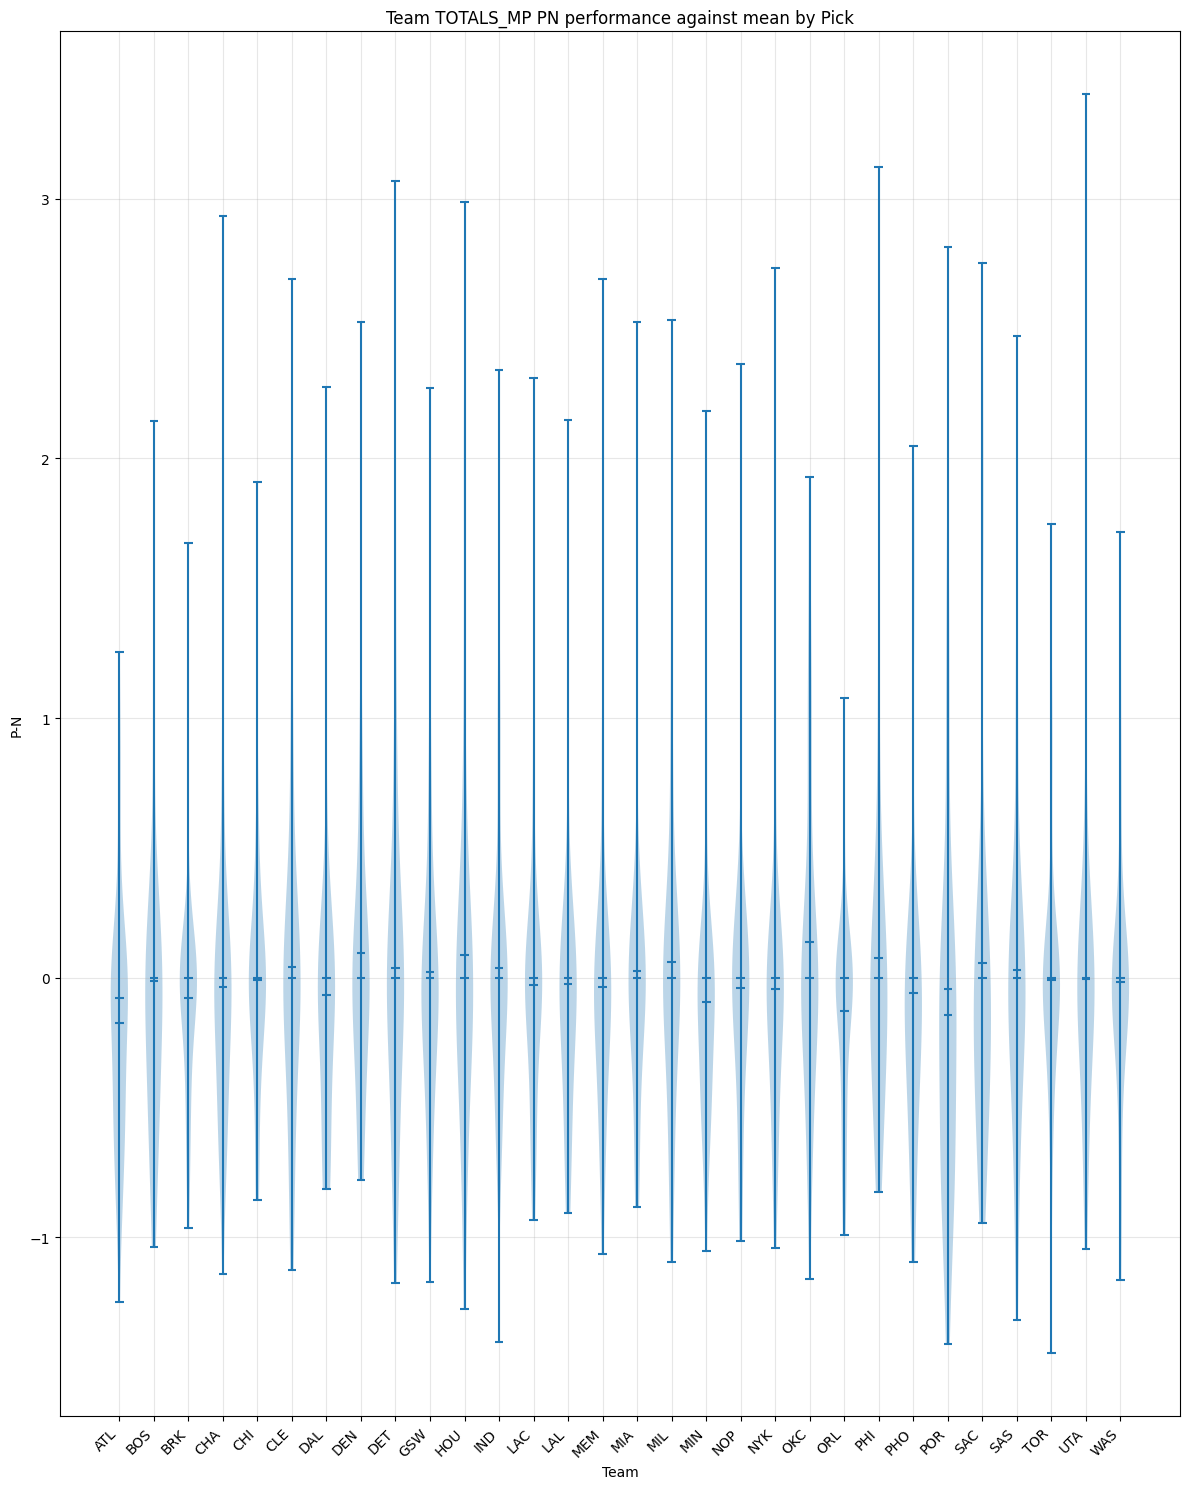

In [22]:
metric = 'TOTALS_MP'

plt.figure(figsize=(12,10))
plt.title('{} at each Pick'.format(metric))

x = df['PICK']
y = df[metric]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.scatter(x, y, alpha=0.15)
plt.plot(x, p(x), 'r--')
plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Draft Class at each Pick'.format(metric))

new_df = dc_normed_year[metric]

for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Draft Class at each Pick (minus the last few years)'.format(metric))

new_df = dc_normed_year[metric]

for col in new_df.columns:
    if int(col) < 2021:
        plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Pick at each Pick'.format(metric))

new_df = p_normed_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5 Year Moving average of {} Normed by Draft Class at each Pick'.format(metric))

new_df = dcma_year[metric]

all_x = []
all_y = []
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
    all_x.extend(new_df.index)
    all_y.extend(new_df[col])

all_x = np.array(all_x)
all_y = np.array(all_y)
mask = ~np.isnan(all_y)
all_x = all_x[mask]
all_y = all_y[mask]

coefficients = np.polyfit(all_x, all_y, 1)  # 1 = linear
poly = np.poly1d(coefficients)
x_line = np.linspace(all_x.min(), all_x.max(), 100)
plt.plot(x_line, poly(x_line), 'r--', linewidth=2, label='Best Fit')

plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5 Year Moving average of {} Normed by Pick at each Pick'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5YMA-PN {} 2004-2014'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    if int(col) > 2004 and int(col) < 2015:
        plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5YMA-PN {} 2015-2025'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    if int(col) > 2014:
        plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} DCN performance against mean by Draft Class'.format(metric))


new_df = team_aggs['dcn_{}_dc'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('DC-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} PN performance against mean by Draft Class'.format(metric))

new_df = team_aggs['pn_{}_dc'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('P-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} DCN performance against mean by Pick'.format(metric))

new_df = team_aggs['dcn_{}_p'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('DC-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} PN performance against mean by Pick'.format(metric))

new_df = team_aggs['pn_{}_p'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('P-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

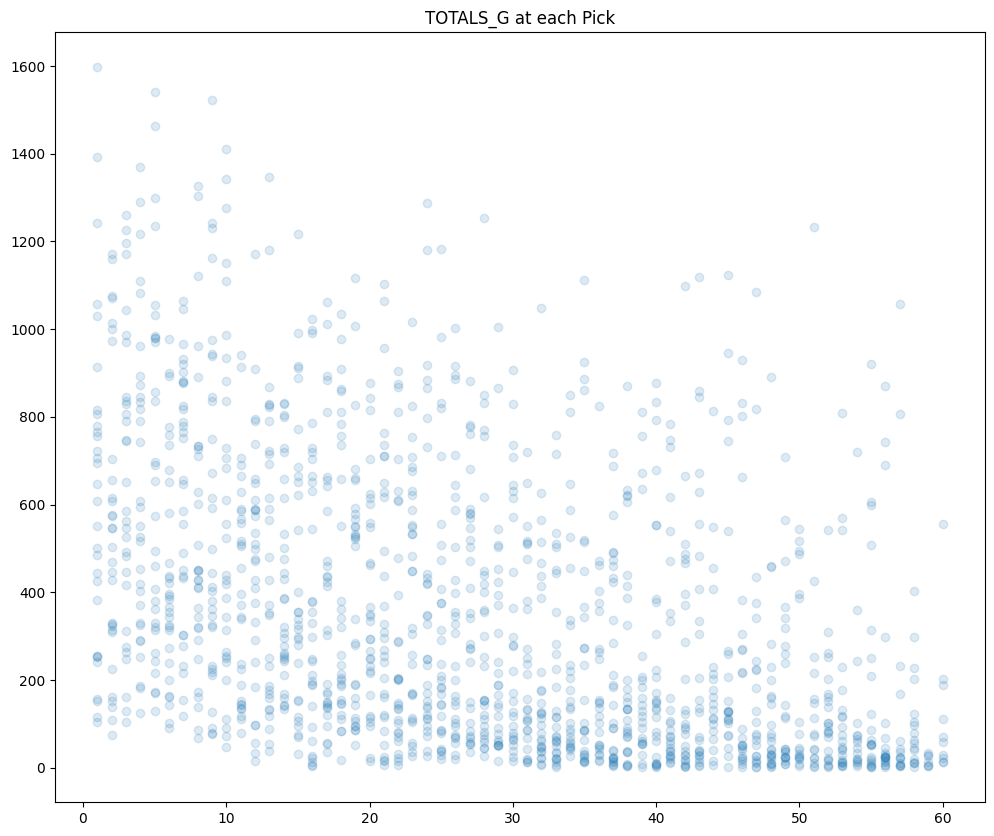

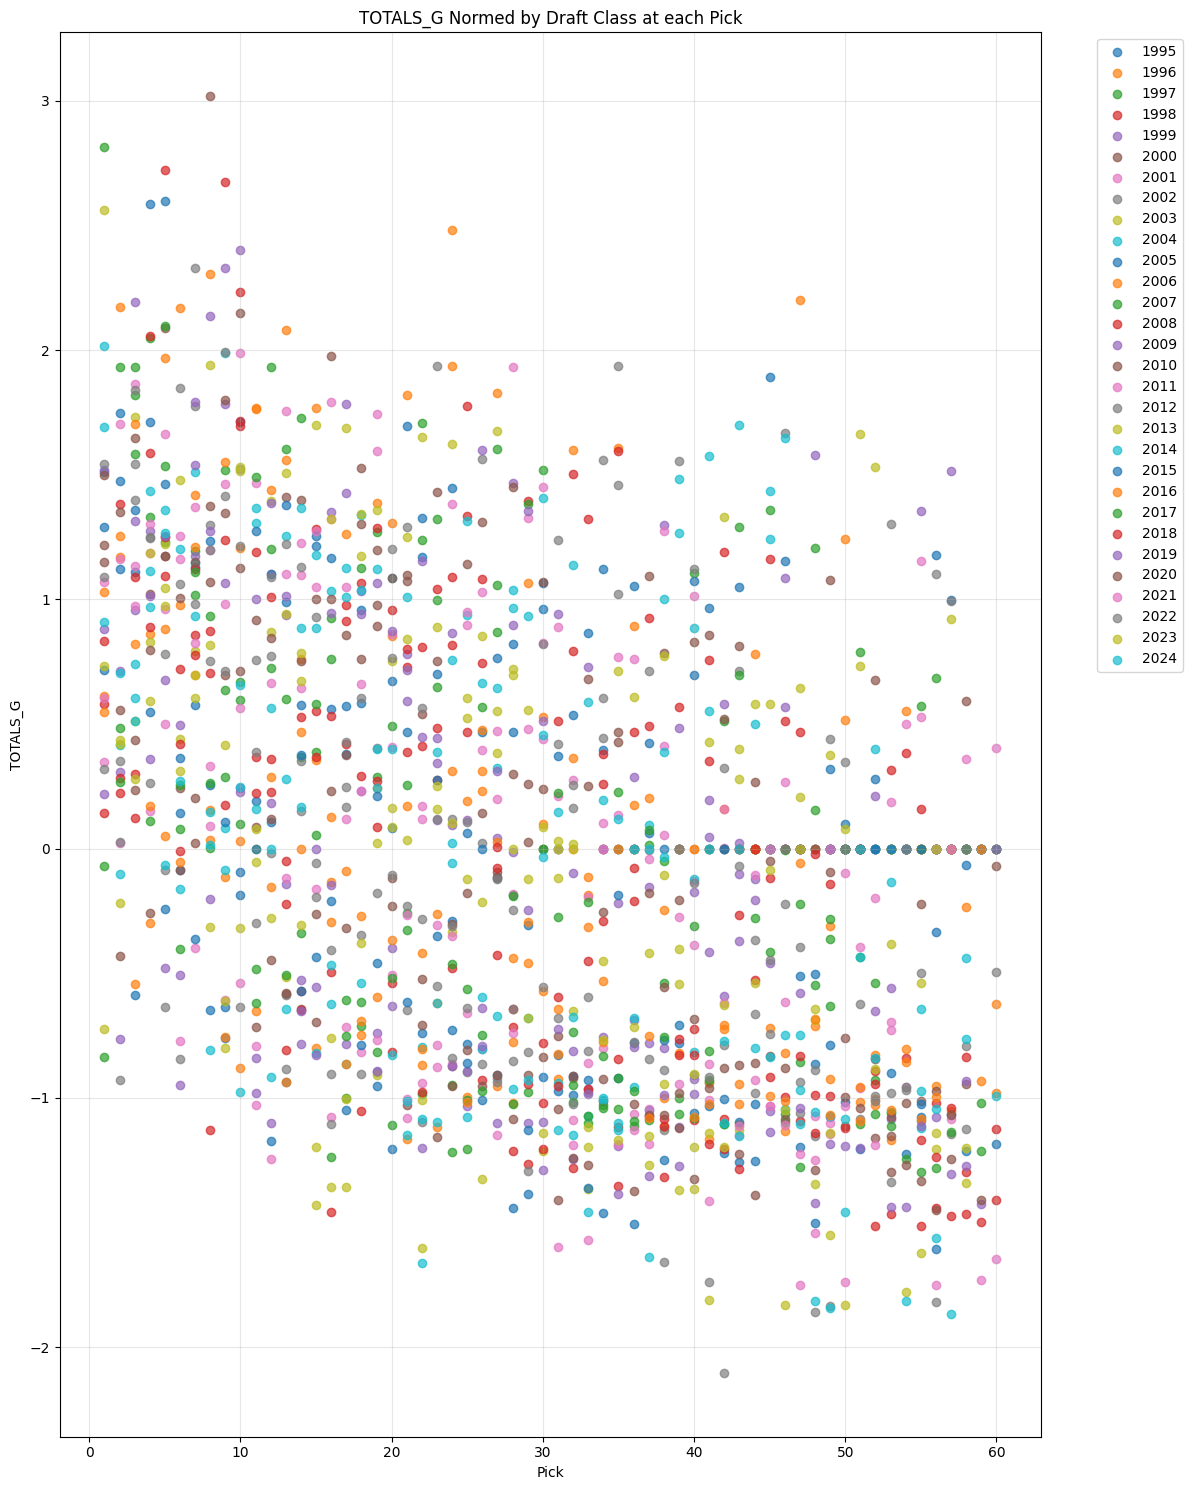

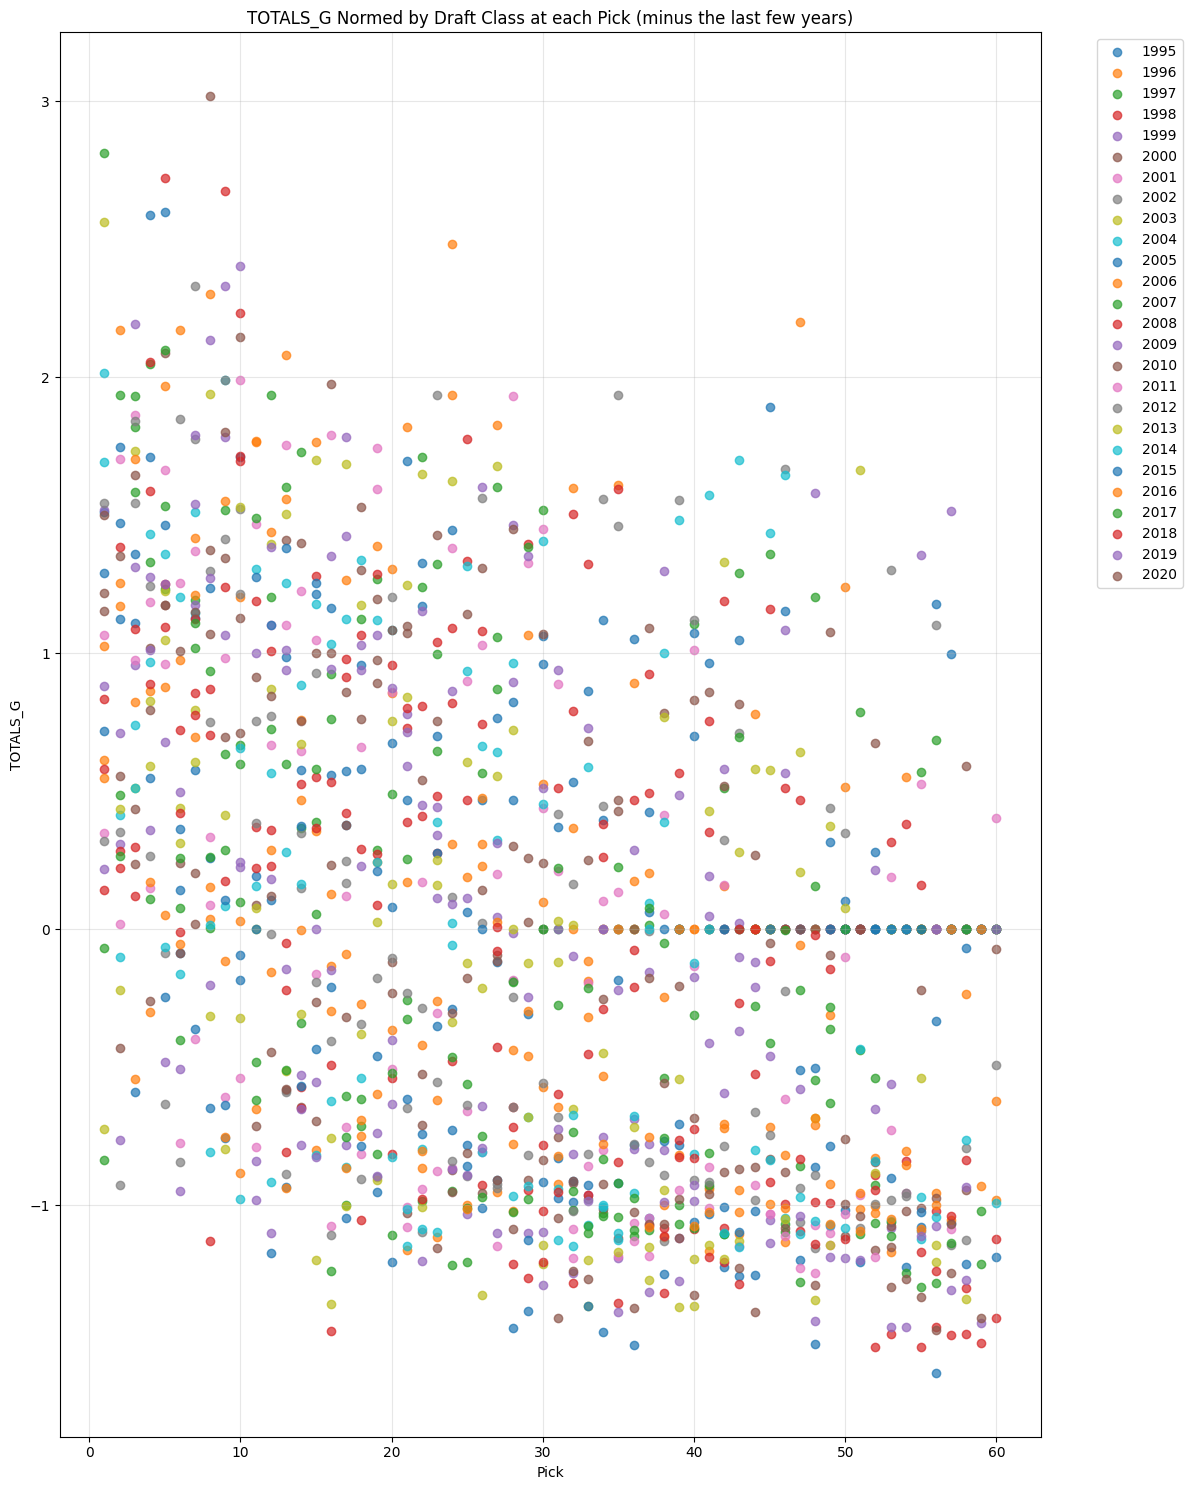

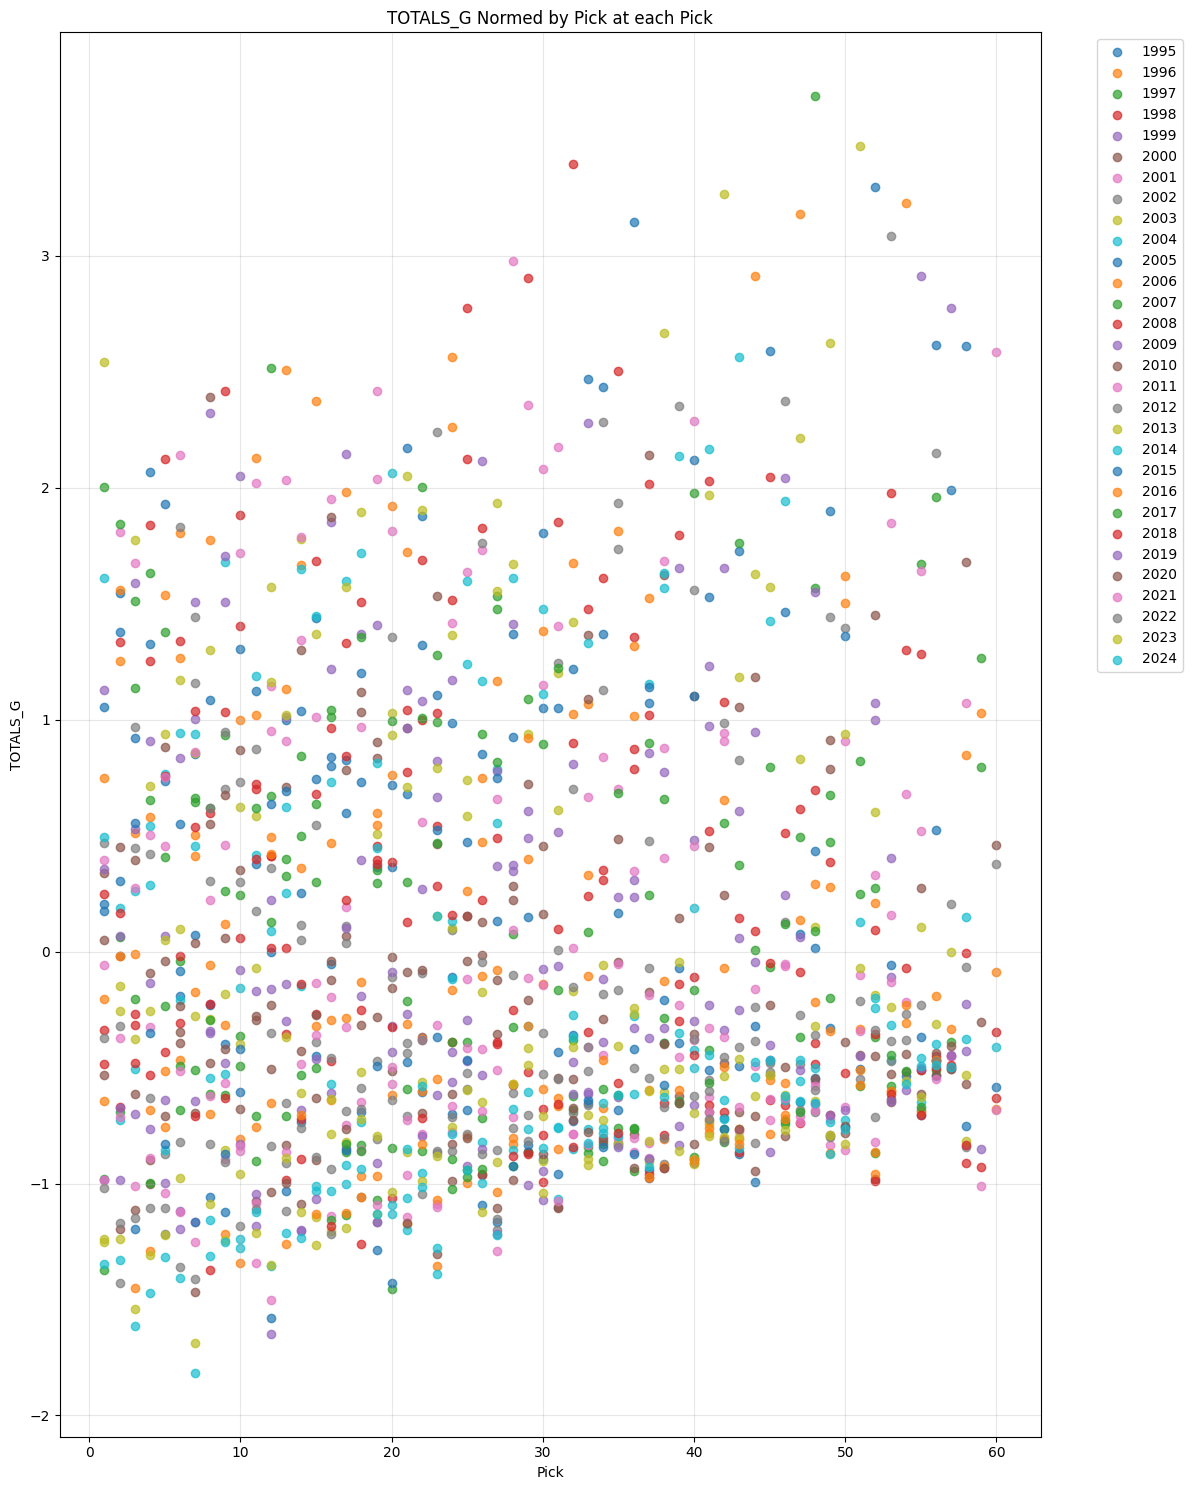

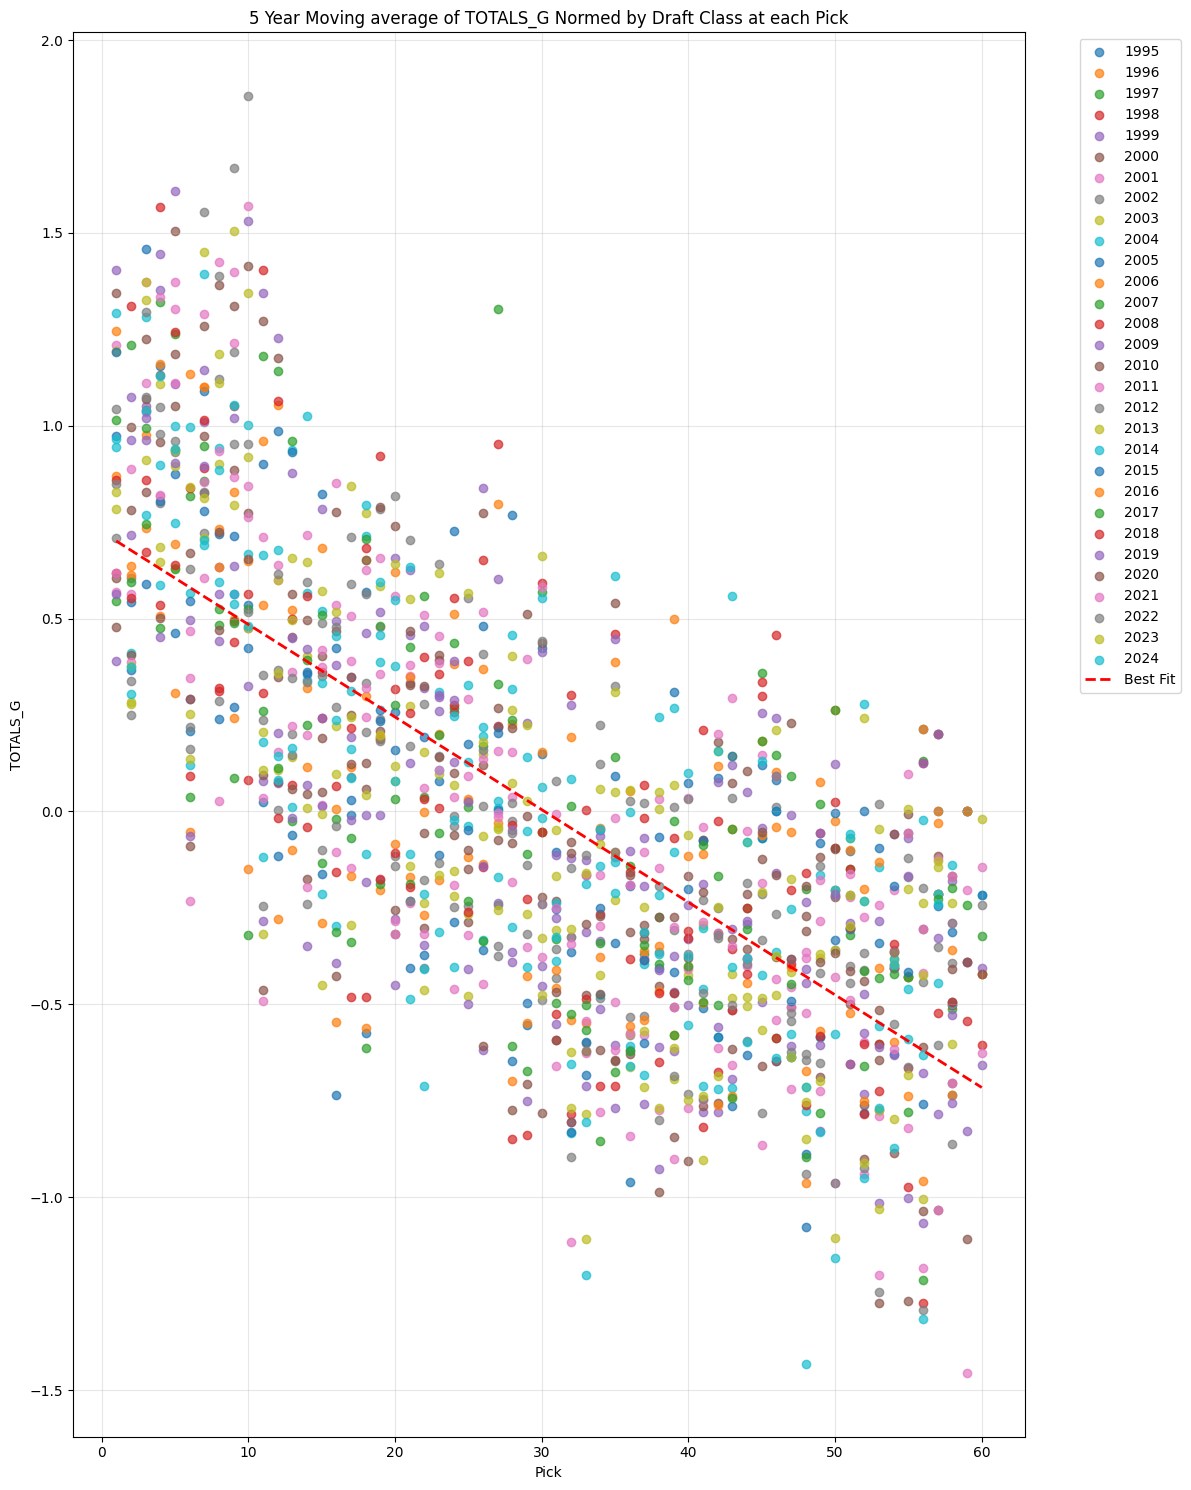

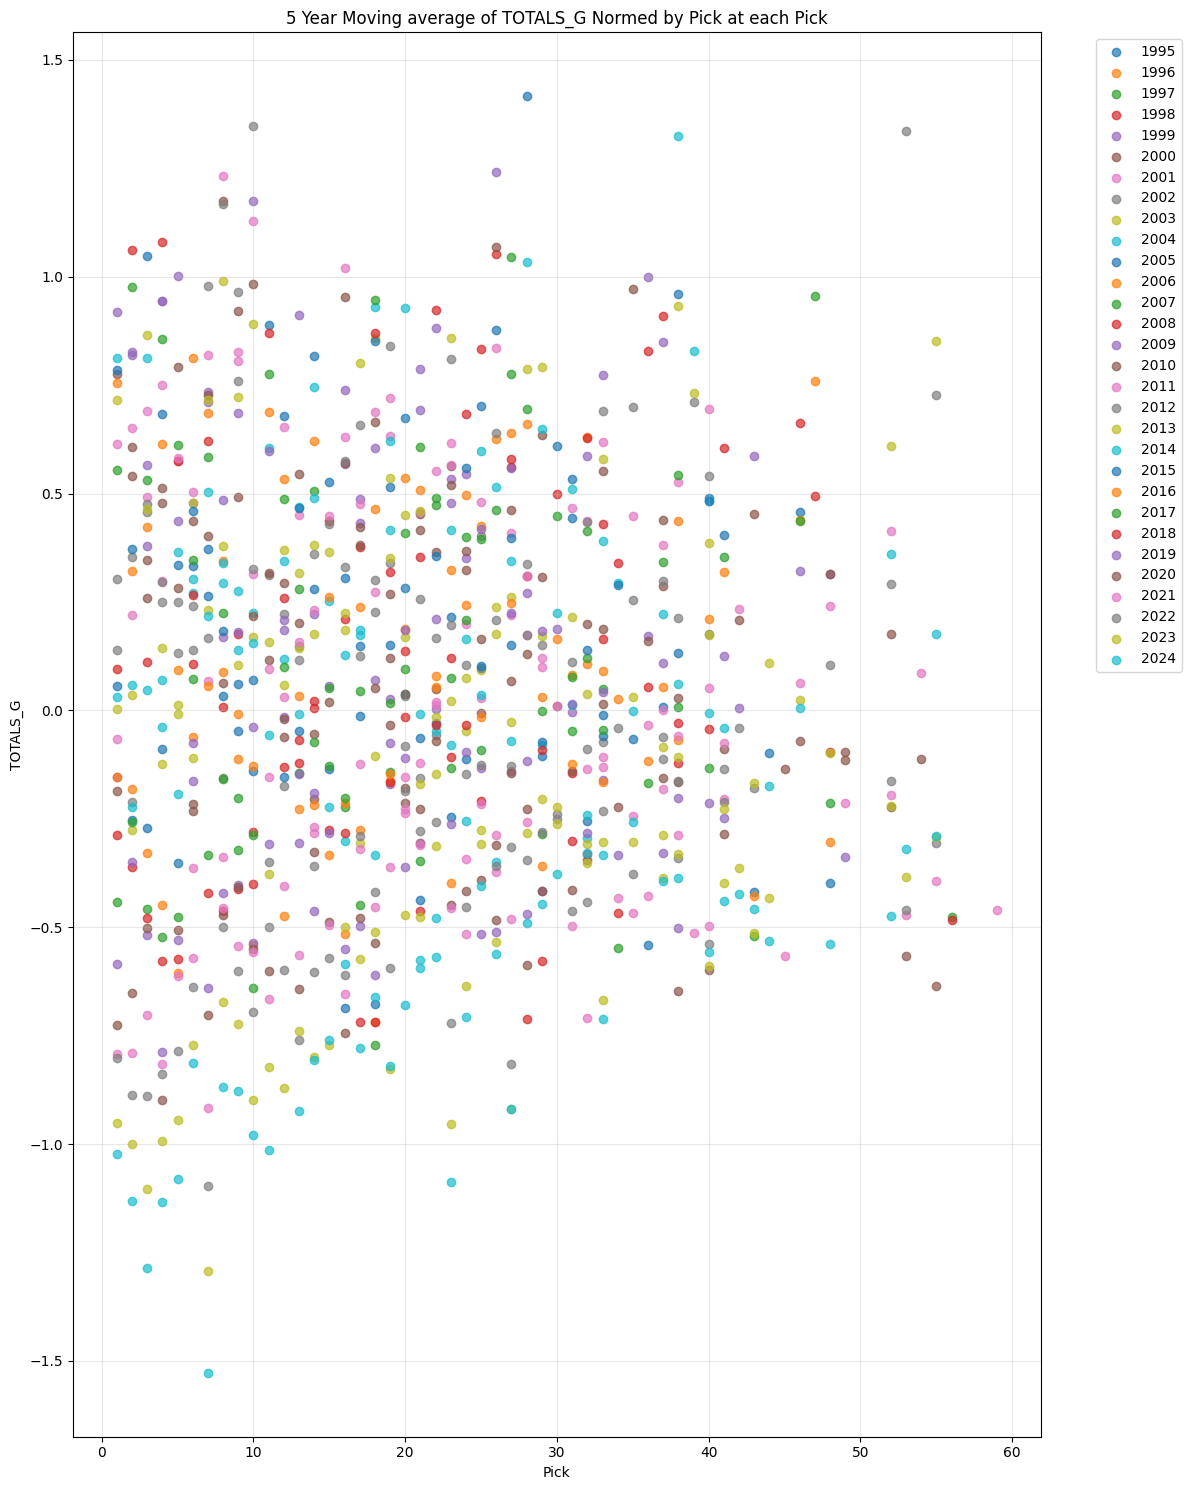

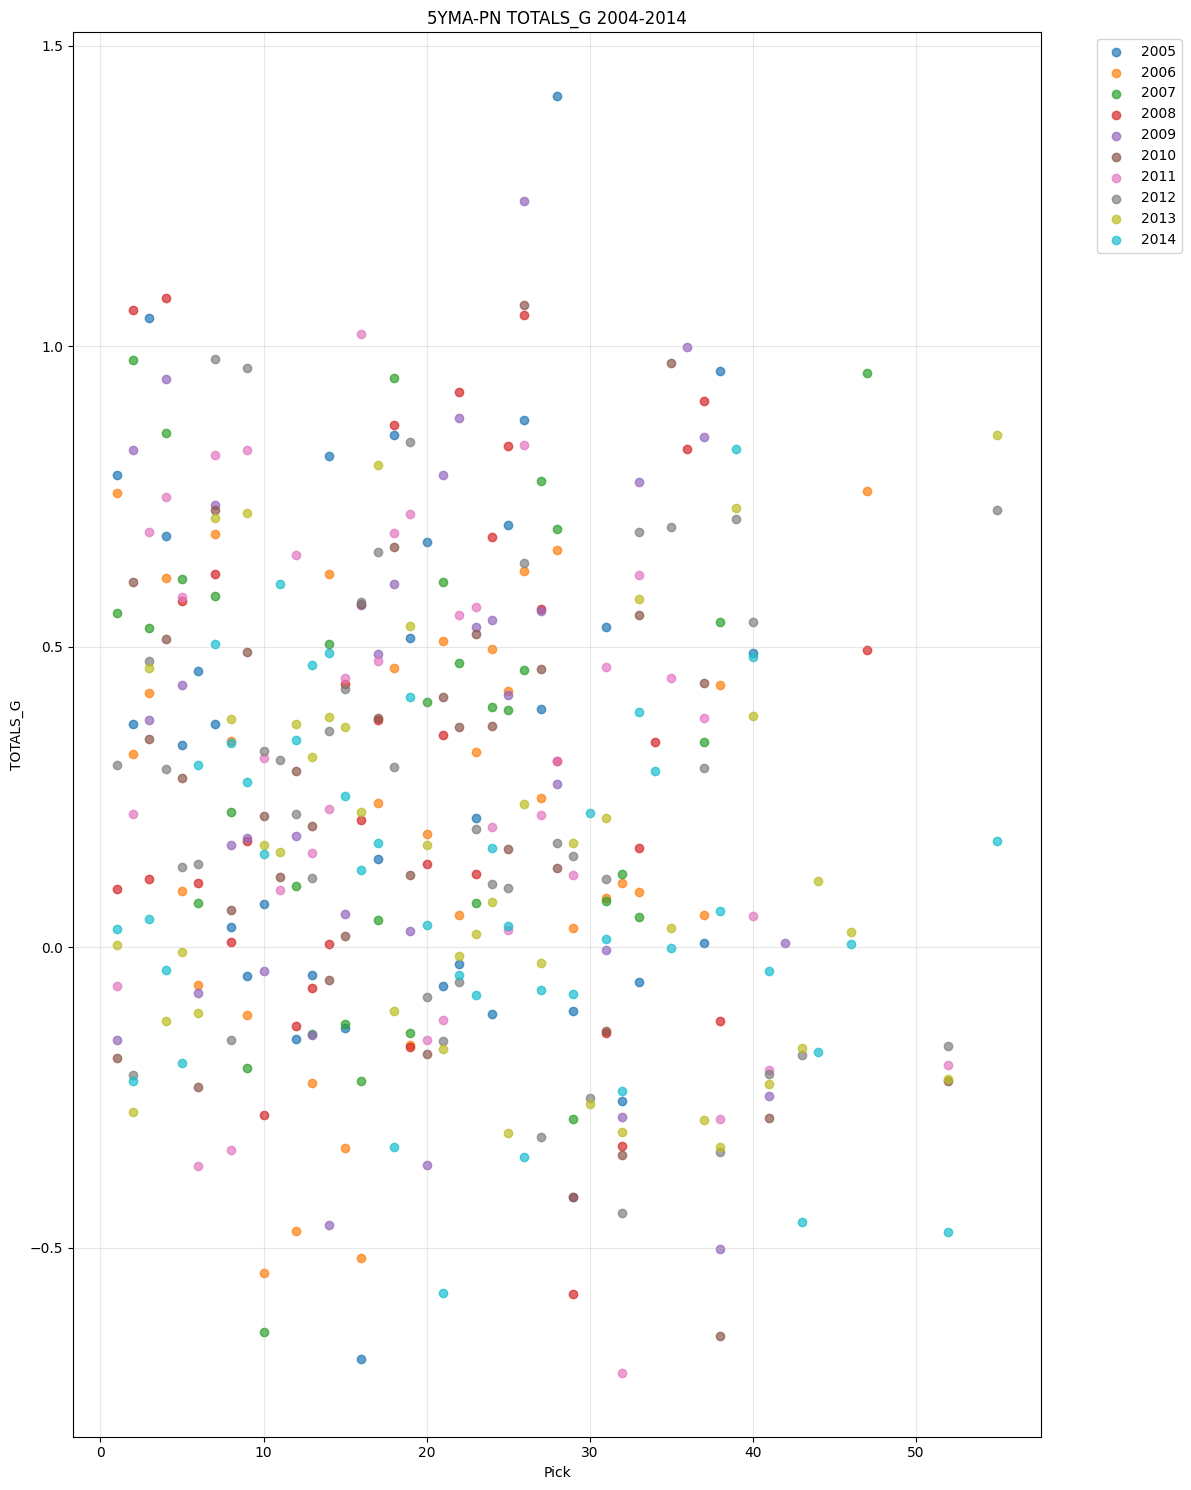

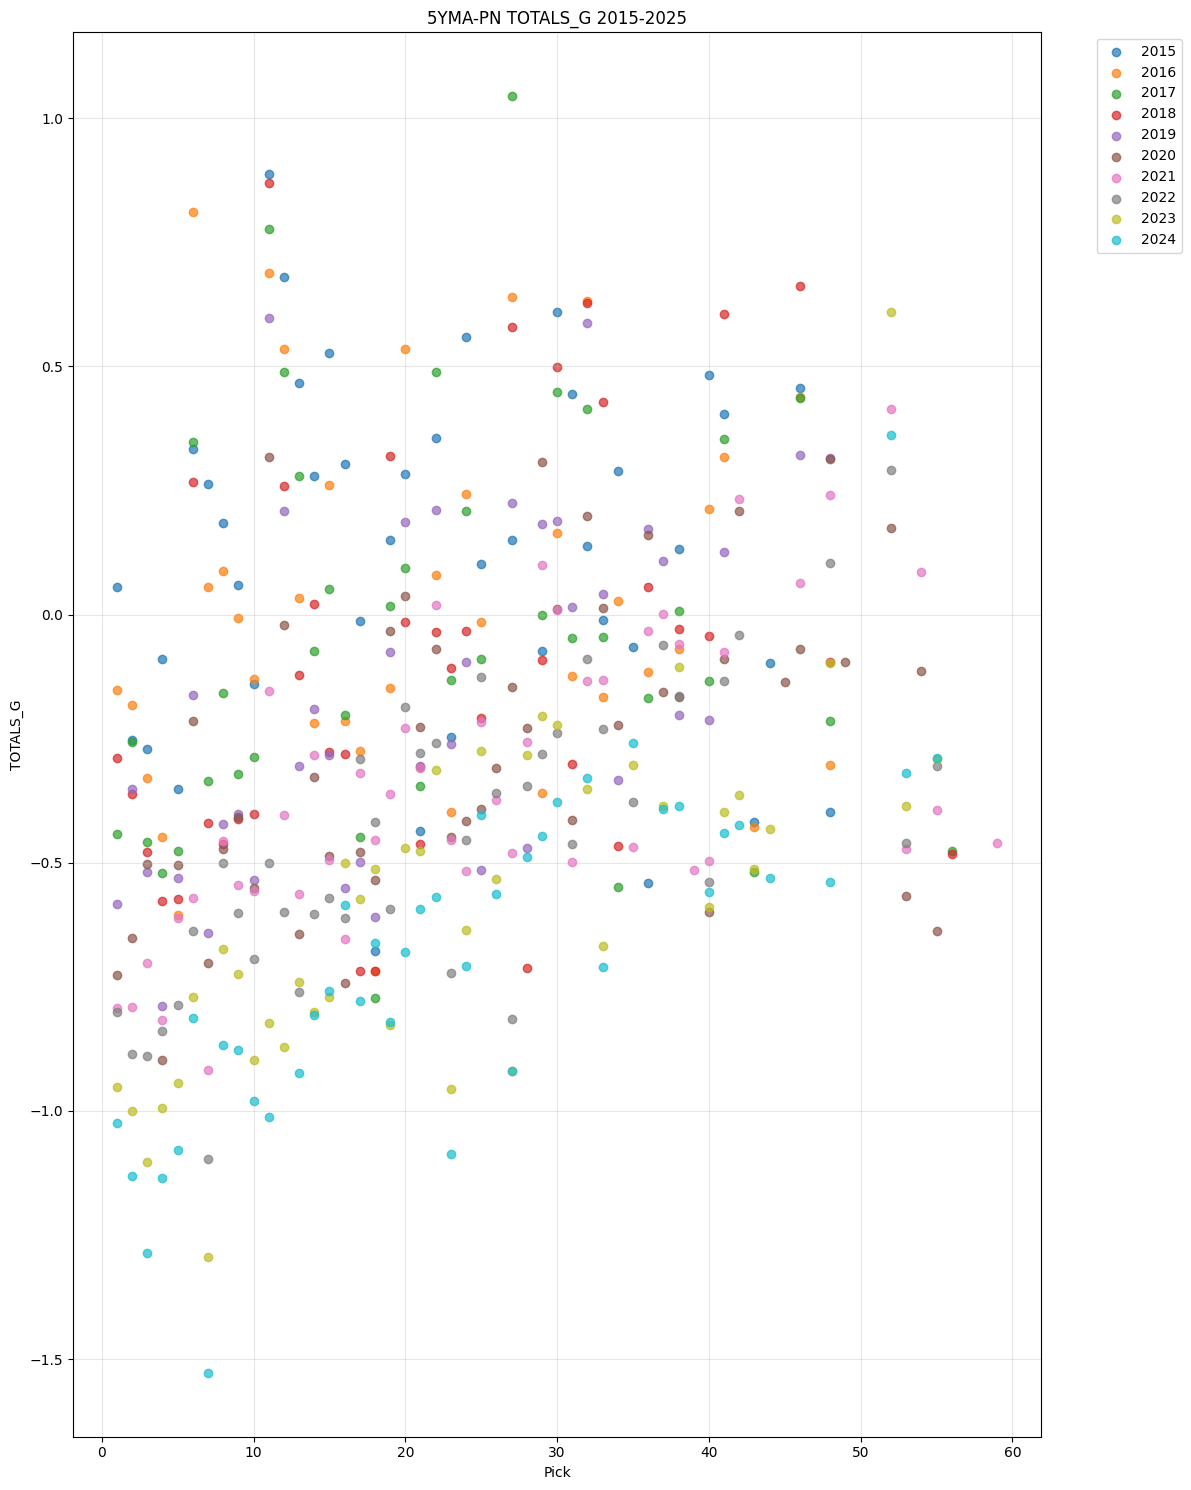

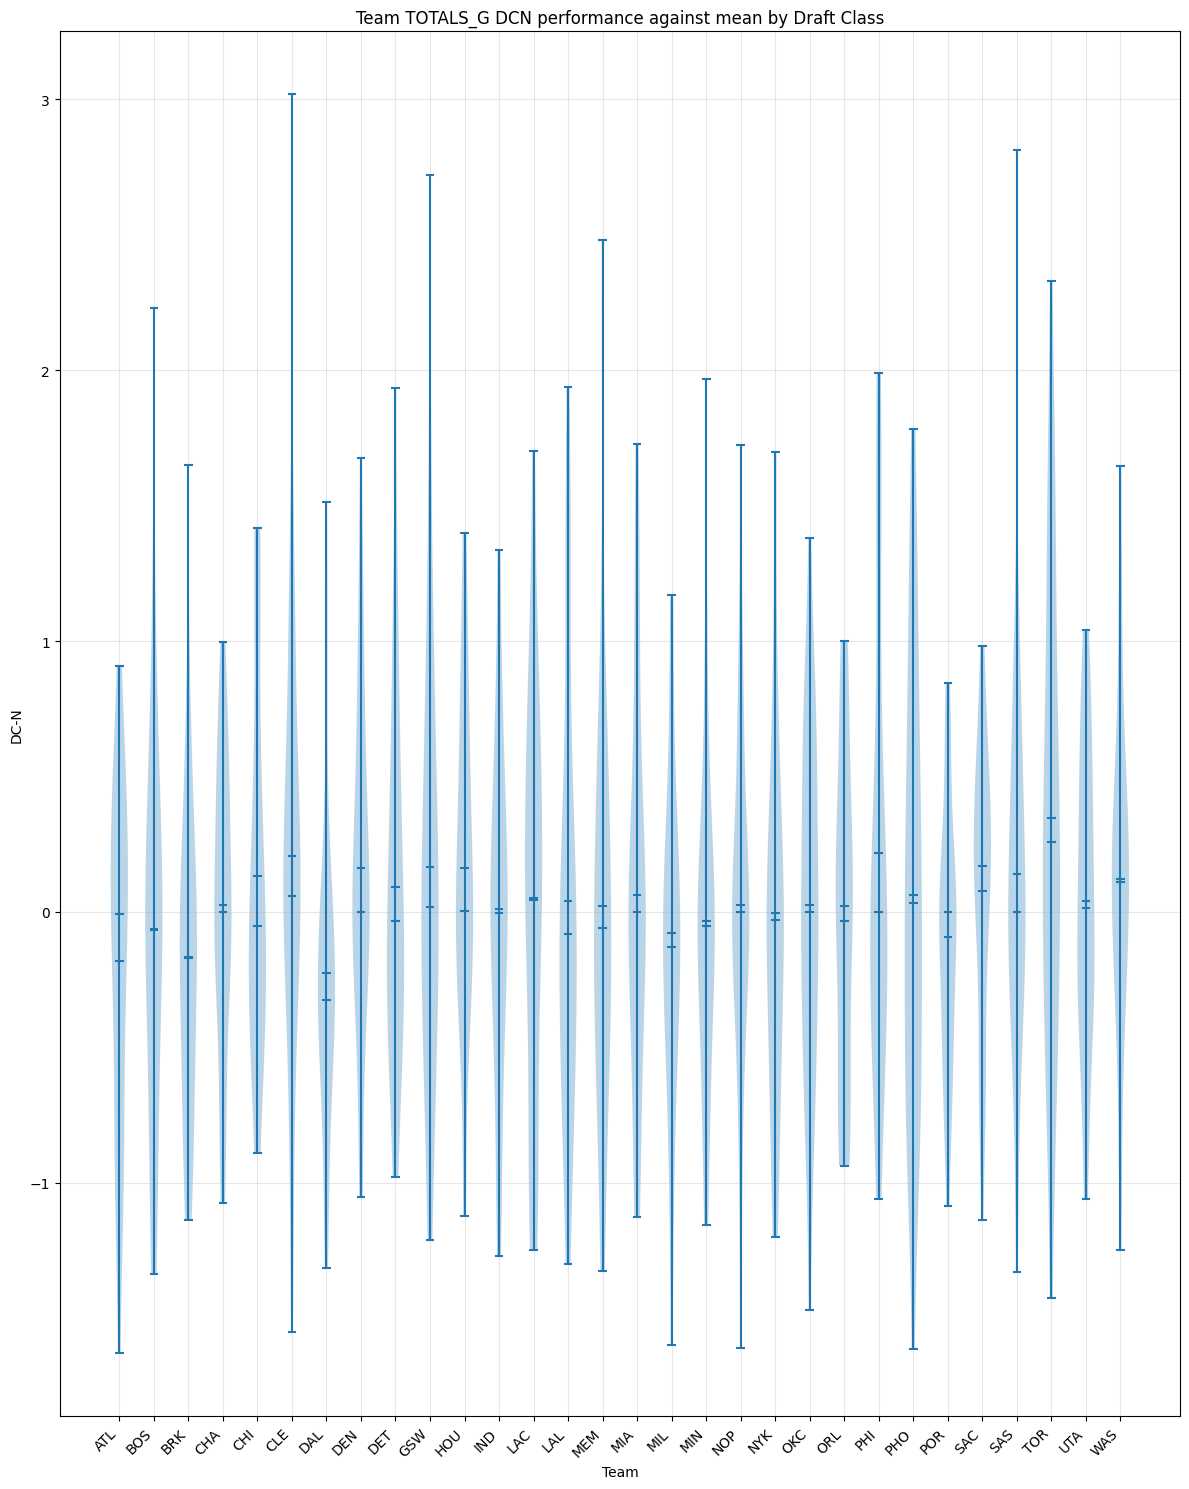

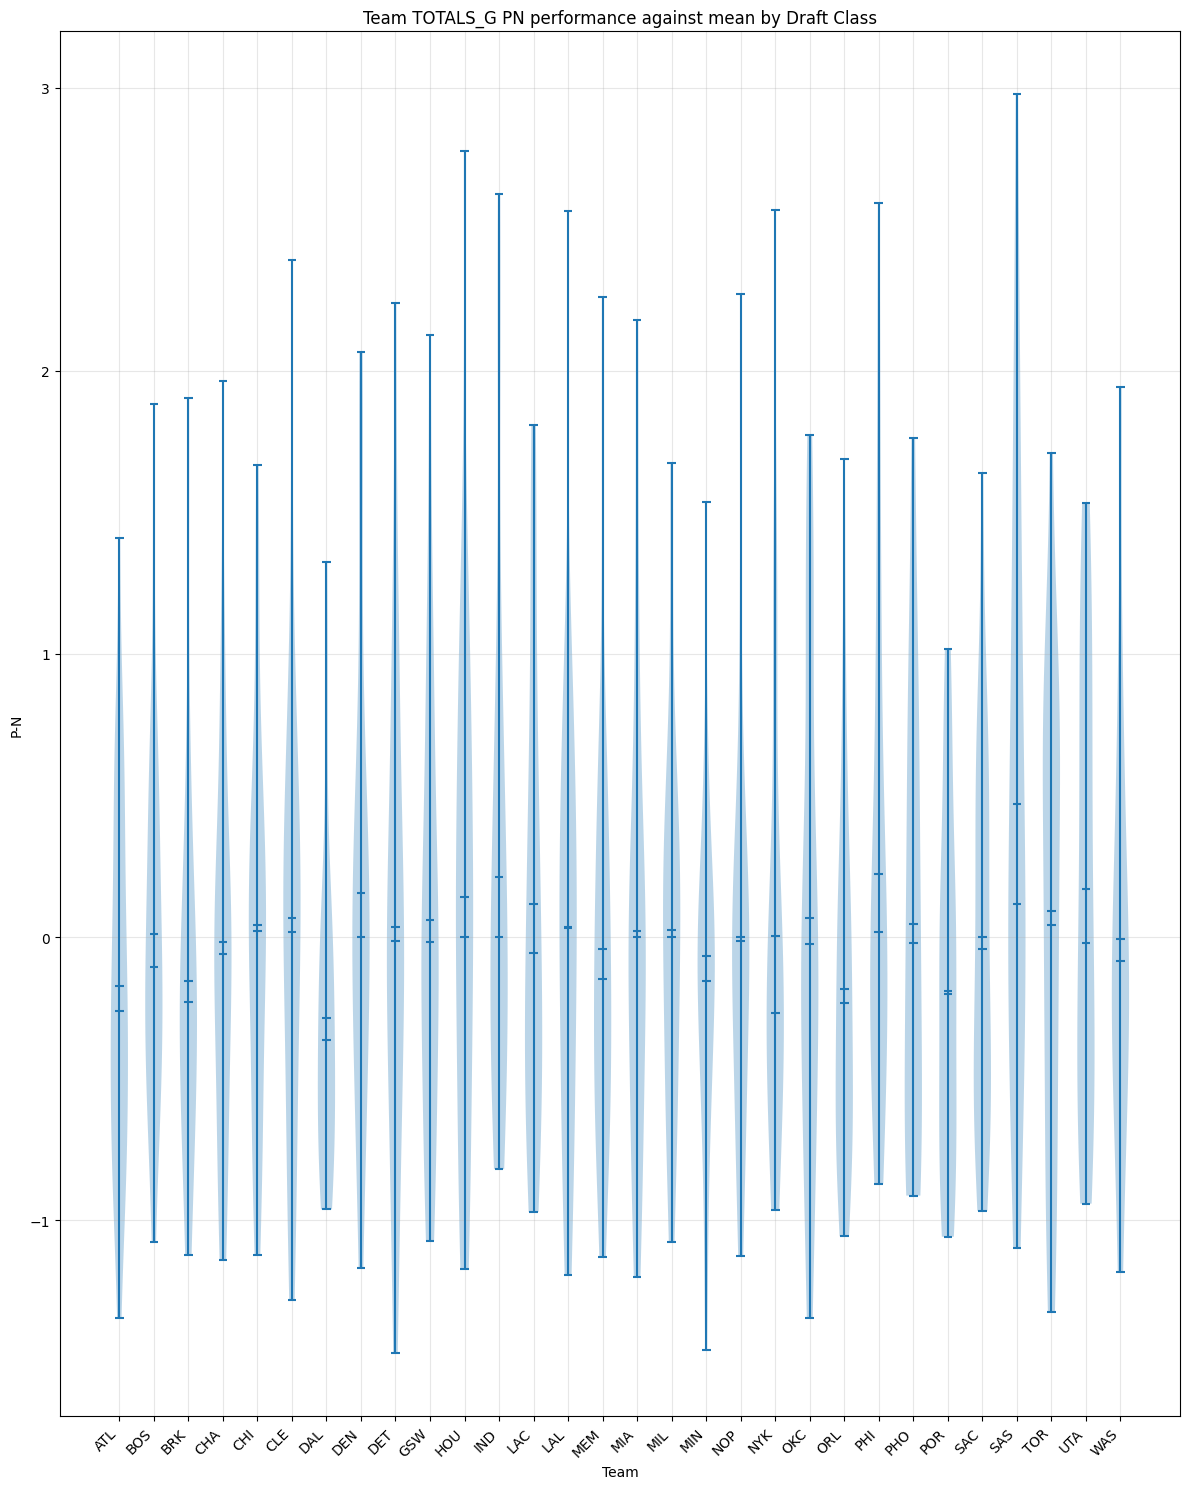

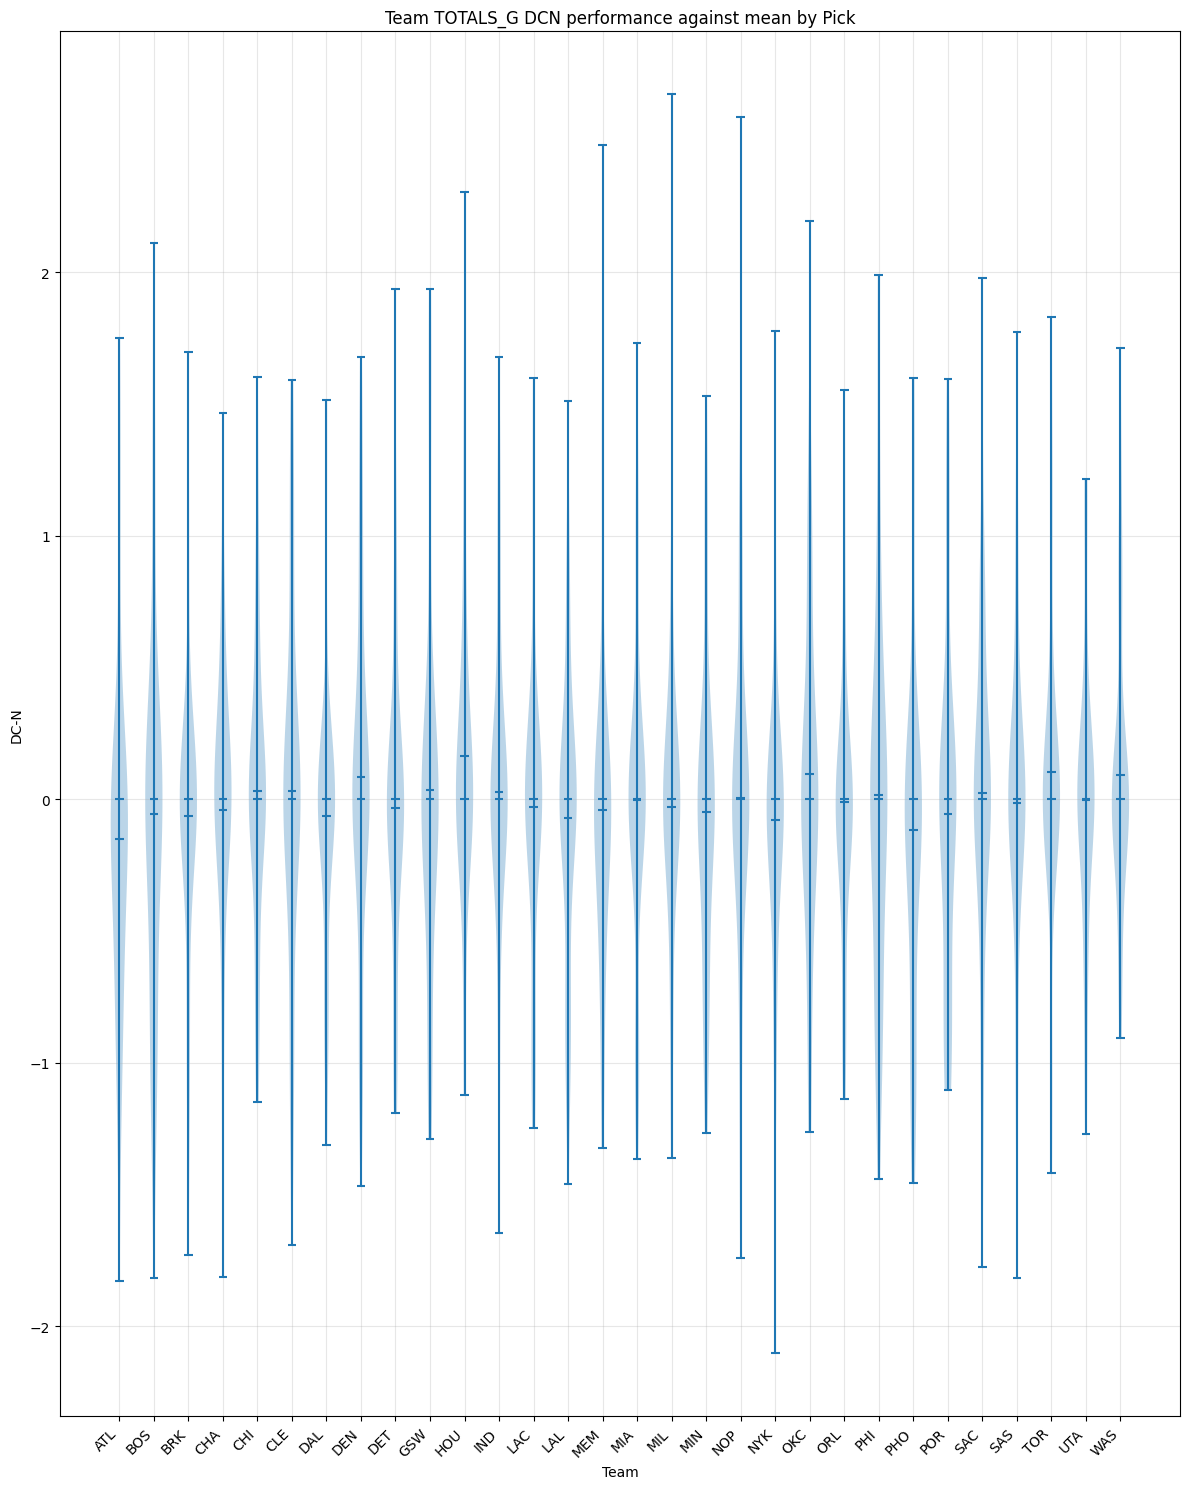

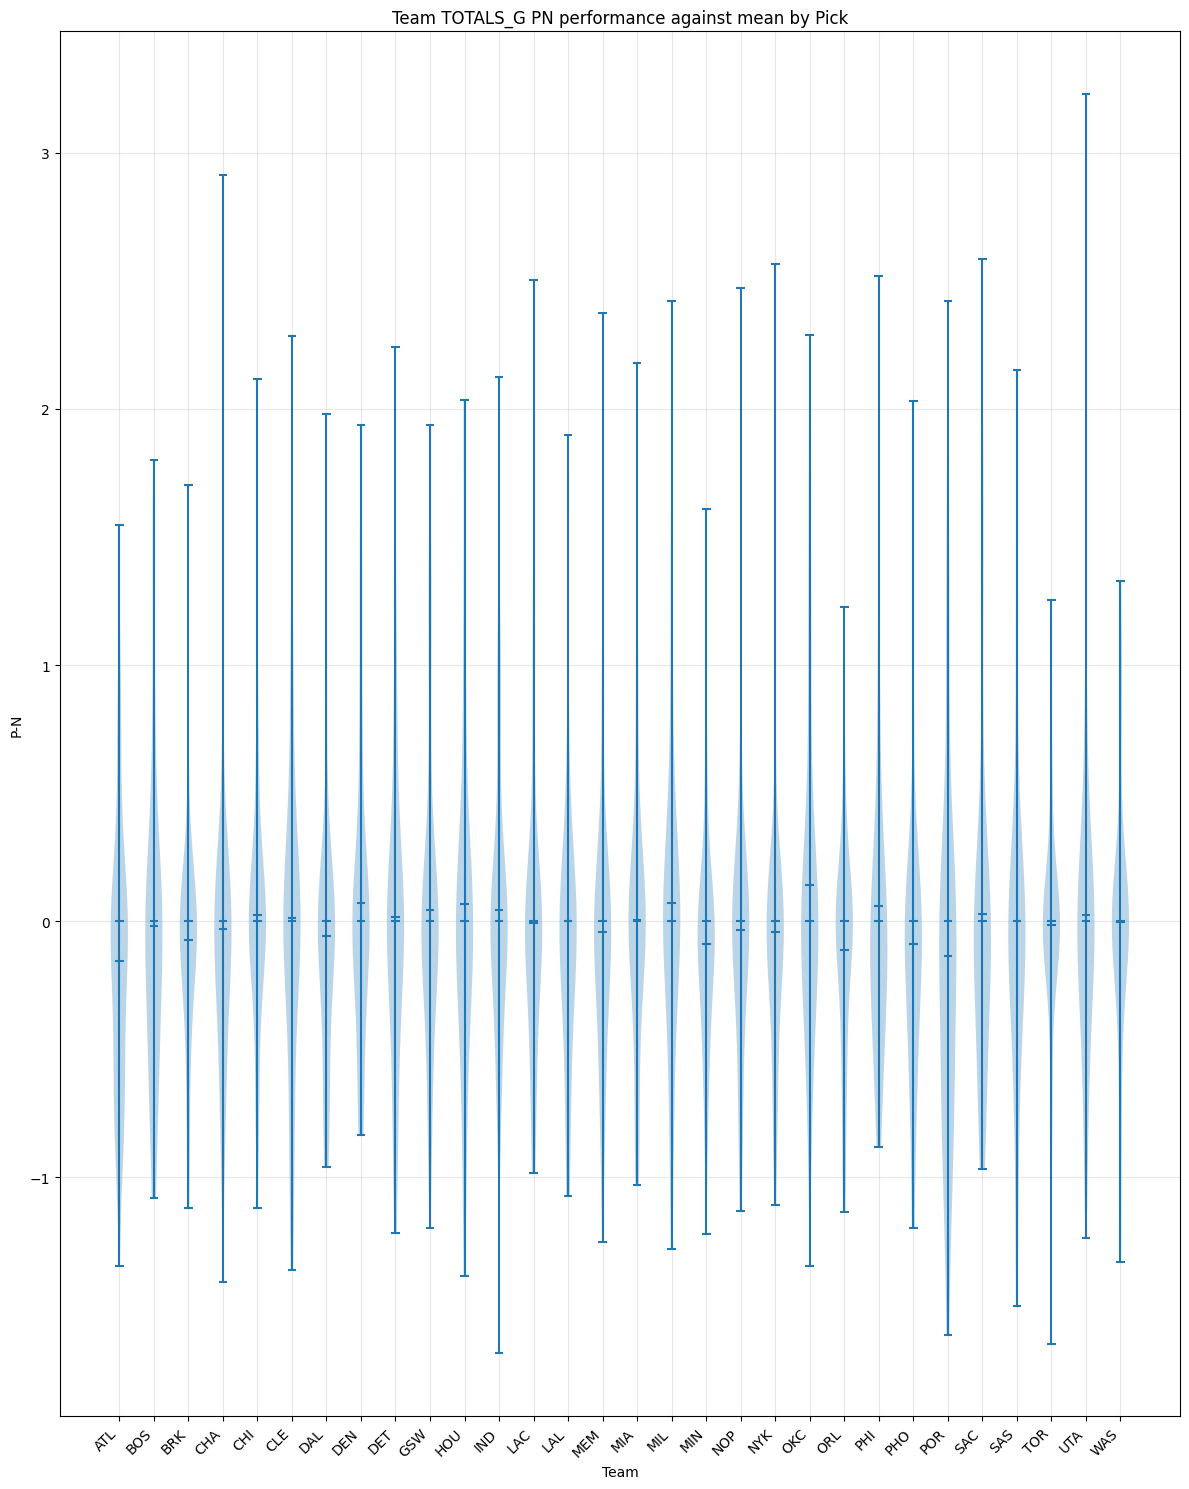

In [23]:
metric = 'TOTALS_G'


plt.figure(figsize=(12,10))
plt.title('{} at each Pick'.format(metric))

x = df['PICK']
y = df[metric]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.scatter(x, y, alpha=0.15)
plt.plot(x, p(x), 'r--')
plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Draft Class at each Pick'.format(metric))

new_df = dc_normed_year[metric]

for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Draft Class at each Pick (minus the last few years)'.format(metric))

new_df = dc_normed_year[metric]

for col in new_df.columns:
    if int(col) < 2021:
        plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Pick at each Pick'.format(metric))

new_df = p_normed_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5 Year Moving average of {} Normed by Draft Class at each Pick'.format(metric))

new_df = dcma_year[metric]

all_x = []
all_y = []
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
    all_x.extend(new_df.index)
    all_y.extend(new_df[col])

all_x = np.array(all_x)
all_y = np.array(all_y)
mask = ~np.isnan(all_y)
all_x = all_x[mask]
all_y = all_y[mask]

coefficients = np.polyfit(all_x, all_y, 1)  # 1 = linear
poly = np.poly1d(coefficients)
x_line = np.linspace(all_x.min(), all_x.max(), 100)
plt.plot(x_line, poly(x_line), 'r--', linewidth=2, label='Best Fit')

plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5 Year Moving average of {} Normed by Pick at each Pick'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5YMA-PN {} 2004-2014'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    if int(col) > 2004 and int(col) < 2015:
        plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5YMA-PN {} 2015-2025'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    if int(col) > 2014:
        plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} DCN performance against mean by Draft Class'.format(metric))


new_df = team_aggs['dcn_{}_dc'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('DC-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} PN performance against mean by Draft Class'.format(metric))

new_df = team_aggs['pn_{}_dc'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('P-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} DCN performance against mean by Pick'.format(metric))

new_df = team_aggs['dcn_{}_p'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('DC-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} PN performance against mean by Pick'.format(metric))

new_df = team_aggs['pn_{}_p'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('P-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
metric = 'ADVANCED_WS'

# plt.figure(figsize=(12,10))
# plt.title('{} at each Pick'.format(metric))

# x = df['PICK']
# y = df[metric]

# z = np.polyfit(x, y, 1)
# p = np.poly1d(z)

# plt.scatter(x, y, alpha=0.15)
# plt.plot(x, p(x), 'r--')
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('{} Normed by Draft Class at each Pick'.format(metric))

# new_df = dc_normed_year[metric]

# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('{} Normed by Pick at each Pick'.format(metric))

# new_df = p_normed_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('5 Year Moving average of {} Normed by Draft Class at each Pick'.format(metric))

new_df = dcma_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5 Year Moving average of {} Normed by Pick at each Pick'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5YMA-PN {} 2004-2014'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     if int(col) > 2004 and int(col) < 2015:
#         plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5YMA-PN {} 2015-2025'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     if int(col) > 2014:
#         plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('Team {} performance against mean by Draft Class'.format(metric))

new_df = team_aggs['dcn_{}_dc'.format(metric)]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Team')
plt.ylabel('DCN')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Draft Class'.format(metric))

# new_df = team_aggs['pn_{}_dc'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} DCN performance against mean by Pick'.format(metric))

# new_df = team_aggs['dcn_{}_p'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('DCN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Pick'.format(metric))

# new_df = team_aggs['pn_{}_p'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

In [ ]:
metric = 'ADVANCED_WS/48'

plt.figure(figsize=(12,10))
plt.title('{} at each Pick'.format(metric))

x = df['PICK']
y = df[metric]

nan_mask = ~np.isnan(y)
all_x = x[nan_mask]
all_y = y[nan_mask]

coefficients = np.polyfit(all_x, all_y, 1)  # 1 = linear
poly = np.poly1d(coefficients)
x_line = np.linspace(all_x.min(), all_x.max(), 100)
plt.plot(x_line, poly(x_line), 'r--', linewidth=2, label='Best Fit')

plt.scatter(x, y, alpha=0.15)
plt.show()

plt.figure(figsize=(12,10))
plt.title('{} at each Pick (without outliers)'.format(metric))

outliers = ['Tyson Wheeler', 'Mile Ilić']

outlier_mask = ~df['PLAYER'].isin(outliers)

x = df['PICK'][outlier_mask]
y = df[metric][outlier_mask]

nan_mask = ~np.isnan(y)
all_x = x[nan_mask]
all_y = y[nan_mask]

coefficients = np.polyfit(all_x, all_y, 1)  # 1 = linear
poly = np.poly1d(coefficients)
x_line = np.linspace(all_x.min(), all_x.max(), 100)
plt.plot(x_line, poly(x_line), 'r--', linewidth=2, label='Best Fit')

plt.scatter(x, y, alpha=0.15)
plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Draft Class at each Pick'.format(metric))

new_df = dc_normed_year[metric]

for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('{} Normed by Pick at each Pick'.format(metric))

# new_df = p_normed_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('5 Year Moving average of {} Normed by Draft Class at each Pick'.format(metric))

new_df = dcma_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5 Year Moving average of {} Normed by Pick at each Pick'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5YMA-PN {} 2004-2014'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    if int(col) > 2004 and int(col) < 2015:
        plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5YMA-PN {} 2015-2025'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    if int(col) > 2014:
        plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('Team {} DCN performance against mean by Draft Class'.format(metric))

new_df = team_aggs['dcn_{}_dc'.format(metric)]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Team')
plt.ylabel('DCN')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Draft Class'.format(metric))

# new_df = team_aggs['pn_{}_dc'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('Team {} DCN performance against mean by Pick'.format(metric))

new_df = team_aggs['dcn_{}_p'.format(metric)]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Team')
plt.ylabel('DCN')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Pick'.format(metric))

# new_df = team_aggs['pn_{}_p'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

In [ ]:
metric = 'MVP_Votes'

plt.figure(figsize=(12,10))
plt.title('{} at each Pick'.format(metric))

x = df['PICK']
y = df[metric]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.scatter(x, y, alpha=0.15)
plt.plot(x, p(x), 'r--')
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('{} Normed by Draft Class at each Pick'.format(metric))

# new_df = dc_normed_year[metric]

# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('{} Normed by Pick at each Pick'.format(metric))

# new_df = p_normed_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5 Year Moving average of {} Normed by Draft Class at each Pick'.format(metric))

# new_df = dcma_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5 Year Moving average of {} Normed by Pick at each Pick'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5YMA-PN {} 2004-2014'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     if int(col) > 2004 and int(col) < 2015:
#         plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5YMA-PN {} 2015-2025'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     if int(col) > 2014:
#         plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} performance against mean by Draft Class'.format(metric))

# new_df = team_aggs['dcn_{}_dc'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('DCN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Draft Class'.format(metric))

# new_df = team_aggs['pn_{}_dc'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} DCN performance against mean by Pick'.format(metric))

# new_df = team_aggs['dcn_{}_p'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('DCN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Pick'.format(metric))

# new_df = team_aggs['pn_{}_p'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

In [ ]:
metric = 'RotY_Votes'

plt.figure(figsize=(12,10))
plt.title('{} at each Pick'.format(metric))

x = df['PICK']
y = df[metric]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.scatter(x, y, alpha=0.15)
plt.plot(x, p(x), 'r--')
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('{} Normed by Draft Class at each Pick'.format(metric))

# new_df = dc_normed_year[metric]

# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Pick at each Pick'.format(metric))

new_df = p_normed_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5 Year Moving average of {} Normed by Draft Class at each Pick'.format(metric))

# new_df = dcma_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5 Year Moving average of {} Normed by Pick at each Pick'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5YMA-PN {} 2004-2014'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     if int(col) > 2004 and int(col) < 2015:
#         plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5YMA-PN {} 2015-2025'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     if int(col) > 2014:
#         plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('Team {} performance against mean by Draft Class'.format(metric))

new_df = team_aggs['dcn_{}_dc'.format(metric)]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Team')
plt.ylabel('DCN')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Draft Class'.format(metric))

# new_df = team_aggs['pn_{}_dc'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('Team {} DCN performance against mean by Pick'.format(metric))

new_df = team_aggs['dcn_{}_p'.format(metric)]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Team')
plt.ylabel('DCN')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Pick'.format(metric))

# new_df = team_aggs['pn_{}_p'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

In [ ]:
metric = 'DPOY_Votes'

plt.figure(figsize=(12,10))
plt.title('{} at each Pick'.format(metric))

x = df['PICK']
y = df[metric]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.scatter(x, y, alpha=0.15)
plt.plot(x, p(x), 'r--')
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('{} Normed by Draft Class at each Pick'.format(metric))

# new_df = dc_normed_year[metric]

# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Pick at each Pick'.format(metric))

new_df = p_normed_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5 Year Moving average of {} Normed by Draft Class at each Pick'.format(metric))

# new_df = dcma_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5 Year Moving average of {} Normed by Pick at each Pick'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5YMA-PN {} 2004-2014'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     if int(col) > 2004 and int(col) < 2015:
#         plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5YMA-PN {} 2015-2025'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     if int(col) > 2014:
#         plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} performance against mean by Draft Class'.format(metric))

# new_df = team_aggs['dcn_{}_dc'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('DCN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Draft Class'.format(metric))

# new_df = team_aggs['pn_{}_dc'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} DCN performance against mean by Pick'.format(metric))

# new_df = team_aggs['dcn_{}_p'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('DCN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Pick'.format(metric))

# new_df = team_aggs['pn_{}_p'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

In [ ]:
metric = 'SMotY_Votes'

plt.figure(figsize=(12,10))
plt.title('{} at each Pick'.format(metric))

x = df['PICK']
y = df[metric]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.scatter(x, y, alpha=0.15)
plt.plot(x, p(x), 'r--')
plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Draft Class at each Pick'.format(metric))

new_df = dc_normed_year[metric]

for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Pick at each Pick'.format(metric))

new_df = p_normed_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5 Year Moving average of {} Normed by Draft Class at each Pick'.format(metric))

new_df = dcma_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5 Year Moving average of {} Normed by Pick at each Pick'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5YMA-PN {} 2004-2014'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    if int(col) > 2004 and int(col) < 2015:
        plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5YMA-PN {} 2015-2025'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    if int(col) > 2014:
        plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('Team {} performance against mean by Draft Class'.format(metric))

new_df = team_aggs['dcn_{}_dc'.format(metric)]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Team')
plt.ylabel('DCN')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('Team {} PN performance against mean by Draft Class'.format(metric))

new_df = team_aggs['pn_{}_dc'.format(metric)]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Team')
plt.ylabel('PN')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('Team {} DCN performance against mean by Pick'.format(metric))

new_df = team_aggs['dcn_{}_p'.format(metric)]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Team')
plt.ylabel('DCN')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('Team {} PN performance against mean by Pick'.format(metric))

new_df = team_aggs['pn_{}_p'.format(metric)]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Team')
plt.ylabel('PN')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
metric = 'MIP_Votes'

plt.figure(figsize=(12,10))
plt.title('{} at each Pick'.format(metric))

x = df['PICK']
y = df[metric]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.scatter(x, y, alpha=0.15)
plt.plot(x, p(x), 'r--')
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('{} Normed by Draft Class at each Pick'.format(metric))

# new_df = dc_normed_year[metric]

# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Pick at each Pick'.format(metric))

new_df = p_normed_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5 Year Moving average of {} Normed by Draft Class at each Pick'.format(metric))

# new_df = dcma_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5 Year Moving average of {} Normed by Pick at each Pick'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5YMA-PN {} 2004-2014'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     if int(col) > 2004 and int(col) < 2015:
#         plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5YMA-PN {} 2015-2025'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     if int(col) > 2014:
#         plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} performance against mean by Draft Class'.format(metric))

# new_df = team_aggs['dcn_{}_dc'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('DCN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Draft Class'.format(metric))

# new_df = team_aggs['pn_{}_dc'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} DCN performance against mean by Pick'.format(metric))

# new_df = team_aggs['dcn_{}_p'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('DCN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Pick'.format(metric))

# new_df = team_aggs['pn_{}_p'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

In [ ]:
metric = 'all_nba_votes'

plt.figure(figsize=(12,10))
plt.title('{} at each Pick'.format(metric))

x = df['PICK']
y = df[metric]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.scatter(x, y, alpha=0.15)
plt.plot(x, p(x), 'r--')
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('{} Normed by Draft Class at each Pick'.format(metric))

# new_df = dc_normed_year[metric]

# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Pick at each Pick'.format(metric))

new_df = p_normed_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5 Year Moving average of {} Normed by Draft Class at each Pick'.format(metric))

# new_df = dcma_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5 Year Moving average of {} Normed by Pick at each Pick'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5YMA-PN {} 2004-2014'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     if int(col) > 2004 and int(col) < 2015:
#         plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5YMA-PN {} 2015-2025'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     if int(col) > 2014:
#         plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('Team {} performance against mean by Draft Class'.format(metric))

new_df = team_aggs['dcn_{}_dc'.format(metric)]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Team')
plt.ylabel('DCN')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Draft Class'.format(metric))

# new_df = team_aggs['pn_{}_dc'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} DCN performance against mean by Pick'.format(metric))

# new_df = team_aggs['dcn_{}_p'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('DCN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('Team {} PN performance against mean by Pick'.format(metric))

new_df = team_aggs['pn_{}_p'.format(metric)]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Team')
plt.ylabel('PN')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
metric = 'all_defense_votes'

plt.figure(figsize=(12,10))
plt.title('{} at each Pick'.format(metric))

x = df['PICK']
y = df[metric]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.scatter(x, y, alpha=0.15)
plt.plot(x, p(x), 'r--')
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('{} Normed by Draft Class at each Pick'.format(metric))

# new_df = dc_normed_year[metric]

# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Pick at each Pick'.format(metric))

new_df = p_normed_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5 Year Moving average of {} Normed by Draft Class at each Pick'.format(metric))

# new_df = dcma_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5 Year Moving average of {} Normed by Pick at each Pick'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5YMA-PN {} 2004-2014'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     if int(col) > 2004 and int(col) < 2015:
#         plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5YMA-PN {} 2015-2025'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     if int(col) > 2014:
#         plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} performance against mean by Draft Class'.format(metric))

# new_df = team_aggs['dcn_{}_dc'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('DCN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Draft Class'.format(metric))

# new_df = team_aggs['pn_{}_dc'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} DCN performance against mean by Pick'.format(metric))

# new_df = team_aggs['dcn_{}_p'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('DCN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('Team {} PN performance against mean by Pick'.format(metric))

new_df = team_aggs['pn_{}_p'.format(metric)]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Team')
plt.ylabel('PN')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
metric = 'all_rookie_votes'

plt.figure(figsize=(12,10))
plt.title('{} at each Pick'.format(metric))

x = df['PICK']
y = df[metric]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.scatter(x, y, alpha=0.15)
plt.plot(x, p(x), 'r--')
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('{} Normed by Draft Class at each Pick'.format(metric))

# new_df = dc_normed_year[metric]

# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('{} Normed by Pick at each Pick'.format(metric))

new_df = p_normed_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5 Year Moving average of {} Normed by Draft Class at each Pick'.format(metric))

new_df = dcma_year[metric]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('5 Year Moving average of {} Normed by Pick at each Pick'.format(metric))

# new_df = pma_year[metric]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Pick')
# plt.ylabel(metric)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('5YMA-PN {} 2004-2014'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    if int(col) > 2004 and int(col) < 2015:
        plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('5YMA-PN {} 2015-2025'.format(metric))

new_df = pma_year[metric]
for col in new_df.columns:
    if int(col) > 2014:
        plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Pick')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,15))
plt.title('Team {} DCN performance against mean by Draft Class'.format(metric))

new_df = team_aggs['dcn_{}_dc'.format(metric)]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Team')
plt.ylabel('DCN')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Draft Class'.format(metric))

# new_df = team_aggs['pn_{}_dc'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(12,15))
plt.title('Team {} DCN performance against mean by Pick'.format(metric))

new_df = team_aggs['dcn_{}_p'.format(metric)]
for col in new_df.columns:
    plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
plt.xlabel('Team')
plt.ylabel('DCN')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12,15))
# plt.title('Team {} PN performance against mean by Pick'.format(metric))

# new_df = team_aggs['pn_{}_p'.format(metric)]
# for col in new_df.columns:
#     plt.scatter(new_df.index, new_df[col], label=col, alpha=0.7)
# plt.xlabel('Team')
# plt.ylabel('PN')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout() 
# plt.grid(True, alpha=0.3)
# plt.show()

In [ ]:
# Summary

print('General Summary')
print('Number of picks in sample for each pick:')
c = df.PICK.value_counts()
for p in df.PICK.unique():
    print('{}: {}/30'.format(p, c[p]))

print('Number of times each team has picked')
for team in df.TEAM.unique():
    n = df['TEAM'] == team
    a = df['PICK'][(df.PICK < 31) & n]
    print('{}: {} times'.format(team, n.sum()))
    print('Average FRP: {}'.format(a.mean()))

In [ ]:
# Playtime Summary

metric = 'YEARS'

print('Playtime summary')

a = df['YEARS'][(df['retired'])].mean()
b = df['TOTALS_G'][(df['retired'])].mean()
c = df['TOTALS_MP'][(df['retired'])].mean()

print('Average career length is: {} years, {} games played, or {} minutes played'.format(a, b, c))

coeffs = dict()
c5 = 0
c7 = 0
c9 = 0
for year in df.year.unique():
    yamask = df['year'] == year
    coeff, p = stats.spearmanr(df.PICK[yamask], df[metric][yamask], nan_policy='omit')
    if p < 0.5:
        coeffs.update({year: coeff})
        a = abs(coeff)
        if a > 0.5:
            c5 += 1
            if a > 0.7:
                c7 += 1
                if a > 0.9:
                    c9 += 1

correlation_vector = pd.Series(coeffs)
l = len(coeffs)
print(f'{l}/30 seasons gave us accurate correlations across {metric}')
if c5 > 0:
    print(f'{c5} of those {l} seasons had coefficients with magnitude over 0.5')
    if c7 > 0:
        print(f'{c7} of those {l} seasons had coefficients with magnitude over 0.7')
        if c9 > 0:
            print(f'{c9} of those {l} seasons had coefficients with magnitude over 0.9')

acc_mask = df['year'].isin(coeffs.keys())

coeff, p = stats.spearmanr(df.PICK[acc_mask], df[metric][acc_mask], nan_policy='omit')

print('The correlation of {} over those accurate seasons: {}'.format(metric, coeff))

for i in range(1,61):
    pick_mask = df['PICK'] == i
    still_playing = pick_mask & ~(df['retired'])
    
    m = df['YEARS'][pick_mask].mean()
    gp = df['TOTALS_G'][pick_mask].mean()
    mp = df['TOTALS_MP'][pick_mask].mean()
    n = (still_playing & (df[metric] > a)).sum()
    o = (still_playing & (df[metric] > m)).sum()
    p = still_playing.sum()
    r = df[pick_mask & (df['retired'])][metric].mean()
    
    print('{} pick: {} years'.format(ordinal(i), m))
    print('{} pick: {} games played'.format(ordinal(i), gp))
    print('{} pick: {} minutes played'.format(ordinal(i), mp))
    print('Average length of career at {} pick: {}'.format(ordinal(i), r))
    print('Players left in the league at {} pick: {}'.format(ordinal(i), p))
    print('Players left in the league at {} pick who have outlasted the average career: {}/{}'.format(ordinal(i), n, p))
    print('Players left in the league at {} pick who have outlasted the average career at that pick: {}/{}'.format(ordinal(i), o, p))

In [ ]:
# Win-Shares Summary
print('Average win shares/48 at each pick')
metric = 'ADVANCED_WS/48'

coeffs = dict()
c5 = 0
c7 = 0
c9 = 0
for year in df.year.unique():
    yamask = df['year'] == year
    coeff, p = stats.spearmanr(df.PICK[yamask], df['pn_{}'.format(metric)][yamask], nan_policy='omit')
    if p < 0.5:
        coeffs.update({year: coeff})
        a = abs(coeff)
        if a > 0.5:
            c5 += 1
            if a > 0.7:
                c7 += 1
                if a > 0.9:
                    c9 += 1

correlation_vector = pd.Series(coeffs)
l = len(coeffs)
print(f'{l}/30 seasons gave us accurate correlations across {metric}')
if c5 > 0:
    print(f'{c5} of those {l} seasons had coefficients with magnitude over 0.5')
    if c7 > 0:
        print(f'{c7} of those {l} seasons had coefficients with magnitude over 0.7')
        if c9 > 0:
            print(f'{c9} of those {l} seasons had coefficients with magnitude over 0.9')

acc_mask = df['year'].isin(coeffs.keys())

coeff, p = stats.spearmanr(df.PICK[acc_mask], df[metric][acc_mask], nan_policy='omit')

print('The correlation of {} over those accurate seasons: {}'.format(metric, coeff))

for i in range(1,61):
    pick_mask = df['PICK'] == i
    past_mask = df['year'] < 2020
    recent_mask = df['year'] > 2019
    nz_mask = df[metric] != 0
    
    m = (df[metric][pick_mask]).mean()
    m2 = (df[metric][pick_mask & nz_mask]).mean()
    m3 = (pick_mask & nz_mask & (df[metric] > m2) & ~(df['retired'])).sum()
    p = (pick_mask & ~(df['retired'])).sum()
    
    print('Average WS/48 at {} pick: {}'.format(ordinal(i), m))
    print('Average non-zero WS/48 at {} pick: {}'.format(ordinal(i), m2))
    print('Players in the league at {} pick beating average WS/48 for their pick: {}/{}'.format(ordinal(i), m3, p))

In [ ]:
# Voting Summary

vote_masks = {
    'MIP_Votes': (df['MIP_Votes'] != 0),
    'SMotY_Votes': (df['SMotY_Votes'] != 0),
    'DPOY_Votes': (df['DPOY_Votes'] != 0),
    'RotY_Votes': (df['RotY_Votes'] != 0),
    'MVP_Votes': (df['MVP_Votes'] != 0),
    'all_nba_votes': (df['all_nba_votes'] != 0),
    'all_defense_votes': (df['all_defense_votes'] != 0),
    'all_rookie_votes': (df['all_rookie_votes'] != 0),
}

mask_combos = list(combinations(vote_masks.keys(), 2))

for combo in mask_combos:
    c0 = combo[0]
    c1 = combo[1]
    coeff, p = stats.spearmanr(df['dcn_{}'.format(c0)][vote_masks[c0] | vote_masks[c1]], df['dcn_{}'.format(c1)][vote_masks[c0] | vote_masks[c1]], nan_policy='omit')
    print('The correlation between DCN {} and {} is {}'.format(c0, c1, coeff))

In [ ]:
df.PLAYER[df.pn_RotY_Votes.idxmax()]

In [ ]:
for i in range(1,61):
    mask = df['PICK'] == i
    mask2 = df[mask]['TOTALS_MP'] < 10
    print('For pick {}, {} played 0 games out of {} picks'.format(i, mask2.sum(), mask.sum()))

In [ ]:
mask = df['PICK'] == 60
mask2 = df['RotY_Votes'] > 5
mask3 = mask & mask2

In [ ]:
df[mask3][['PLAYER', 'RotY_Votes']]

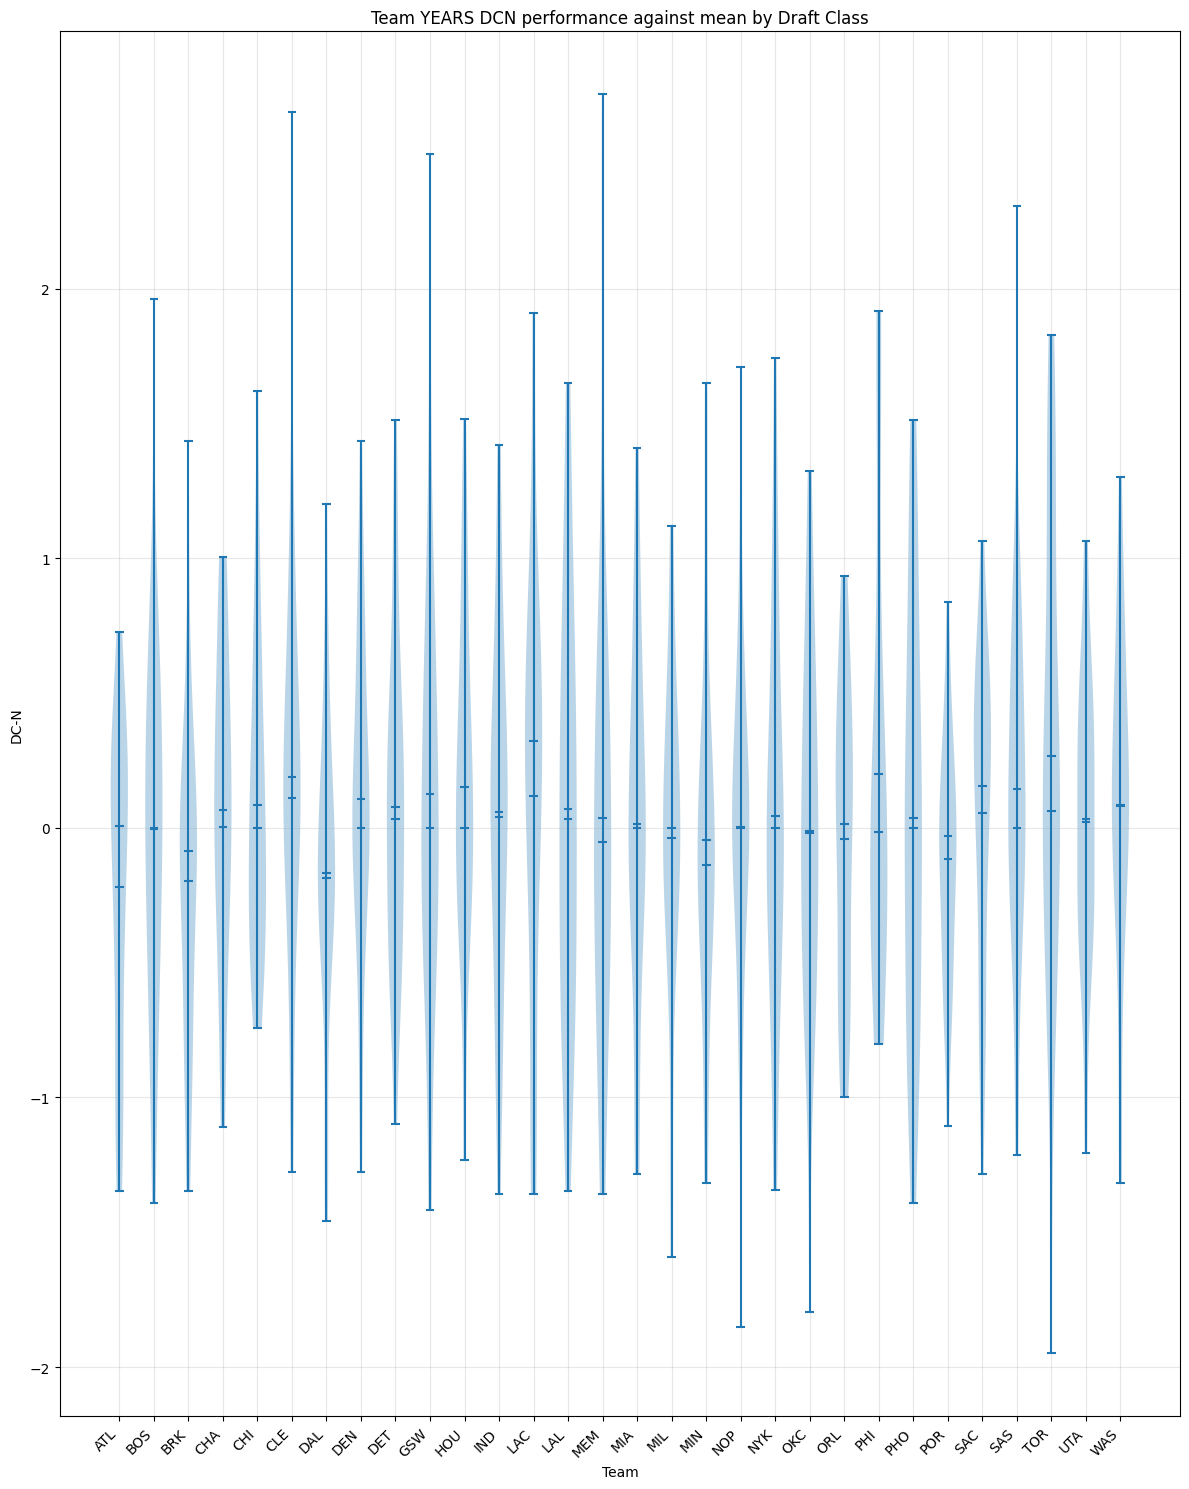

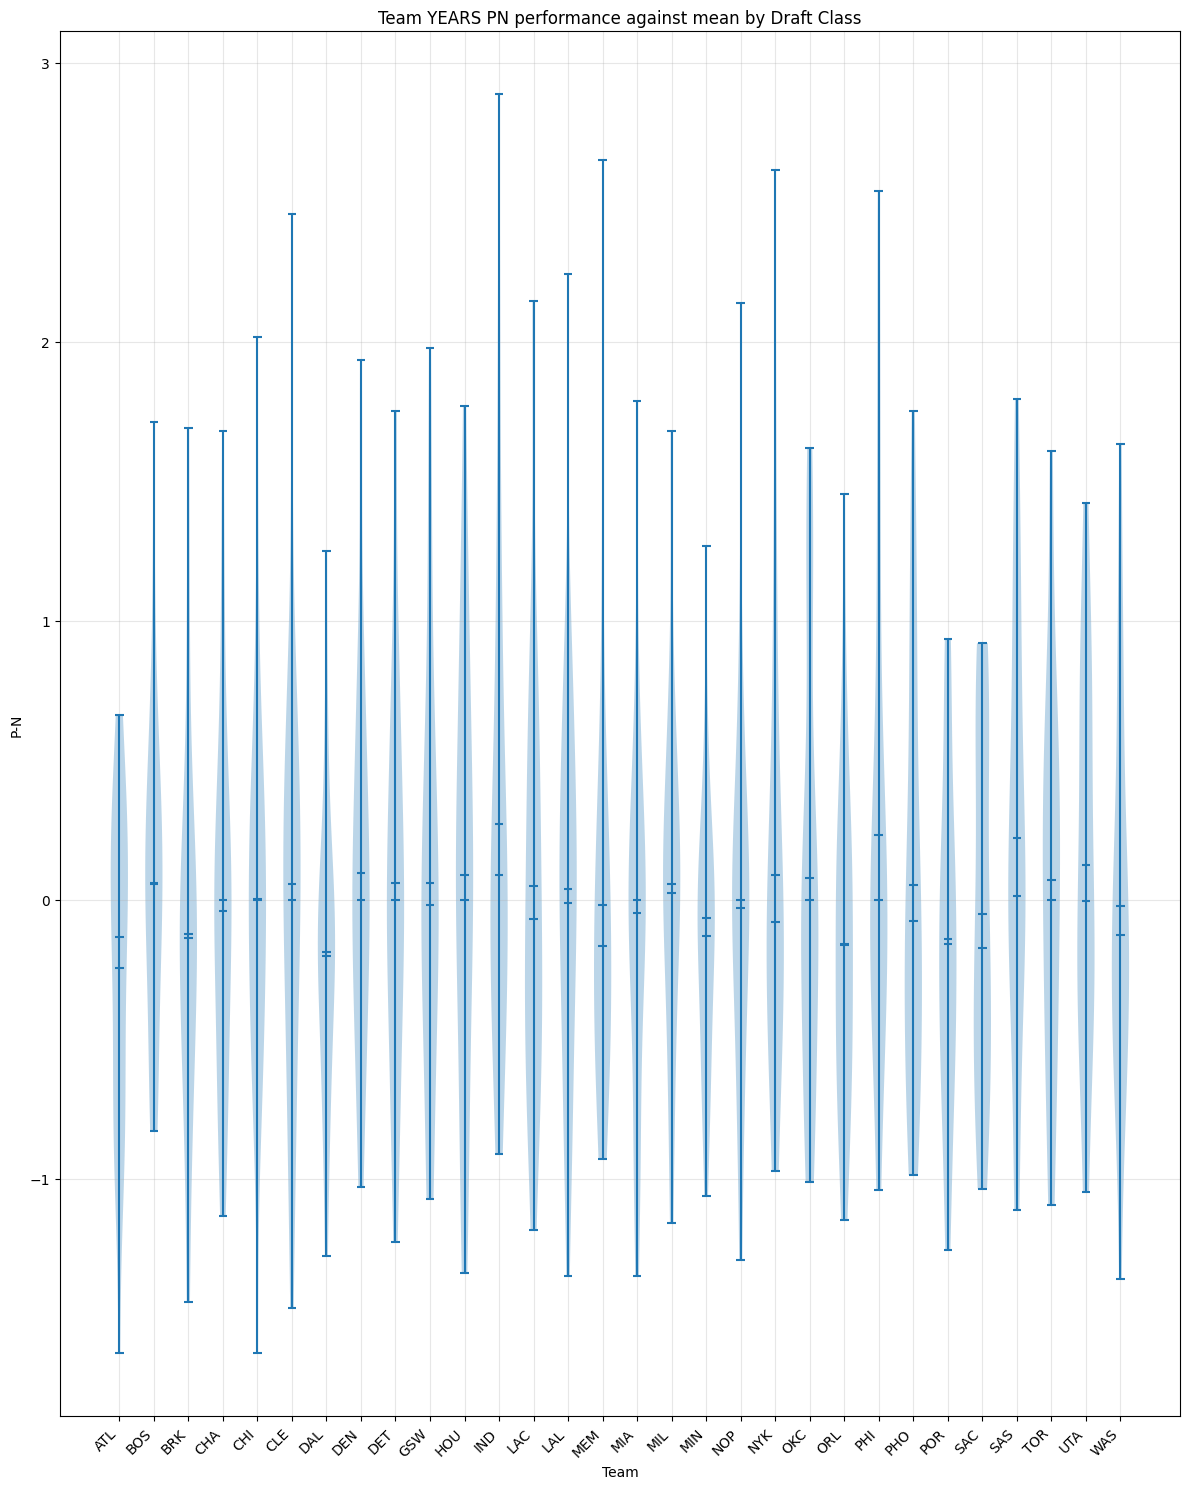

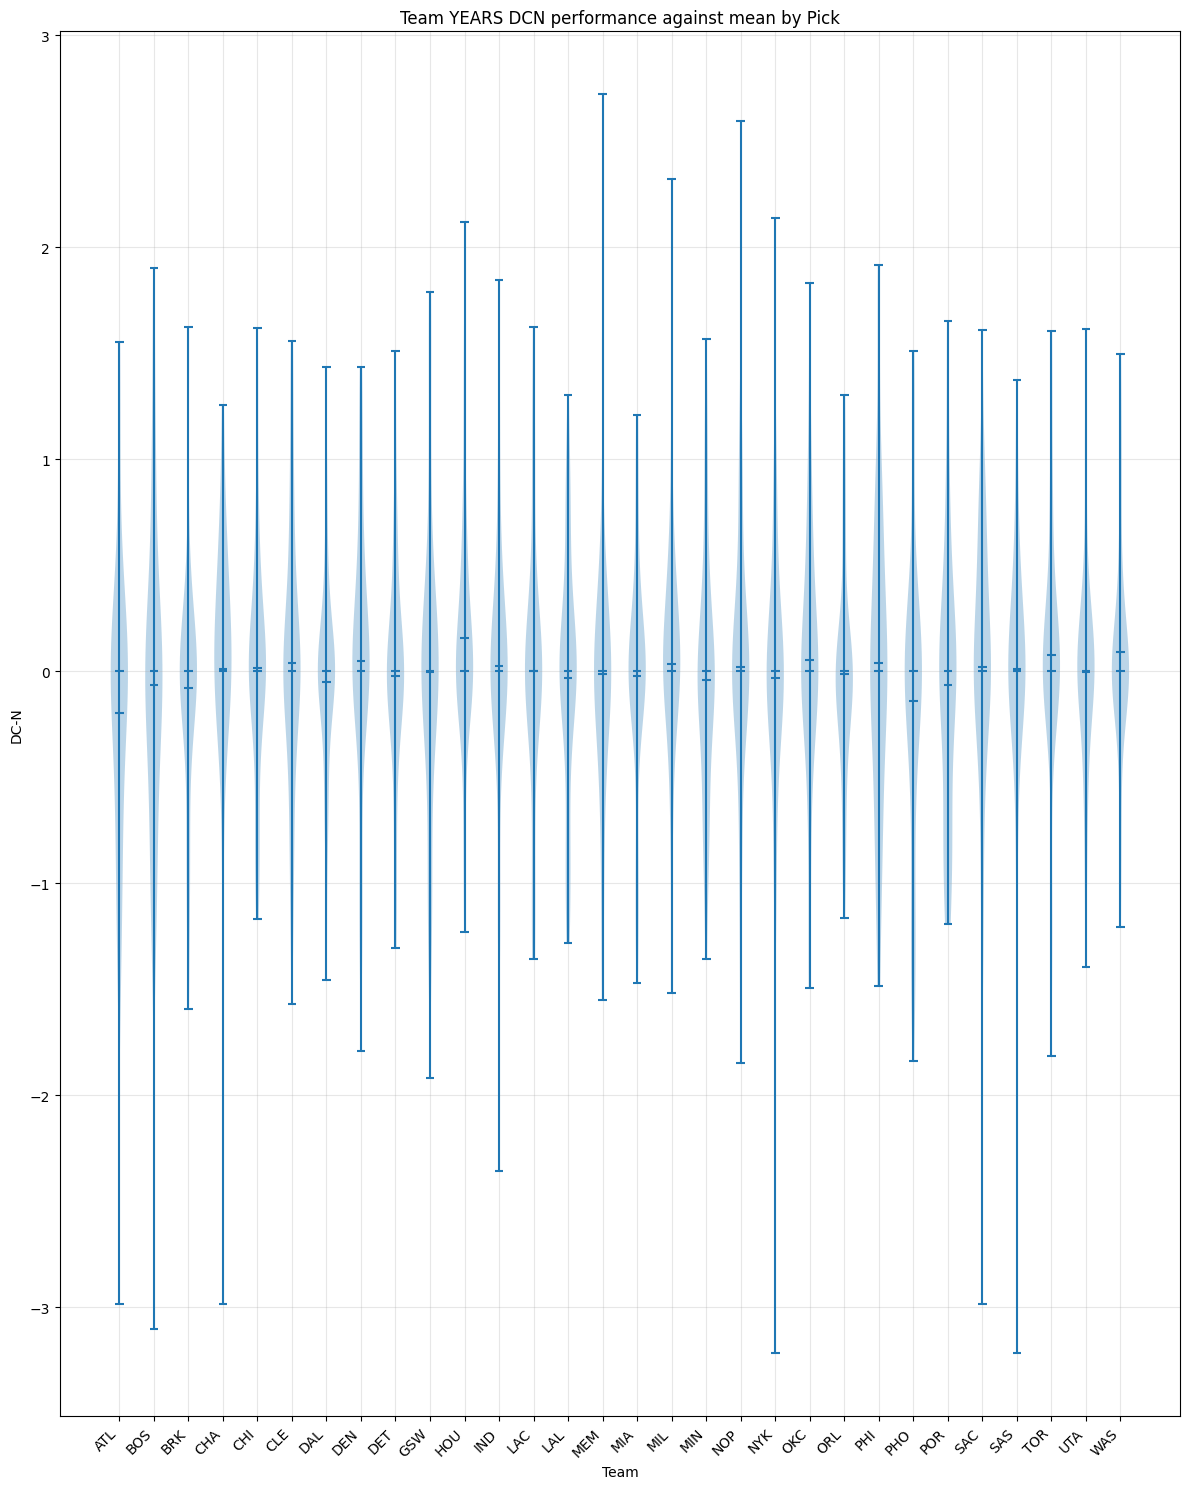

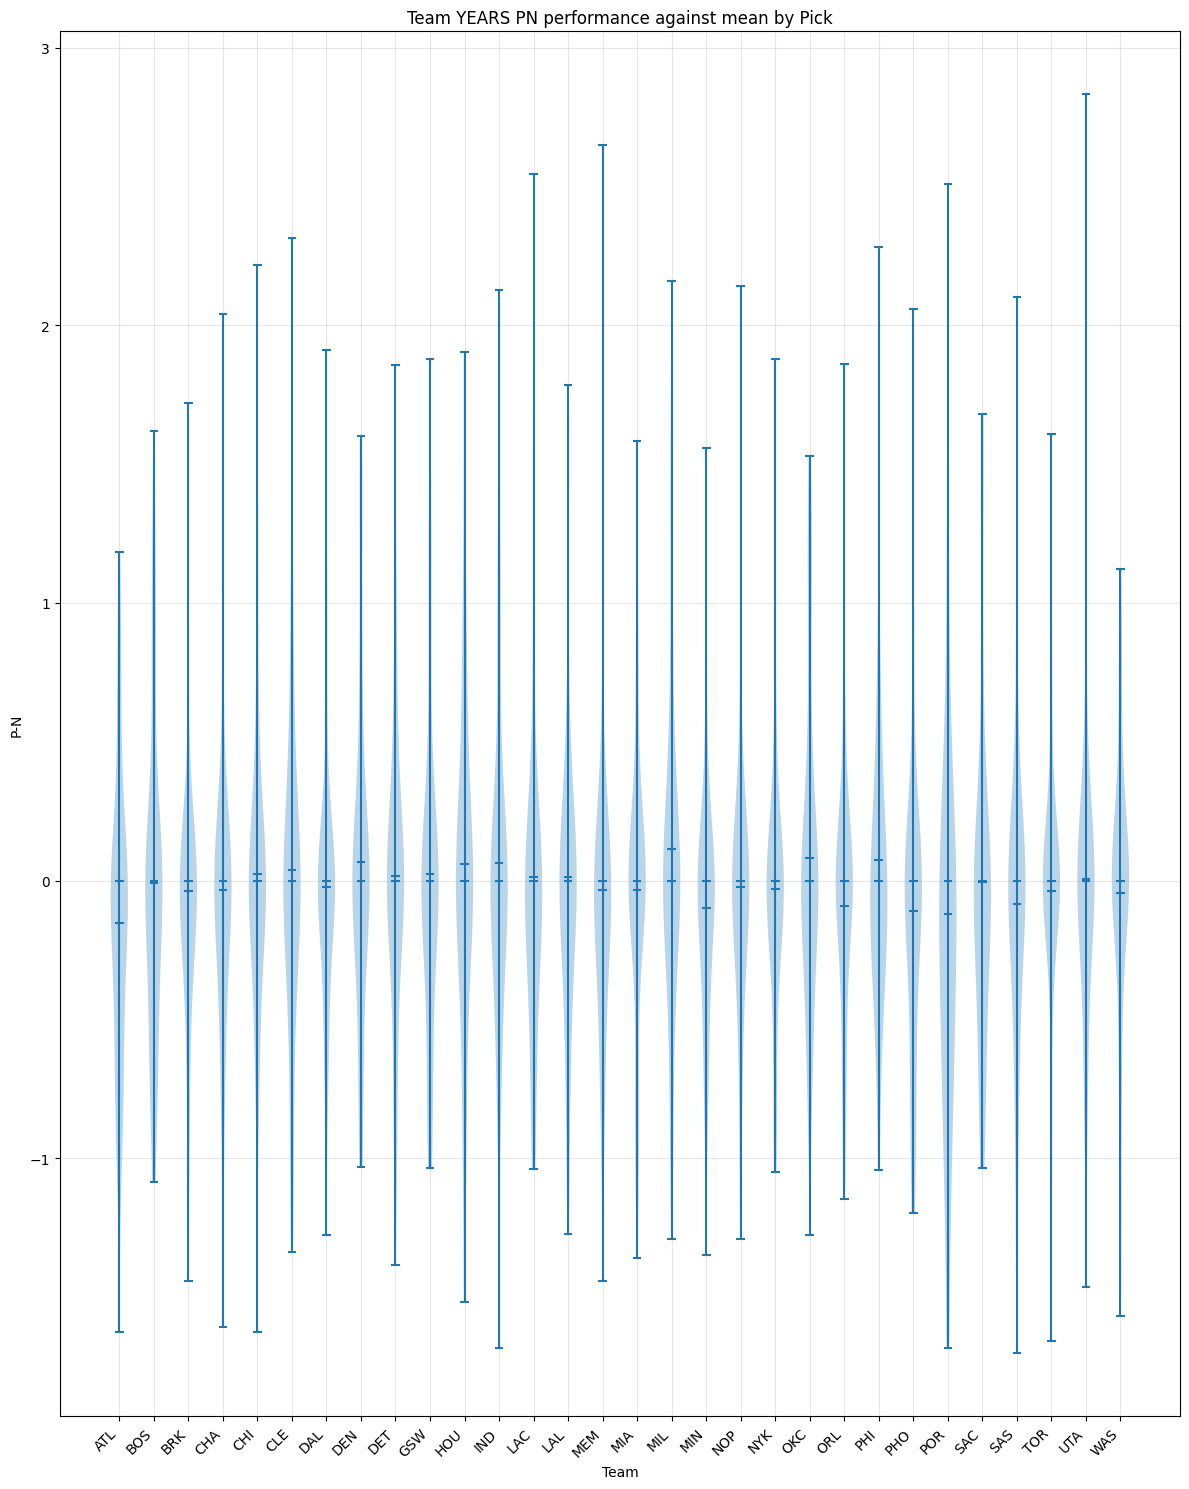

In [34]:
metric = 'YEARS'

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} DCN performance against mean by Draft Class'.format(metric))


new_df = team_aggs['dcn_{}_dc'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('DC-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} PN performance against mean by Draft Class'.format(metric))

new_df = team_aggs['pn_{}_dc'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('P-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} DCN performance against mean by Pick'.format(metric))

new_df = team_aggs['dcn_{}_p'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('DC-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12,15))
ax.set_title('Team {} PN performance against mean by Pick'.format(metric))

new_df = team_aggs['pn_{}_p'.format(metric)].transpose()
ax.violinplot(new_df, showmeans=True, showmedians=True)
ax.set_xlabel('Team')
ax.set_ylabel('P-N')
ax.set_xticks(range(1, len(new_df.columns) + 1))
ax.set_xticklabels(new_df.columns, rotation=45, ha='right')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

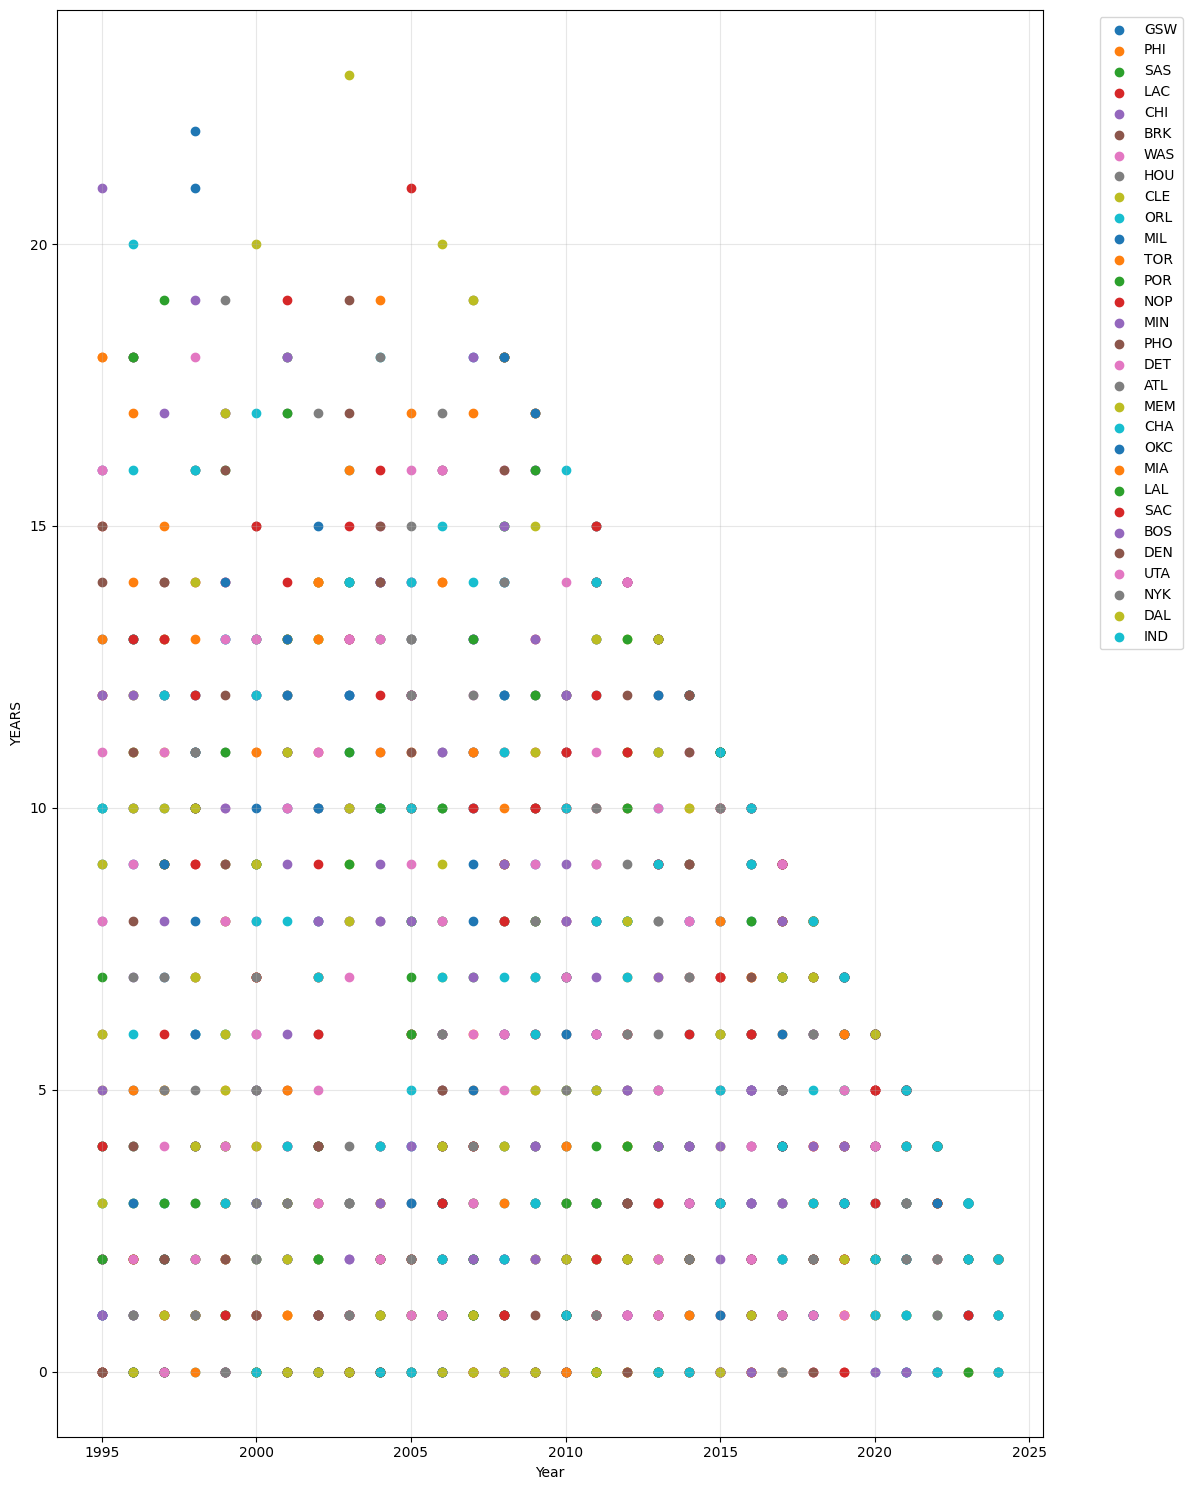

In [10]:
metric = 'YEARS'
plt.figure(figsize=(12,15))
x = df['year']
y = df[metric]
for l in df['TEAM'].unique():
    new_x = x[df.TEAM == l]
    new_y = y[df.TEAM == l]
    plt.scatter(new_x, new_y, label=l)
plt.xlabel('Year')
plt.ylabel(metric)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()
plt.show()